 # I.Lấy dữ liệu

## From alonhadat.ipynb

**code hoàn chỉnh**

Ban đầu nhóm em đã triển khai bằng thư viện requests. Tuy nhiên, trang Alonhadat hiện tại áp dụng cơ chế chống Bot (Anti-crawler) rất gắt bằng Cloudflare và chặn IP tĩnh (vui-long-thu-lai.html). Thư viện requests thuần túy chỉ gửi header mà không thể giải lập được môi trường trình duyệt thật, dẫn đến việc 100% request đều bị web chặn và trả về trang lỗi trống không.

Để cứu tiến độ dự án và đạt mục tiêu >500 dòng dữ liệu thô, nhóm em đã chủ động nâng cấp lên dùng undetected_chromedriver để vượt rào chặn IP, nhưng vẫn giữ nguyên lõi xử lý dữ liệu bằng BeautifulSoup đúng như yêu cầu của đề bài.

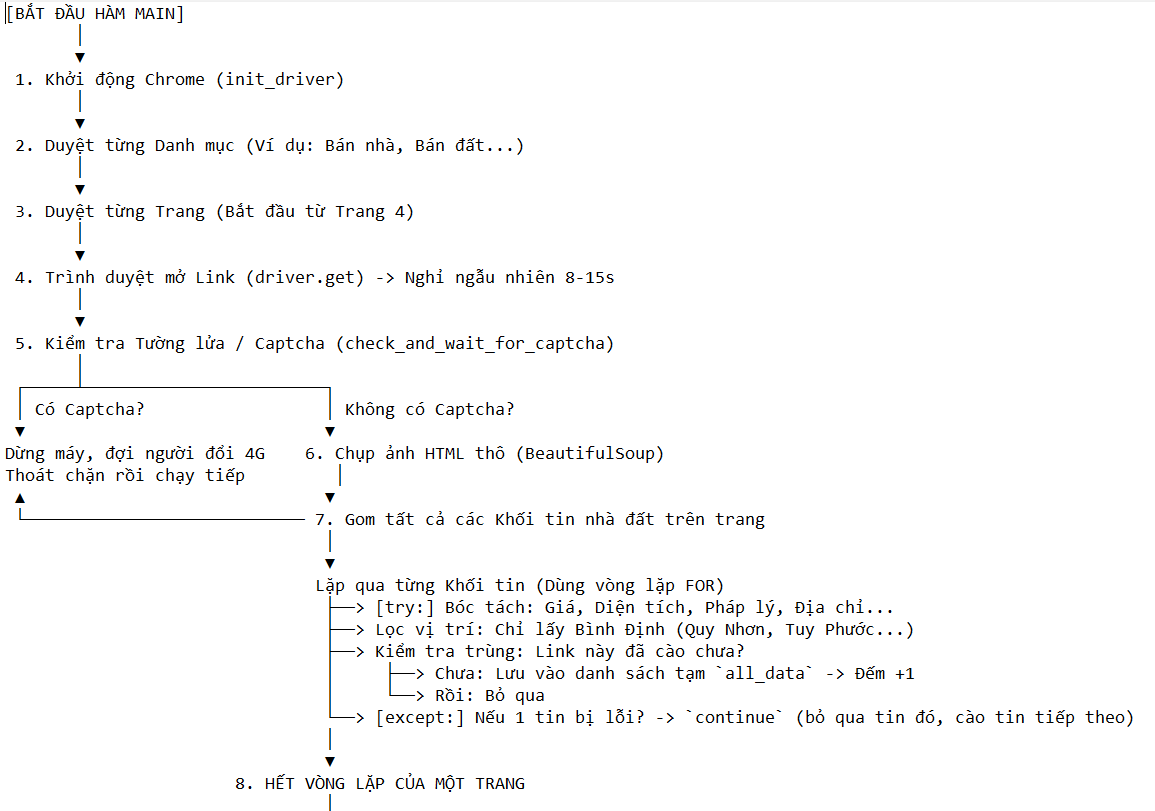
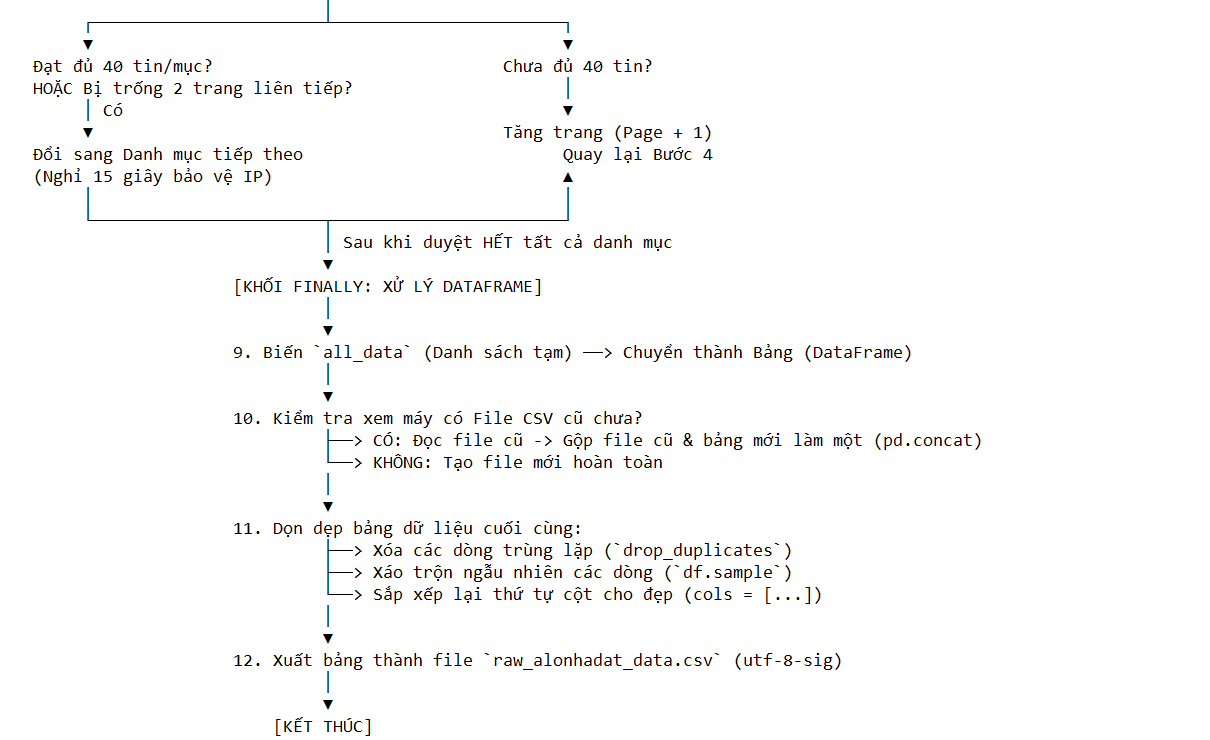

In [ ]:
import time # Điều khiển thời gian (dùng để tạo khoảng dừng khi cào dữ liệu)
import random # Tạo số ngẫu nhiên (dùng để đổi thời gian chờ, tránh bị chặn)
import re # Xử lý chuỗi nâng cao bằng Regular Expression (tìm kiếm, lọc chữ)
import pandas as pd # Xử lý dữ liệu dạng bảng và xuất file Excel/CSV (viết tắt là pd)
import undetected_chromedriver as uc # Điều khiển Chrome ẩn danh (vượt tường lửa, chống bị quét bot)
from bs4 import BeautifulSoup # Trích xuất và phân tích cú pháp dữ liệu từ HTML trang web

CATEGORIES = {
    "Căn hộ chung cư": "https://alonhadat.com.vn/can-ban-can-ho-chung-cu/binh-dinh",
    "Nhà mặt tiền": "https://alonhadat.com.vn/can-ban-nha-mat-tien/binh-dinh",
    "Nhà trong hẻm": "https://alonhadat.com.vn/can-ban-nha-trong-hem/binh-dinh",
    "Biệt thự, nhà liền kề": "https://alonhadat.com.vn/can-ban-biet-thu-nha-lien-ke/binh-dinh",
    "Đất thổ cư/đất ở": "https://alonhadat.com.vn/can-ban-dat-tho-cu-dat-o/binh-dinh",
    "Đất nền/liền kề/đất dự án": "https://alonhadat.com.vn/can-ban-dat-nen-lien-ke-dat-du-an/binh-dinh"
}

TARGET_PER_CATEGORY = 40  # Số lượng tin đăng tối đa muốn lấy cho mỗi danh mục
MAX_EMPTY_PAGES_TO_SKIP = 2  # Số trang trống liên tiếp tối đa trước khi bỏ qua danh mục đó
START_PAGE = 4  # Trang bắt đầu cào dữ liệu



def init_driver():
    options = uc.ChromeOptions()  # Khởi tạo trình cấu hình cho Chrome ẩn danh
    options.add_argument('--start-maximized')  # Cấu hình mở trình duyệt phóng to toàn màn hình
    options.add_argument('--disable-gpu')  # Tắt tăng tốc phần cứng (giúp chạy mượt và nhẹ hơn)
    # Giả lập thông tin trình duyệt thông thường để tránh bị chặn:
    options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36')
    #Tôi là người dùng, đang xài hệ điều hành Windows 10 và dùng trình duyệt Chrome phiên bản 122
    #Khi bạn chạy code cào dữ liệu bằng thư viện tự động (undetected_chromedriver), nếu không khai báo câu lệnh này, trình duyệt tự động sẽ gửi một User-Agent có chứa chữ HeadlessChrome hoặc các dấu hiệu của robot
    driver = uc.Chrome(options=options, version_main=148)  # Khởi chạy Chrome ẩn danh theo phiên bản chỉ định
    return driver  # Trả về đối tượng điều khiển trình duyệt

#Làm gì: Cấu hình và mở trình duyệt Chrome tự động, giả lập người dùng thật để tránh bị chặn.
#Kết quả: Trả về trình duyệt (driver) để điều khiển.

def check_and_wait_for_captcha(driver):
    while True:  # Vòng lặp vô hạn để kiểm tra liên tục cho đến khi hết chặn
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        # Lấy mã nguồn HTML hiện tại của trang,phân tích cú pháp
        #BeautifulSoup. Thư viện này sẽ biến đống code rối rắm thành một cấu trúc hình cây (gồm các thẻ cha, thẻ con, các thuộc tính class, id).
        page_title = driver.title.lower()  # Lấy tiêu đề trang (chuyển về chữ thường)
        page_text = soup.text.lower()  # Lấy toàn bộ văn bản của trang (chuyển về chữ thường)

        # Kiểm tra xem có chứa các từ khóa dấu hiệu bị chặn/Captcha hay không:
        is_blocked = (
            "vui lòng thử lại sau" in page_text or
            "truy cập quá nhiều" in page_text or
            "cloudflare" in page_title or
            "just a moment" in page_title
        )

        if is_blocked:  # Nếu phát hiện bị chặn
            print("\n" + "!"*60)
            print("🚨 CẢNH BÁO: HỆ THỐNG ĐANG KHÓA IP HOẶC YÊU CẦU XÁC THỰC!")
            print("👉 BẬT 4G/5G ĐIỆN THOẠI -> PHÁT WIFI CHO MÁY TÍNH ĐỂ ĐỔI IP MỚI.")
            print("👉 Kiểm tra trình duyệt xem danh sách nhà đất đã tải lại bình thường chưa.")
            print("!"*60 + "\n")
            input("Nhấn phím [ENTER] tại đây để TIẾP TỤC chạy lại sau khi đã đổi mạng...")  # Dừng code chờ người dùng đổi mạng
            driver.refresh()  # Tải lại trang web sau khi người dùng bấm Enter
            time.sleep(5)  # Chờ 5 giây cho trang tải xong
        else:
            break  # Nếu không bị chặn thì thoát vòng lặp để chạy tiếp

#Làm gì: Kiểm tra xem trang web có bị dính Captcha/Tường lửa (Cloudflare) không. Nếu bị, dừng code bắt người dùng đổi mạng (bật 4G) rồi mới chạy tiếp.
#Kết quả: Không trả về dữ liệu (chỉ điều hướng/tải lại trang).

def clean_field(text, pattern):
    if not text: return None  # Nếu không có chữ thì trả về trống
    cleaned = re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
     # Xóa phần chữ thừa theo mẫu tìm kiếm và xóa khoảng trắng

    return cleaned if cleaned else None  # Trả về kết quả sau khi làm sạch (hoặc None nếu rỗng)

#Làm gì: Tìm và xóa bỏ các chữ thừa, ký tự rác trong đoạn văn bản theo mẫu có sẵn trong phần kích thước và hướng dưới main.
#flags=re.IGNORECASE (Không phân biệt hoa thường)
#.strip() (Gọt 2 đầu): * Sau khi cắt bỏ chữ rác, thường đoạn chữ còn lại sẽ bị dư ra các khoảng trắng vô duyên ở đầu hoặc cuối (ví dụ: "  3 tỷ  ").
#Ví dụ: Văn bản gốc là "Giá : 3 tỷ", khuôn mẫu là "Giá : ". Sau khi chạy, chữ "Giá : " biến mất, chỉ còn lại "3 tỷ".
#Kết quả: Trả về đoạn chữ sạch đã lọc bỏ phần thừa (hoặc None).

def extract_legal(text):
    text_lower = text.lower()  # Chuyển chữ về dạng viết thường để dễ so sánh
    # Phân loại giấy tờ pháp lý dựa theo từ khóa xuất hiện trong văn bản:
    if "sổ đỏ" in text_lower or "so do" in text_lower:
        return "Sổ đỏ"
    elif "sổ hồng" in text_lower or "so hong" in text_lower or "sổ riêng" in text_lower:
        return "Sổ hồng"
    elif "hđmb" in text_lower or "hợp đồng mua bán" in text_lower:
        return "HĐMB"
    elif "giấy tờ tay" in text_lower or "vi bằng" in text_lower:
        return "Giấy tay / Vi bằng"
    return None  # Trả về None nếu không tìm thấy từ khóa nào phù hợp

#Làm gì: Quét các từ khóa trong tin đăng để phân loại giấy tờ pháp lý.
#Kết quả: Trả về chữ chuẩn hóa: "Sổ đỏ", "Sổ hồng", "HĐMB", "Giấy tay / Vi bằng" (hoặc None).

def main():
    driver = init_driver()  # Khởi động trình duyệt tự động
    all_data = []  # Tạo danh sách rỗng để lưu trữ toàn bộ dữ liệu cào được

    try: #Hãy chạy thử những dòng lệnh này đi. Nếu mọi chuyện mượt mà thì quá tốt, nhưng nếu lỡ xảy ra lỗi giữa chừng thì cấm được sập nguồn, hãy chuyển qua xử lý phương án dự phòng(exception)
        # E ví dụ : continue  # Bỏ qua tin lỗi này, chuyển sang tin tiếp theo luôn!
        for category_name, base_url in CATEGORIES.items():  # Duyệt qua từng danh mục nhà đất trong danh sách CATEGORIES
            print(f"\n🚀 BẮT ĐẦU THU THẬP DANH MỤC: [{category_name}]")
            category_count = 0  # Đếm số tin đã lưu thành công cho danh mục hiện tại
            page = START_PAGE  # Đặt trang bắt đầu cào dữ liệu (trang 4)
            consecutive_empty_pages = 0  # Đếm số trang trống liên tiếp không có dữ liệu

            while category_count < TARGET_PER_CATEGORY:  # Vòng lặp chạy cho đến khi đủ số lượng tin yêu cầu
                url = f"{base_url}/trang-{page}" if page > 1 else base_url  # Tạo đường link trang cần cào
                print(f" -> Đang quét trang {page}: {url}")

                try:
                    driver.get(url)  # Điều khiển trình duyệt truy cập vào link
                    time.sleep(random.uniform(8.0, 15.0))  # Nghỉ ngẫu nhiên từ 8 đến 15 giây để giả lập người thật

                    check_and_wait_for_captcha(driver)  # Kiểm tra xem có gặp tường lửa/Captcha không

                    soup = BeautifulSoup(driver.page_source, 'html.parser')  # Lấy HTML của trang vừa tải

                    property_items = []  # Tạo danh sách chứa các khối tin nhà đất trên trang này
                    for a_tag in soup.find_all('a', href=True):  # Tìm tất cả các thẻ liên kết <a> trên trang

                        # Lọc các thẻ có chứa đuôi '.html' và độ dài chữ lớn hơn 15 ký tự (tiêu đề tin):
                        if '.html' in a_tag['href'] and len(a_tag.text.strip()) > 15:

                            # Tìm thẻ cha chứa tin (dựa vào từ khóa class liên quan đến bất động sản):
                            p_box = a_tag.find_parent(class_=lambda c: c and ('properties' in c or 'property' in c or 'vip' in c or 'content' in c))
                            if not p_box:  # Nếu không tìm thấy bằng class, thử tìm thẻ div cha cấp 2:
                                parent_div = a_tag.find_parent('div')
                                if parent_div: p_box = parent_div.find_parent('div')

                            # Nếu tìm thấy khối tin, chưa bị trùng và độ dài văn bản hợp lý (< 1500 chữ):
                            if p_box and p_box not in property_items and len(p_box.text.strip()) < 1500:
                                property_items.append(p_box)  # Thêm khối tin này vào danh sách để xử lý

                    if not property_items:  # Nếu trang hoàn toàn không có khối tin nào
                        print(f"ℹ️ Không phát hiện khối tin đăng nào trên trang {page}. Đổi mục sớm!")
                        break  # Thoát vòng lặp trang, chuyển sang danh mục tiếp theo

                    new_items_in_page = 0  # Đếm số tin mới lưu được ở trang hiện tại
                    for box in property_items:  # Duyệt qua từng khối tin tìm được trên trang
                        try:
                            full_box_text = box.text.replace('\n', ' ').strip()  # Lấy toàn bộ chữ trong khối tin, xóa xuống dòng

                            # Dùng regex quét xem tin này có thuộc khu vực Bình Định (các huyện chỉ định lân cận) không:
                            loc_match = re.search(r'((Thành\s*phố\s*Quy\s*Nhơn|Huyện\s*Tuy\s*Phước|Thị\s*xã\s*An\s*Nhơn|Huyện\s*Phù\s*Cát)[^,]*),\s*Bình\s*Định', full_box_text, re.IGNORECASE)
                            if not loc_match:
                                continue  # Nếu không thuộc khu vực cần tìm thì bỏ qua tin này

                            raw_location = loc_match.group(1).strip()  # Lấy chuỗi vị trí thô
                            # Lấy toàn bộ chuỗi vị trí thô tìm được (Ví dụ: "Phường Ngô Mây, Thành phố Quy Nhơn")
                            quan_huyen_clean = loc_match.group(2).strip()  # Lấy chính xác tên Quận/Huyện
                            # Chỉ lấy chính xác tên của Quận hoặc Huyện (Ví dụ: "Thành phố Quy Nhơn")


                            # --- TỐI ƯU TRÍCH XUẤT TÊN ĐƯỜNG ---
                            address_detail = None  # Khởi tạo địa chỉ chi tiết là rỗng

                            # Cách 1: Tìm chữ "Đường ..." trực tiếp trong văn bản khối tin
                            # Quét trong toàn bộ tin xem có cụm từ "Đường [vừa chữ vừa số] kéo dài đến dấu phẩy" không
                            street_direct = re.search(r'(Đường\s+[^,]+)', full_box_text, re.IGNORECASE)
                            if street_direct:# Nếu tìm thấy chữ "Đường..." bằng Cách 1
                                # Cắt lấy chính xác cụm từ đó (Ví dụ: "Đường Nguyễn Huệ") nạp vào biến địa chỉ
                                address_detail = street_direct.group(1).strip()  # Lưu lại tên đường tìm được
                            else:
                                # Cách 2: Tách lấy phần chữ phía trước Quận/Huyện để mò tìm Phường/Xã/Thôn/Khu dân cư...
                                # Chặt đôi văn bản tin đăng tại vị trí của chuỗi `raw_location` để lấy phần chữ đứng TRƯỚC nó
                                addr_parts = full_box_text.split(raw_location)
                                if len(addr_parts) > 0:# Nếu chặt đôi văn bản thành công
                                    # Lấy phần nửa đầu của văn bản vừa chặt, xóa khoảng trắng thừa
                                    sub_text = addr_parts[0].strip()
                                    ## Dùng Regex dò ngược từ cuối đoạn sub_text lên để tìm các từ khóa Phường/Xã/Thôn/KDC...
                                    street_match = re.search(r'((?:Đường|Phường|Xã|Thôn|KDC|KĐT)[^,]+(?:,\s*[^,]+)*)$', sub_text, re.IGNORECASE)
                                    if street_match:# Nếu mò thấy
                                        address_detail = street_match.group(1).strip()  # Lưu lại thông tin vừa mò được vào biến địa chỉ
                            # --------------------------------------------------

                            link_el = box.find('a', href=True)  # Tìm thẻ liên kết chứa link chi tiết
                            title = link_el.text.strip()  # Lấy tiêu đề tin đăng
                            url_detail = "https://alonhadat.com.vn" + link_el['href']  # Ghép thành link đầy đủ của tin

                            if "đăng tin" in title.lower() or len(title) < 10:
                                continue  # Loại bỏ nếu là nút bấm quảng cáo hoặc tiêu đề quá ngắn vô nghĩa

                            # Dùng Regex tìm giá tiền và diện tích của nhà đất:
                            price_match = re.search(r'Giá\s*:\s*([\d,\.]+\s*(?:tỷ|tỉ|triệu|thỏa\s*thuận))', full_box_text, re.IGNORECASE)
                            area_match = re.search(r'Diện\s*tích\s*:\s*([\d,\.]+\s*m²)', full_box_text, re.IGNORECASE)

                            # Tìm kích thước (KT) và làm sạch chữ thừa:
                            kt_match = re.search(r'KT\s*:\s*([^\s]+)', full_box_text, re.IGNORECASE)
                            kt_clean = clean_field(kt_match.group(1), r'KT\s*:\s*') if kt_match else None
                            if kt_clean:
                                kt_clean = re.sub(r'(?:hướng|đường).*$', '', kt_clean, flags=re.IGNORECASE).strip()

                            # Tìm hướng nhà đất và làm sạch chữ thừa:
                            direction_match = re.search(r'Hướng\s*:\s*([^\s,;]+)', full_box_text, re.IGNORECASE)
                            direction_clean = clean_field(direction_match.group(1), r'Hướng\s*:\s*') if direction_match else None
                            if direction_clean:
                                direction_clean = re.sub(r'(?:đường|bếp).*$', '', direction_clean, flags=re.IGNORECASE).strip()

                            # Tìm số tầng:
                            floor_match = re.search(r'(\d+)\s*tầng', full_box_text, re.IGNORECASE)
                            floors = floor_match.group(1).strip() + " tầng" if floor_match else None

                            # Tìm số phòng ngủ:
                            room_match = re.search(r'(\d+)\s*phòng\s*ngủ', full_box_text, re.IGNORECASE)
                            rooms = room_match.group(1).strip() + " PN" if room_match else None

                            # Tìm số nhà vệ sinh (WC):
                            wc_match = re.search(r'(\d+)\s*(?:wc|phòng vệ sinh|nhà vệ sinh|toile|nha ve sinh)', full_box_text, re.IGNORECASE)
                            wc_count = wc_match.group(1).strip() + " WC" if wc_match else None

                            # Phân loại pháp lý (sổ đỏ/sổ hồng...) từ hàm đã viết:
                            legal_clean = extract_legal(full_box_text)

                            # Gom toàn bộ thông tin đã bóc tách được thành 1 bộ dữ liệu (Dictionary):
                            item_info = {
                                "loai_bds": category_name,
                                "tieu_de": title,
                                "gia": price_match.group(1).strip() if price_match else None,
                                "dien_tich": area_match.group(1).strip() if area_match else None,
                                "kich_thuoc": kt_clean,
                                "huong": direction_clean,
                                "so_tang": floors,
                                "so_phong_ngu": rooms,
                                "so_wc": wc_count,
                                "phap_ly": legal_clean,
                                "quan_huyen": quan_huyen_clean,
                                "dia_chi": address_detail,
                                "nguon": url_detail
                            }

                            # Kiểm tra xem link tin này đã tồn tại trong danh sách tổng chưa (tránh trùng lặp):
                            if url_detail not in [d['nguon'] for d in all_data]:
                                all_data.append(item_info)  # Thêm vào danh sách dữ liệu tổng
                                category_count += 1  # Tăng số lượng đếm của danh mục lên 1
                                new_items_in_page += 1  # Tăng số lượng đếm của trang hiện tại lên 1

                            if category_count >= TARGET_PER_CATEGORY:
                                break  # Nếu đã cào đủ số lượng mục tiêu cho danh mục thì dừng lại
                        except Exception:
                            continue  # Nếu lỗi khi xử lý một tin cụ thể thì bỏ qua, chạy tiếp tin sau

                    print(f" ✅ Trang {page}: Lọc thành công {new_items_in_page} tin sạch. (Mục này đạt: {category_count}/{TARGET_PER_CATEGORY})")

                    if new_items_in_page == 0:
                        consecutive_empty_pages += 1  # Nếu trang này không lấy thêm được tin mới nào thì tăng biến đếm trang trống
                    else:
                        consecutive_empty_pages = 0  # Nếu có tin mới thì reset biến đếm trang trống về 0

                    if consecutive_empty_pages >= MAX_EMPTY_PAGES_TO_SKIP:
                        print(f"ℹ️ Đã qua {MAX_EMPTY_PAGES_TO_SKIP} trang không có thêm tin mới. Tự động chuyển mục khác!")
                        break  # Dừng cào danh mục hiện tại nếu gặp quá số trang trống quy định

                    page += 1  # Tăng số trang lên để tiếp tục cào trang tiếp theo

                except Exception as page_err:
                    print(f"❌ Sự cố tại trang {page}: {page_err}")
                    break  # Lỗi trang thì bỏ qua danh mục này

            print(f"☕ Hoàn thành mục [{category_name}]. Nghỉ giãn cách 15 giây bảo vệ IP...")
            time.sleep(15)  # Nghỉ 15 giây giữa các danh mục lớn để tránh bị máy chủ chặn IP

    finally:
        print("\n🛑 Hoàn tất tiến trình quét. Đang xuất tập dữ liệu CSV hoàn chỉnh...")
        driver.quit()  # Đóng trình duyệt tự động sau khi kết thúc việc cào dữ liệu

    if all_data:  # Nếu danh sách tổng thu thập được có dữ liệu
        df = pd.DataFrame(all_data)  # Chuyển đổi danh sách dữ liệu thành dạng bảng (DataFrame) của Pandas
        file_name = "raw_alonhadat_data.csv"  # Đặt tên file lưu trữ dữ liệu dạng CSV
        try:
            df_old = pd.read_csv(file_name)  # Thử đọc file CSV cũ nếu nó đã tồn tại trên máy

            if 'so_phong' in df_old.columns:
                df_old.rename(columns={'so_phong': 'so_phong_ngu'}, inplace=True)  # Đổi tên cột cũ cho khớp cấu trúc mới

            if 'so_nha' in df_old.columns:
                df_old.drop(columns=['so_nha'], inplace=True, errors='ignore')  # Xóa cột 'so_nha' ở file cũ nếu có để tránh lệch cấu trúc

            df = pd.concat([df_old, df], ignore_index=True)  # Gộp dữ liệu file cũ và dữ liệu mới cào lại thành một
            print("🔄 Phát hiện file raw_alonhadat_data.csv cũ, đang tiến hành gộp dữ liệu đợt mới vào...")
        except FileNotFoundError:
            print("🆕 Khởi tạo file dữ liệu mới...")  # Nếu chưa có file cũ thì xuất thông báo tạo mới hoàn toàn

        df.drop_duplicates(subset=['nguon'], inplace=True)  # Loại bỏ hoàn toàn các dòng dữ liệu trùng link nguồn
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Xáo trộn ngẫu nhiên thứ tự các dòng dữ liệu và reset lại số chỉ mục chỉ số dòng

        # Định nghĩa danh sách thứ tự các cột sẽ hiển thị trong file CSV xuất ra:
        cols = ["loai_bds", "tieu_de", "gia", "dien_tich", "kich_thuoc", "huong", "so_tang", "so_phong_ngu", "so_wc", "phap_ly", "quan_huyen", "dia_chi", "nguon"]
        df = df[cols]  # Áp dụng cấu trúc cột đã chọn vào bảng dữ liệu

        df.to_csv(file_name, index=False, encoding='utf-8-sig')  # Lưu bảng dữ liệu thành file CSV (sử dụng định dạng utf-8-sig chống lỗi font tiếng Việt khi mở bằng Excel)

        print(f"\n🏆 XUẤT FILE RAW_ALONHADAT_DATA.CSV THÀNH CÔNG!")
        print(f"📊 Tổng số lượng dữ liệu thu được: {len(df)} dòng bản ghi sạch.")
        print(df['loai_bds'].value_counts())  # In ra thống kê số lượng bản ghi cụ thể cho từng loại bất động sản
    else:
        print("\n❌ Thất bại: Không thu được dữ liệu nào vượt qua bộ lọc.")  # Báo lỗi nếu danh sách dữ liệu trống rỗng

if __name__ == "__main__":
    main()  # Điểm kích hoạt chương trình chạy khi bạn bấm thực thi file code này

#Làm gì: Bộ não điều khiển toàn bộ quy trình: Mở duyệt web --> Lặp qua các trang --> Cào và bóc tách dữ liệu tin đăng --> Lọc trùng --> Gộp dữ liệu cũ.
#Kết quả: Xuất ra file dữ liệu sạch raw_alonhadat_data.csv lưu trên máy tính.


🚀 BẮT ĐẦU THU THẬP DANH MỤC: [Căn hộ chung cư]
 -> Đang quét trang 4: https://alonhadat.com.vn/can-ban-can-ho-chung-cu/binh-dinh/trang-4
 ✅ Trang 4: Lọc thành công 20 tin sạch. (Mục này đạt: 20/40)
 -> Đang quét trang 5: https://alonhadat.com.vn/can-ban-can-ho-chung-cu/binh-dinh/trang-5
 ✅ Trang 5: Lọc thành công 20 tin sạch. (Mục này đạt: 40/40)
☕ Hoàn thành mục [Căn hộ chung cư]. Nghỉ giãn cách 15 giây bảo vệ IP...

🚀 BẮT ĐẦU THU THẬP DANH MỤC: [Nhà mặt tiền]
 -> Đang quét trang 4: https://alonhadat.com.vn/can-ban-nha-mat-tien/binh-dinh/trang-4
 ✅ Trang 4: Lọc thành công 20 tin sạch. (Mục này đạt: 20/40)
 -> Đang quét trang 5: https://alonhadat.com.vn/can-ban-nha-mat-tien/binh-dinh/trang-5
 ✅ Trang 5: Lọc thành công 20 tin sạch. (Mục này đạt: 40/40)
☕ Hoàn thành mục [Nhà mặt tiền]. Nghỉ giãn cách 15 giây bảo vệ IP...

🚀 BẮT ĐẦU THU THẬP DANH MỤC: [Nhà trong hẻm]
 -> Đang quét trang 4: https://alonhadat.com.vn/can-ban-nha-trong-hem/binh-dinh/trang-4
 ✅ Trang 4: Lọc thành công 20 tin 

## From batdongsan.ipynb

In [ ]:
import time
import random
import re
import pandas as pd
from bs4 import BeautifulSoup
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

CATEGORIES = {
    "Cần hộ chung cư": "https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh",
    "Nhà riêng": "https://batdongsan.com.vn/ban-nha-rieng-binh-dinh",
    "Nhà biệt thự/liền kề": "https://batdongsan.com.vn/ban-nha-biet-thu-lien-ke-binh-dinh",
    "Nhà mặt phố": "https://batdongsan.com.vn/ban-nha-mat-pho-binh-dinh",
    "Shophouse": "https://batdongsan.com.vn/ban-shophouse-nha-pho-thuong-mai-binh-dinh",
    "Đất nền dự án": "https://batdongsan.com.vn/ban-dat-nen-du-an-binh-dinh",
    "Bán đất": "https://batdongsan.com.vn/ban-dat-binh-dinh"
}

TARGET_PER_CATEGORY = 150
MAX_EMPTY_PAGES_TO_SKIP = 2
START_PAGE = 1

def init_driver():
    options = uc.ChromeOptions()
    options.add_argument('--start-maximized')
    options.add_argument('--disable-gpu')
    options.add_argument('--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36')
    driver = uc.Chrome(options=options, version_main=148)
    return driver

def check_and_bypass_captcha(driver):
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    page_title = driver.title.lower()
    page_text = soup.text.lower()

    is_blocked = (
        "cloudflare" in page_title or
        "just a moment" in page_title or
        "ddos" in page_text
    )

    if is_blocked:
        print("\n🔒 Phát hiện màn hình chặn Captcha/Cloudflare! Đang thử xử lý tự động...")
        try:
            WebDriverWait(driver, 10).until(
                EC.frame_to_be_available_and_switch_to_it((By.CSS_SELECTOR, "iframe[src*='cloudflare']"))
            )
            checkbox = WebDriverWait(driver, 5).until(
                EC.element_to_be_clickable((By.CSS_SELECTOR, "input[type='checkbox'], .cb-i, #challenge-stage"))
            )
            checkbox.click()
            print("✅ Đã tự động kích hoạt click ô Xác thực thành công.")
            driver.switch_to.default_content()
            time.sleep(5)
        except Exception:
            driver.switch_to.default_content()
            print("\n" + "!"*60)
            print("🚨 KHÔNG THỂ TỰ ĐỘNG VƯỢT CAPTCHA!")
            print("👉 Vui lòng nhìn vào trình duyệt, tự tay TICK VÀO Ô CAPTCHA.")
            print("👉 Nếu bị chặn IP nặng: Hãy bật 4G phát Wifi lại cho máy tính.")
            print("!"*60 + "\n")
            input("Nhấn phím [ENTER] sau khi trình duyệt đã tải lại nội dung nhà đất bình thường...")
            driver.refresh()
            time.sleep(5)

def clean_field(text, pattern):
    if not text: return None
    cleaned = re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return cleaned if cleaned else None

def extract_legal(text):
    text_lower = text.lower()
    if "sổ đỏ" in text_lower or "sổ quyền sử dụng" in text_lower:
        return "Sổ đỏ"
    elif "sổ hồng" in text_lower or "sổ riêng" in text_lower:
        return "Sổ hồng"
    elif "hđmb" in text_lower or "hợp đồng mua bán" in text_lower:
        return "HĐMB"
    elif "giấy tay" in text_lower or "vi bằng" in text_lower:
        return "Giấy tay / Vi bằng"
    return None

def main():
    driver = init_driver()
    all_data = []

    try:
        for category_name, base_url in CATEGORIES.items():
            print(f"\n🚀 BẮT ĐẦU THU THẬP DANH MỤC: [{category_name}]")
            category_count = 0
            page = START_PAGE
            consecutive_empty_pages = 0

            while category_count < TARGET_PER_CATEGORY:
                url = f"{base_url}/p{page}" if page > 1 else base_url
                print(f" -> Đang quét trang {page}: {url}")

                try:
                    driver.get(url)
                    time.sleep(random.uniform(7.0, 12.0))

                    check_and_bypass_captcha(driver)

                    soup = BeautifulSoup(driver.page_source, 'html.parser')

                    property_items = soup.find_all('div', class_=lambda c: c and ('re__card-info' in c or 're__item-box' in c or 'js__card' in c))

                    if not property_items:
                        property_items = soup.find_all('a', class_=lambda c: c and 're__card-image' in c)
                        property_items = [p.find_parent('div') for p in property_items if p.find_parent('div')]

                    if not property_items:
                        print(f"ℹ️ Không phát hiện khối tin đăng nào trên trang {page}. Đổi mục sớm!")
                        consecutive_empty_pages += 1
                        if consecutive_empty_pages >= MAX_EMPTY_PAGES_TO_SKIP:
                            break
                        page += 1
                        continue

                    new_items_in_page = 0
                    for box in property_items:
                        try:
                            full_box_text = box.text.replace('\n', ' ').strip()

                            link_el = box.find('a', href=True) or box.find_parent('a', href=True)
                            if not link_el:
                                continue

                            title = link_el.get('title') or link_el.text.strip()
                            if not title or len(title) < 15 or "đăng tin" in title.lower():
                                continue

                            href = link_el['href']
                            url_detail = href if href.startswith('http') else "https://batdongsan.com.vn" + href

                            # === BÓC TÁCH ĐỊA CHỈ ===
                            raw_address = ""
                            for child in box.find_all(['div', 'span', 'p']):
                                child_text = child.text.strip()
                                if child_text and len(child_text) < 150:
                                    if re.search(r'(Quy\s*Nhơn|An\s*Nhơn|Hoài\s*Nhơn|Tuy\s*Phước|Phù\s*Cát|Phù\s*Mỹ|Vân\s*Canh)', child_text, re.IGNORECASE):
                                        if child_text != title and "m²" not in child_text and "tỷ" not in child_text.lower() and "triệu" not in child_text.lower():
                                            raw_address = child_text
                                            break

                            if not raw_address:
                                backup_match = re.search(r'([^·\n\t]{10,120}?(?:Quy\s*Nhơn|An\s*Nhơn|Hoài\s*Nhơn|Tuy\s*Phước|Phù\s*Cát|Phù\s*Mỹ)[^·\n\t]*)', full_box_text, re.IGNORECASE)
                                if backup_match:
                                    raw_address = backup_match.group(1).strip()

                            raw_address = re.sub(r'\s*(?:·|Đăng|Hôm nay|\d+\s*ngày\s*trước).*$', '', raw_address, flags=re.IGNORECASE).strip()

                            quan_huyen_match = re.search(r'(TP\.\s*Quy\s*Nhơn|TX\.\s*An\s*Nhơn|TX\.\s*Hoài\s*Nhơn|H\.\s*Tuy\s*Phước|H\.\s*Phù\s*Cát|H\.\s*Phù\s*Mỹ|H\.\s*Vân\s*Canh|Thành\s*phố\s*Quy\s*Nhơn|Thị\s*xã\s*An\s*Nhơn|Thị\s*xã\s*Hoài\s*Nhơn|Huyện\s*Tuy\s*Phước|Huyện\s*Phù\s*Cát|Huyện\s*Phù\s*Mỹ)', raw_address, re.IGNORECASE)

                            if not quan_huyen_match:
                                quan_huyen_match = re.search(r'(TP\.\s*Quy\s*Nhơn|TX\.\s*An\s*Nhơn|TX\.\s*Hoài\s*Nhơn|H\.\s*Tuy\s*Phước|H\.\s*Phù\s*Cát|H\.\s*Phù\s*Mỹ|H\.\s*Vân\s*Canh|Thành\s*phố\s*Quy\s*Nhơn|Thị\s*xã\s*An\s*Nhơn|Thị\s*xã\s*Hoài\s*Nhơn|Huyện\s*Tuy\s*Phước|Huyện\s*Phù\s*Cát|Huyện\s*Phù\s*Mỹ)', full_box_text, re.IGNORECASE)

                            if not quan_huyen_match:
                                continue

                            quan_huyen_clean = quan_huyen_match.group(1).strip()
                            address_detail = raw_address if raw_address else quan_huyen_clean

                            price_el = box.find(class_=lambda c: c and 'price' in c)
                            price_text = price_el.text.strip() if price_el else None
                            if not price_text:
                                price_match = re.search(r'([\d,\.]+\s*(?:tỷ|tỉ|triệu|thỏa\s*thuận))', full_box_text, re.IGNORECASE)
                                price_text = price_match.group(1).strip() if price_match else None

                            area_el = box.find(class_=lambda c: c and 'area' in c)
                            area_text = area_el.text.strip() if area_el else None
                            if not area_text:
                                area_match = re.search(r'([\d,\.]+\s*m²)', full_box_text, re.IGNORECASE)
                                area_text = area_match.group(1).strip() if area_match else None

                            kt_clean = None
                            kt_match = re.search(r'(\d+[\.,]?\d*\s*[mx]\s*\d+[\.,]?\d*\s*m?)', full_box_text, re.IGNORECASE)
                            if kt_match:
                                kt_clean = kt_match.group(1).strip()
                            else:
                                match_ngang = re.search(r'ngang\s*(\d+[\.,]?\d*\s*m?)', full_box_text, re.IGNORECASE)
                                if match_ngang:
                                    kt_clean = f"Ngang {match_ngang.group(1).strip()}"

                            floors = None
                            floor_match = re.search(r'(\d+[\.,]?\d*\s*tầng)', full_box_text, re.IGNORECASE)
                            if floor_match:
                                floors = floor_match.group(1).strip()
                                if "tum" in full_box_text.lower():
                                    floors += " 1 tum"

                            rooms = None
                            wcs = None

                            config_items = box.find_all(class_=lambda c: c and ('re__card-config-item' in c or 're__item-text' in c))
                            for item in config_items:
                                item_text = item.text.strip()
                                if 'bedroom' in str(item) or re.search(r'\d+\s*PN', item_text):
                                    rooms = re.sub(r'\s*PN', '', item_text).strip() + " PN"
                                elif 'toilet' in str(item) or re.search(r'\d+\s*WC', item_text):
                                    wcs = re.sub(r'\s*WC', '', item_text).strip() + " WC"

                            if not rooms:
                                room_match = re.search(r'(\d+)\s*(?:Phòng\s*ngủ|PN)', full_box_text, re.IGNORECASE)
                                rooms = room_match.group(1).strip() + " PN" if room_match else None
                            if not wcs:
                                wc_match = re.search(r'(\d+)\s*(?:WC|Phòng\s*tắm|PT|phòng\s*vệ\s*sinh)', full_box_text, re.IGNORECASE)
                                wcs = wc_match.group(1).strip() + " WC" if wc_match else None

                            direction_match = re.search(r'(Đông|Tây|Nam|Bắc|Đông\s*Nam|Tây\s*Nam|Đông\s*Bắc|Tây\s*Bắc)\s*(?:mát||$)', full_box_text, re.IGNORECASE)
                            direction_clean = direction_match.group(1).strip() if direction_match else None

                            legal_clean = extract_legal(full_box_text)

                            item_info = {
                                "loai_bds": category_name,
                                "tieu_de": title,
                                "gia": price_text,
                                "dien_tich": area_text,
                                "kich_thuoc": kt_clean,
                                "huong": direction_clean,
                                "so_tang": floors,
                                "so_phong_ngu": rooms,
                                "so_phong_vs": wcs,
                                "phap_ly": legal_clean,
                                "quan_huyen": quan_huyen_clean,
                                "dia_chi": address_detail,
                                "nguon": url_detail
                            }

                            if url_detail not in [d['nguon'] for d in all_data]:
                                all_data.append(item_info)
                                category_count += 1
                                new_items_in_page += 1

                            if category_count >= TARGET_PER_CATEGORY:
                                break
                        except Exception:
                            continue

                    print(f" ✅ Trang {page}: Lọc thành công {new_items_in_page} tin sạch. (Mục này đạt: {category_count}/{TARGET_PER_CATEGORY})")

                    if new_items_in_page == 0:
                        consecutive_empty_pages += 1
                    else:
                        consecutive_empty_pages = 0

                    if consecutive_empty_pages >= MAX_EMPTY_PAGES_TO_SKIP:# 2 trang
                        print(f"ℹ️ Đã qua {MAX_EMPTY_PAGES_TO_SKIP} trang trống. Tự động chuyển mục!")
                        break

                    page += 1

                except Exception as page_err:
                    print(f"❌ Sự cố tại trang {page}: {page_err}")
                    break

            print(f"☕ Hoàn thành mục [{category_name}]. Nghỉ giãn cách 15 giây bảo vệ IP...")
            time.sleep(15)

    finally:
        print("\n🛑 Hoàn tất tiến trình quét. Đang xuất tập dữ liệu CSV...")
        driver.quit()

    if all_data:
        df = pd.DataFrame(all_data)
        file_name = "raw_batdongsan_data.csv"
        try:
            df_old = pd.read_csv(file_name)
            df = pd.concat([df_old, df], ignore_index=True)
            print("🔄 Phát hiện file csv cũ, đang tiến hành gộp dữ liệu...")
        except FileNotFoundError:
            print("🆕 Khởi tạo file dữ liệu mới...")

        df.drop_duplicates(subset=['nguon'], inplace=True)
        # frac=1 nghĩa là lấy lại 100% số dòng nhưng vị trí đảo lộn xáo rỗng ngẫu nhiên hoàn toàn.
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)

        cols = ["loai_bds", "tieu_de", "gia", "dien_tich", "kich_thuoc", "huong", "so_tang", "so_phong_ngu", "so_phong_vs", "phap_ly", "quan_huyen", "dia_chi", "nguon"]
        df = df[cols]# Lọc bảng dữ liệu cũ, chỉ giữ lại các cột này và xếp chúng theo đúng thứ tự từ trái qua phải

        df.to_csv(file_name, index=False, encoding='utf-8-sig')

        print(f"\n🏆 XUẤT FILE {file_name} THÀNH CÔNG!")
        print(f"📊 Tổng số lượng dữ liệu thu được: {len(df)} dòng.")
        print(df['loai_bds'].value_counts())
    else:
        print("\n❌ Thất bại: Không thu được dữ liệu nào vượt qua bộ lọc.")

if __name__ == "__main__":  # Kiểm tra xem file code này có phải là file đang được bấm chạy trực tiếp hay không
    main()  # Nếu đúng là chạy trực tiếp, hãy kích hoạt hàm main() để bắt đầu cào dữ liệu


🚀 BẮT ĐẦU THU THẬP DANH MỤC: [Cần hộ chung cư]
 -> Đang quét trang 1: https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh
 ✅ Trang 1: Lọc thành công 23 tin sạch. (Mục này đạt: 23/150)
 -> Đang quét trang 2: https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh/p2
 ✅ Trang 2: Lọc thành công 19 tin sạch. (Mục này đạt: 42/150)
 -> Đang quét trang 3: https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh/p3
 ✅ Trang 3: Lọc thành công 20 tin sạch. (Mục này đạt: 62/150)
 -> Đang quét trang 4: https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh/p4
 ✅ Trang 4: Lọc thành công 19 tin sạch. (Mục này đạt: 81/150)
 -> Đang quét trang 5: https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh/p5
 ✅ Trang 5: Lọc thành công 19 tin sạch. (Mục này đạt: 100/150)
 -> Đang quét trang 6: https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh/p6
 ✅ Trang 6: Lọc thành công 20 tin sạch. (Mục này đạt: 120/150)
 -> Đang quét trang 7: https://batdongsan.com.vn/ban-can-ho-chung-cu-binh-dinh/p7
 ✅ Tran

# II.Làm sạch dữ liệu

#Gộp 2 csv từ 2 website vừa tải thành raw_data.csv

In [2]:
import pandas as pd

# Đọc 2 file
df1 = pd.read_csv("raw_alonhadat_data.csv")
print("In ra danh sách các cột của df1 để kiểm tra")
print(df1.columns)
df2 = pd.read_csv("raw_batdongsan_data.csv")
print("In ra danh sách các cột của df2 để kiểm tra")
print(df2.columns)
print(df1.shape)
print(df2.shape)

In ra danh sách các cột của df1 để kiểm tra
Index(['loai_bds', 'tieu_de', 'gia', 'dien_tich', 'kich_thuoc', 'huong',
       'so_tang', 'so_phong_ngu', 'so_wc', 'phap_ly', 'quan_huyen', 'dia_chi',
       'nguon'],
      dtype='object')
In ra danh sách các cột của df2 để kiểm tra
Index(['loai_bds', 'tieu_de', 'gia', 'dien_tich', 'kich_thuoc', 'huong',
       'so_tang', 'so_phong_ngu', 'so_phong_vs', 'phap_ly', 'quan_huyen',
       'dia_chi', 'nguon'],
      dtype='object')
(548, 13)
(425, 13)


Nhận thấy có 2 cột đặt tên khác nhau nhưng trùng ý nghĩa, cần map cho giống.

In [3]:
#ĐỒNG BỘ HÓA TÊN CỘT TRƯỚC KHI GỘP (Quan trọng) ---
# Để Agent dễ truy vấn, chúng ta nên đổi tên cột của df1 cho đồng bộ với df2 (nếu logic này đúng).
df2 = df2.rename(columns={'so_phong_vs': 'so_wc'})

#GỘP HAI DATAFRAME (CONCATENATE) ---
# ignore_index=True để reset lại chỉ số dòng từ 0 đến hết
df_merged1 = pd.concat([df1, df2], axis=0, ignore_index=True)
df_merged1.head()
#LƯU THÀNH FILE SẠCH HOÀN TOÀN ---
df_merged1.to_csv('raw_data.csv', index=False, encoding='utf-8-sig')
print("-> Đã lưu file sạch hoàn toàn: 'raw_data.csv'")


-> Đã lưu file sạch hoàn toàn: 'raw_data.csv'


# A.XỬ LÝ LÀM SẠCH DỮ LIỆU


# 1.Kiểm tra trùng lặp dòng

In [4]:
df_merged=df_merged1.copy()

In [5]:
df_merged.shape

(973, 13)

Kiểm tra xem 1 tin có được đăng nhiều lần trên cả 2 trang web với hình thức khác nhau hay không, nếu có ta xoá đi.

In [6]:
# --- TRƯỜNG HỢP 1: KIỂM TRA TRÙNG HOÀN TOÀN ---
# Kiểm tra xem có hàng nào giống hệt nhau 100% ở tất cả các cột không
num_exact_duplicates = df_merged.duplicated().sum()
print(f"Số lượng hàng trùng lặp hoàn toàn: {num_exact_duplicates}")

# Nếu có trùng hoàn toàn, tiến hành xóa và giữ lại hàng đầu tiên
if num_exact_duplicates > 0:
    df_merged = df_merged.drop_duplicates(keep='first')
    print("-> Đã xóa các hàng trùng lặp hoàn toàn.")


# --- TRƯỜNG HỢP 2: KIỂM TRA TRÙNG THỰC TẾ (QUAN TRỌNG CHO AGENT) ---
# Đôi khi cùng 1 căn nhà được đăng trên 2 trang khác nhau, dẫn đến 'nguon' khác nhau,
# hoặc 'tieu_de' hơi khác, nhưng diện tích, giá, địa chỉ và số tầng giống hệt nhau.
# Nhóm kiểm tra trùng dựa trên các cột cốt lõi (Key Columns):
core_columns = ['gia', 'dien_tich', 'so_tang', 'quan_huyen', 'dia_chi']

num_real_duplicates = df_merged.duplicated(subset=core_columns).sum()
print(f"Số lượng BĐS có dấu hiệu trùng lặp thực tế (cùng vị trí, diện tích, giá...): {num_real_duplicates}")

# Xem thử các hàng bị nghi ngờ trùng lặp (nếu có)
if num_real_duplicates > 0:
    print("\nVí dụ về các hàng bị trùng thực tế:")
    # Hiển thị các hàng trùng nhau xếp cạnh nhau để nhóm dễ đối chiếu
    print(df_merged[df_merged.duplicated(subset=core_columns, keep=False)].sort_values(by='dia_chi').head(4))

Số lượng hàng trùng lặp hoàn toàn: 0
Số lượng BĐS có dấu hiệu trùng lặp thực tế (cùng vị trí, diện tích, giá...): 61

Ví dụ về các hàng bị trùng thực tế:
          loai_bds                                            tieu_de     gia  \
658  Đất nền dự án  Đầu tư đất nền Cát Tiến cách biển 700m, cách s...    2 tỷ   
886        Bán đất  Bán đất khu suối ông Sung, Xã Cát Tiến. Giá tố...    2 tỷ   
708  Đất nền dự án  Bán lô đất vị trí đẹp khu đô thị Bắc Hà Thanh,...  1,8 tỷ   
749  Đất nền dự án  Bán đất nền dự án đẹp tại Quy Nhơn Iconic, 1,8...  1,8 tỷ   

    dien_tich kich_thuoc huong so_tang so_phong_ngu so_wc phap_ly  \
658    100 m²        NaN   NaN     NaN          NaN   NaN     NaN   
886    100 m²        NaN   NaN     NaN          NaN   NaN     NaN   
708     80 m²        NaN   Bắc     NaN          NaN   NaN     NaN   
749     80 m²     80 m2,   NaN     NaN          NaN   NaN     NaN   

       quan_huyen                          dia_chi  \
658    H. Phù Cát     H. Phù Cát (X. Cát

Bước đệm xuất file kiểm tra, nhưng để tránh gây rối file tổng nên nhóm đã xoá phần lưu file

In [8]:
# --- TRÍCH XUẤT CÁC CĂN BỊ TRÙNG THỰC TẾ ---
df_duplicates = df_merged[df_merged.duplicated(subset=core_columns)].copy()

# Sắp xếp các dòng theo địa chỉ và giá để các căn trùng nhau hiển thị ngay cạnh nhau
df_duplicates = df_duplicates.sort_values(by=['dia_chi', 'gia'])

print(f"Tổng số dòng ghi nhận trùng lặp thực tế (bao gồm các bản sao): {len(df_duplicates)} dòng.")


Tổng số dòng ghi nhận trùng lặp thực tế (bao gồm các bản sao): 61 dòng.


Sau khi xuất file csv để kiểm tra thử thì đa số là trùng thực tế, nên nhóm sẽ xoá các dòng này

In [9]:
# --- TIẾN HÀNH XÓA DÒNG TRÙNG THỰC TẾ ---
# drop_duplicates với keep='first' sẽ giữ lại dòng đầu tiên (dòng đủ thông tin nhất nhờ bước sort)
# và xóa bỏ dòng trùng lặp còn lại.
df_merged_clean = df_merged.drop_duplicates(subset=core_columns, keep='first')

# --- RESET INDEX VÀ KIỂM TRA LẠI ---
df_merged_clean = df_merged_clean.reset_index(drop=True)
print(f"Số lượng dòng SAU KHI xóa trùng thực tế: {len(df_merged_clean)} dòng.")



Số lượng dòng SAU KHI xóa trùng thực tế: 912 dòng.


Đổi tên df3 cho gọn

In [10]:
df3 = df_merged_clean.copy()
df3.columns

Index(['loai_bds', 'tieu_de', 'gia', 'dien_tich', 'kich_thuoc', 'huong',
       'so_tang', 'so_phong_ngu', 'so_wc', 'phap_ly', 'quan_huyen', 'dia_chi',
       'nguon'],
      dtype='object')

In [11]:
df3.head()

,loai_bds,tieu_de,gia,dien_tich,kich_thuoc,huong,so_tang,so_phong_ngu,so_wc,phap_ly,quan_huyen,dia_chi,nguon
0,"Biệt thự, nhà liền kề",🏡 BIỆT THỰ MẶT TIỀN CAO VĂN LẦU – QUY NHƠN NAM...,8 tỷ,133 m²,7x19m,Đông,3 tầng,6 PN,NaN,NaN,Thành phố Quy Nhơn,Đường Cao Văn Lầu,https://alonhadat.com.vn/-biet-thu-mat-tien-ca...
1,Đất thổ cư/đất ở,"Bán lô đất thôn chánh oai, xã cát hải, huyện p...",890 triệu,120 m²,6x20m,Đông,NaN,NaN,NaN,NaN,Huyện Phù Cát,đường trước lô đất 2m. Cách bãi biển chánh oai...,https://alonhadat.com.vn/ban-lo-dat-thon-chanh...
2,"Biệt thự, nhà liền kề",✨ BÁN 2 CĂN BIỆT THỰ 4 TẦNG KHU ĐẠI PHÚ GIA – ...,"14,2 tỷ",216 m²,"10x21,6m",Tây,4 tầng,4 PN,NaN,NaN,Thành phố Quy Nhơn,đường rộng thoáng....... << Xem chi tiết >> ...,https://alonhadat.com.vn/-ban-2-can-biet-thu-4...
3,Đất nền/liền kề/đất dự án,"🏘Bán đất dt 105m2 thôn khánh hòa,xã nhơn khánh...",880 triệu,105 m²,5x21m,Đông,NaN,NaN,NaN,NaN,Thị xã An Nhơn,NaN,https://alonhadat.com.vn/-ban-dat-dt-105m2-khu...
4,Căn hộ chung cư,BÁN NHANH CĂN HỘ 3PN PHÚ TÀI RESIDENCES GIÁ TỐT,"2,9 tỷ",86 m²,8x11m,Tây,18 tầng,3 PN,2 WC,NaN,Thành phố Quy Nhơn,đường Lê Đức Thọ - để lại full nội thất - 3 ...,https://alonhadat.com.vn/ban-nhanh-can-ho-3pn-...


# 2.Chia cột kích thước thành 2 cột ngang, dọc

In [12]:
# --- BƯỚC 1: LÀM SẠCH DỮ LIỆU CỘT KÍCH THƯỚC ---
# Tạo một biến tạm 'temp' để chuẩn hóa chuỗi kích thước trước khi bóc tách
temp = (
    df3['kich_thuoc']
    .astype(str)             # Ép toàn bộ dữ liệu về dạng chữ (String) để tránh lỗi nếu có ô trống/số
    .str.lower()            # Chuyển tất cả chữ hoa thành chữ thường (ví dụ: 'X' thành 'x', 'M' thành 'm')
    .str.replace(',', '.', regex=False)  # Đổi dấu phẩy thập phân thành dấu chấm (ví dụ: 4,5 thành 4.5)
    .str.replace('m', '', regex=False)   # Xóa chữ 'm' hoặc 'm²' thừa thãi đi để chỉ còn lại số
)

# --- BƯỚC 2: TÁCH CHUỖI THÀNH 2 CỘT NGANG VÀ DỌC ---
# Tạo ra 2 cột mới là 'ngang (m)' và 'doc (m)' bằng cách dùng Regex để rút trích dữ liệu dạng "Số x Số"
# Giải thích Regex: (\d+\.?\d*) nghĩa là tìm chuỗi số (có thể có dấu chấm thập phân), \s*x\s* là tìm chữ x ở giữa
df3[['ngang (m)', 'doc (m)']] = temp.str.extract(
    r'(\d+\.?\d*)\s*x\s*(\d+\.?\d*)'
)

# --- BƯỚC 3: CHUYỂN DỮ LIỆU TỪ CHỮ SANG SỐ ---
# Ép kiểu dữ liệu 2 cột mới về dạng số (Float/Int) để sau này có thể tính toán, cộng trừ nhân chia
# Tham số errors='coerce' nghĩa là nếu ô nào lỗi hoặc không tách được (ví dụ ô rỗng), nó sẽ tự điền NaN (trống)
df3['ngang (m)'] = pd.to_numeric(df3['ngang (m)'], errors='coerce')
df3['doc (m)'] = pd.to_numeric(df3['doc (m)'], errors='coerce')

# --- BƯỚC 4: XÓA CỘT CŨ VÀ KIỂM TRA ---
# Xóa bỏ hoàn toàn cột 'kich_thuoc' gốc vì đã tách thành công thành 2 cột ngang và dọc rồi
# Tham số inplace=True giúp xóa trực tiếp trên bảng df3 mà không cần viết lại lệnh gán df3 = ...
df3.drop(columns=['kich_thuoc'], inplace=True)

# In ra màn hình 10 dòng đầu tiên của 2 cột mới để kiểm tra xem dữ liệu đã tách đẹp chưa
df3[['ngang (m)', 'doc (m)']].head(10)

,ngang (m),doc (m)
0,7.0,19.0
1,6.0,20.0
2,10.0,21.6
3,5.0,21.0
4,8.0,11.0
5,8.0,25.0
6,NaN,NaN
7,5.0,18.9
8,6.0,20.0
9,8.0,38.0


Làm tròn

In [13]:
import pandas as pd
import numpy as np

# 1. Định nghĩa các cột kích thước cần làm tròn
cac_cot_kich_thuoc = ["ngang (m)", "doc (m)"]

for col in cac_cot_kich_thuoc:
    if col in df3.columns:
        # Bước A: Chuyển các giá trị trống/lỗi về NaN để không làm sập code
        df3[col] = df3[col].replace(['None', 'nan', 'NaN', ''], np.nan)

        # Bước B: Ép về kiểu số thực (float) trước khi làm tròn
        df3[col] = pd.to_numeric(df3[col], errors='coerce')

        # Bước C: Làm tròn chuẩn 1 chữ số sau dấu phẩy (.round(1))
        df3[col] = df3[col].round(1)

# 2. Xem kiểm tra kết quả 20 dòng đầu để nghiệm thu
print("--- KẾT QUẢ KÍCH THƯỚC ĐÃ ĐƯỢC LÀM TRÒN 1 CHỮ SỐ THẬP PHÂN ---")

print(df3[cac_cot_kich_thuoc].head(20))

--- KẾT QUẢ KÍCH THƯỚC ĐÃ ĐƯỢC LÀM TRÒN 1 CHỮ SỐ THẬP PHÂN ---
    ngang (m)  doc (m)
0         7.0     19.0
1         6.0     20.0
2        10.0     21.6
3         5.0     21.0
4         8.0     11.0
5         8.0     25.0
6         NaN      NaN
7         5.0     18.9
8         6.0     20.0
9         8.0     38.0
10        5.0     18.0
11       15.0     23.4
12        5.0     19.0
13        5.0     21.0
14        5.1     13.0
15        5.0     20.0
16        NaN      NaN
17        4.2     22.0
18        NaN      NaN
19        NaN      NaN


In [15]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loai_bds      912 non-null    object 
 1   tieu_de       912 non-null    object 
 2   gia           912 non-null    object 
 3   dien_tich     912 non-null    object 
 4   huong         526 non-null    object 
 5   so_tang       345 non-null    object 
 6   so_phong_ngu  438 non-null    object 
 7   so_wc         91 non-null     object 
 8   phap_ly       87 non-null     object 
 9   quan_huyen    912 non-null    object 
 10  dia_chi       817 non-null    object 
 11  nguon         912 non-null    object 
 12  ngang (m)     436 non-null    float64
 13  doc (m)       436 non-null    float64
dtypes: float64(2), object(12)
memory usage: 99.9+ KB


Các cột số cần chuyển lại đúng loại là số

In [16]:
df3.columns

Index(['loai_bds', 'tieu_de', 'gia', 'dien_tich', 'huong', 'so_tang',
       'so_phong_ngu', 'so_wc', 'phap_ly', 'quan_huyen', 'dia_chi', 'nguon',
       'ngang (m)', 'doc (m)'],
      dtype='object')

In [17]:
# Bước 1: Lấy ra danh sách các cột đáng ra là kiểu số trong df3
cac_cot_so = [ 'gia', 'dien_tich',  'so_tang','so_phong_ngu', 'so_wc']
# Bước 2: Dùng vòng lặp duyệt qua từng cột số vừa tìm được
for col in cac_cot_so:
    print(f"=== Các giá trị duy nhất của cột [{col}] ===")

    # Lấy ra mảng các giá trị duy nhất của cột đó
    cac_gia_tri = df3[col].unique()

    # In danh sách các giá trị duy nhất ra màn hình
    print(cac_gia_tri)

    # In thêm số lượng xem có bao nhiêu giá trị duy nhất (để bạn dễ quản lý)
    print(f"👉 Tổng cộng có: {len(cac_gia_tri)} giá trị khác nhau.\n")

=== Các giá trị duy nhất của cột [gia] ===
['8 tỷ' '890 triệu' '14,2 tỷ' '880 triệu' '2,9 tỷ' '2,3 tỷ' '1,7 tỷ'
 '1,78 tỷ' '45 tỷ' '39 triệu' '4 tỷ' '1,79 tỷ' '2,99 tỷ' '2,2 tỷ'
 '14,3 tỷ' '1,3 tỷ' '1,15 tỷ' '2,5 tỷ' '2,8 tỷ' '6 tỷ' '1,76 tỷ' '4,2 tỷ'
 '3,65 tỷ' '1,25 tỷ' '1,46 tỷ' '3,25 tỷ' '2,95 tỷ' '940 triệu' '1,5 tỷ'
 '2,85 tỷ' '5,2 tỷ' '1,9 tỷ' '899 triệu' '12 triệu' '1,47 tỷ' '2,6 tỷ'
 '2,68 tỷ' '2,1 tỷ' '15 tỷ' '720 triệu' '4,6 tỷ' '6,5 tỷ' '3,45 tỷ'
 '980 triệu' '900 triệu' '4,550 tỷ' '2 tỷ' '13 tỷ' '2,65 tỷ' '800 triệu'
 '3,2 tỷ' '9 tỷ' '2tỷ' '1,45 tỷ' '3,8 tỷ' '2,37 tỷ' '20 triệu' '3,69 tỷ'
 '5,35 tỷ' '950 triệu' '1,55 tỷ' '3,95 tỷ' '1,95 tỷ' '12,5 tỷ' '850 triệu'
 '1,68 tỷ' '50 triệu' '8,9 tỷ' '19,5 tỷ' '1,88 tỷ' '5,5 tỷ' '90 tỷ'
 '10,5 tỷ' '7,3 tỷ' '1,6 tỷ' '5,5 triệu' '1,2 tỷ' '8,6 tỷ' '4,4 tỷ'
 '3,75 tỷ' '9,3 tỷ' '5,599 tỷ' '3,579 tỷ' '24 tỷ' '1,4 tỷ' '3 tỷ'
 '700 triệu' '7 tỷ' '4,1 tỷ' '970 triệu' '26,5 tỷ' '1,23 tỷ' '22,7 tỷ'
 '5,3 tỷ' '1,75 tỷ' '45 triệu' '1,8 tỷ' '13

# 3.Làm sạch chữ trong các cột số
các cột như gia (10,5 tỷ), dien_tich (80 m²), so_tang (5 tầng), so_phong_ngu (3 PN) đều đang bị dính chữ (đơn vị văn bản) vào phần số. Điều này sẽ khiến Agent AI hoặc các thuật toán thống kê không thể tính toán định lượng (như tìm giá trung bình, lọc nhà > 3 tầng...).

Việc đưa đơn vị lên tên cột và chuẩn hóa hàng dữ liệu về dạng số là bước tiền xử lý chuẩn bắt buộc! Dưới đây là đoạn code Python/Pandas giúp nhóm tự động quét và làm sạch toàn bộ tập dữ liệu theo đúng yêu cầu:

Cột Giá: Nếu chứa chữ "triệu", xóa chữ đó đi, đổi dấu , thành . (nếu có), chuyển sang số rồi chia cho 1000 để đồng bộ về đơn vị "tỷ". Nếu gặp giá trị "Giá thỏa thuận", giữ nguyên hoặc đổi thành NaN (trong code dưới tôi sẽ giữ nguyên để bạn không bị mất chữ).

Cột Diện tích: Loại bỏ dấu . ở ngay đầu chuỗi (ví dụ: .105 thành 105), đổi dấu , thành . rồi ép sang kiểu số.

Cột Số tầng: Nếu chuỗi chứa cụm "1 tum", tiến hành xóa cụm này đi và chỉ giữ lại số tầng chính.

# loại bỏ đơn vị đo, chuyển đổi cùng đơn vị đo

# a.Cột giá

In [18]:
#  đổi tên cột
mapping_cols = {"gia": "gia(ty)", "dien_tich": "dien_tich(m2)"}

# Sử dụng inplace=True để áp dụng thay đổi trực tiếp lên df3 mà không cần gán lại
df3.rename(columns=mapping_cols, inplace=True)

In [19]:
import pandas as pd

# 1. Tìm các giá trị không phải là số trong cột gia(ty)
non_numeric_mask = pd.to_numeric(df3['gia(ty)'], errors='coerce').isna()

# 2. Lọc các giá trị gốc tại các dòng đó và in ra các giá trị unique
invalid_prices = df3.loc[non_numeric_mask, 'gia(ty)'].unique()

print("--- Các giá trị KHÔNG PHẢI SỐ xuất hiện trong cột gia(ty) ---")
print(invalid_prices)
print(f"\nTổng số giá trị lạ: {len(invalid_prices)}")


--- Các giá trị KHÔNG PHẢI SỐ xuất hiện trong cột gia(ty) ---
['8 tỷ' '890 triệu' '14,2 tỷ' '880 triệu' '2,9 tỷ' '2,3 tỷ' '1,7 tỷ'
 '1,78 tỷ' '45 tỷ' '39 triệu' '4 tỷ' '1,79 tỷ' '2,99 tỷ' '2,2 tỷ'
 '14,3 tỷ' '1,3 tỷ' '1,15 tỷ' '2,5 tỷ' '2,8 tỷ' '6 tỷ' '1,76 tỷ' '4,2 tỷ'
 '3,65 tỷ' '1,25 tỷ' '1,46 tỷ' '3,25 tỷ' '2,95 tỷ' '940 triệu' '1,5 tỷ'
 '2,85 tỷ' '5,2 tỷ' '1,9 tỷ' '899 triệu' '12 triệu' '1,47 tỷ' '2,6 tỷ'
 '2,68 tỷ' '2,1 tỷ' '15 tỷ' '720 triệu' '4,6 tỷ' '6,5 tỷ' '3,45 tỷ'
 '980 triệu' '900 triệu' '4,550 tỷ' '2 tỷ' '13 tỷ' '2,65 tỷ' '800 triệu'
 '3,2 tỷ' '9 tỷ' '2tỷ' '1,45 tỷ' '3,8 tỷ' '2,37 tỷ' '20 triệu' '3,69 tỷ'
 '5,35 tỷ' '950 triệu' '1,55 tỷ' '3,95 tỷ' '1,95 tỷ' '12,5 tỷ' '850 triệu'
 '1,68 tỷ' '50 triệu' '8,9 tỷ' '19,5 tỷ' '1,88 tỷ' '5,5 tỷ' '90 tỷ'
 '10,5 tỷ' '7,3 tỷ' '1,6 tỷ' '5,5 triệu' '1,2 tỷ' '8,6 tỷ' '4,4 tỷ'
 '3,75 tỷ' '9,3 tỷ' '5,599 tỷ' '3,579 tỷ' '24 tỷ' '1,4 tỷ' '3 tỷ'
 '700 triệu' '7 tỷ' '4,1 tỷ' '970 triệu' '26,5 tỷ' '1,23 tỷ' '22,7 tỷ'
 '5,3 tỷ' '1,75 tỷ' '45 

In [20]:
import numpy as np

# Đổi chữ 'Giá thỏa thuận' thành NaN
df3['gia(ty)'] = df3['gia(ty)'].replace('Giá thỏa thuận', np.nan)

# Đếm số lượng dòng chưa được chuyển đổi
so_dong_con_sot = (df3["gia(ty)"] == "Giá thỏa thuận").sum()
print(f"Số lượng dòng còn chứa chữ 'Giá thỏa thuận': {so_dong_con_sot}")

Số lượng dòng còn chứa chữ 'Giá thỏa thuận': 0


In [21]:
import pandas as pd

# 1. Tìm các giá trị không phải là số trong cột gia(ty)
non_numeric_mask = pd.to_numeric(df3['gia(ty)'], errors='coerce').isna()

# 2. Lọc các giá trị gốc tại các dòng đó và in ra các giá trị unique
invalid_prices = df3.loc[non_numeric_mask, 'gia(ty)'].unique()

print("--- Các giá trị KHÔNG PHẢI SỐ xuất hiện trong cột gia(ty) ---")
print(invalid_prices)
print(f"\nTổng số giá trị lạ: {len(invalid_prices)}")


--- Các giá trị KHÔNG PHẢI SỐ xuất hiện trong cột gia(ty) ---
['8 tỷ' '890 triệu' '14,2 tỷ' '880 triệu' '2,9 tỷ' '2,3 tỷ' '1,7 tỷ'
 '1,78 tỷ' '45 tỷ' '39 triệu' '4 tỷ' '1,79 tỷ' '2,99 tỷ' '2,2 tỷ'
 '14,3 tỷ' '1,3 tỷ' '1,15 tỷ' '2,5 tỷ' '2,8 tỷ' '6 tỷ' '1,76 tỷ' '4,2 tỷ'
 '3,65 tỷ' '1,25 tỷ' '1,46 tỷ' '3,25 tỷ' '2,95 tỷ' '940 triệu' '1,5 tỷ'
 '2,85 tỷ' '5,2 tỷ' '1,9 tỷ' '899 triệu' '12 triệu' '1,47 tỷ' '2,6 tỷ'
 '2,68 tỷ' '2,1 tỷ' '15 tỷ' '720 triệu' '4,6 tỷ' '6,5 tỷ' '3,45 tỷ'
 '980 triệu' '900 triệu' '4,550 tỷ' '2 tỷ' '13 tỷ' '2,65 tỷ' '800 triệu'
 '3,2 tỷ' '9 tỷ' '2tỷ' '1,45 tỷ' '3,8 tỷ' '2,37 tỷ' '20 triệu' '3,69 tỷ'
 '5,35 tỷ' '950 triệu' '1,55 tỷ' '3,95 tỷ' '1,95 tỷ' '12,5 tỷ' '850 triệu'
 '1,68 tỷ' '50 triệu' '8,9 tỷ' '19,5 tỷ' '1,88 tỷ' '5,5 tỷ' '90 tỷ'
 '10,5 tỷ' '7,3 tỷ' '1,6 tỷ' '5,5 triệu' '1,2 tỷ' '8,6 tỷ' '4,4 tỷ'
 '3,75 tỷ' '9,3 tỷ' '5,599 tỷ' '3,579 tỷ' '24 tỷ' '1,4 tỷ' '3 tỷ'
 '700 triệu' '7 tỷ' '4,1 tỷ' '970 triệu' '26,5 tỷ' '1,23 tỷ' '22,7 tỷ'
 '5,3 tỷ' '1,75 tỷ' '45 

# b.Hàm chung

In [22]:
import pandas as pd
import re

# ==============================================================================
# HÀM DÙNG CHUNG: CHUYỂN ĐỔI CHUỖI VĂN BẢN CHỨA SỐ THÀNH SỐ THUẦN TÚY (FLOAT)
# ==============================================================================
def process_column(series, remove_word=None): #(Ví dụ remove_word:  'tỷ', 'm²', 'tầng'...)
    # Bước 1: Ép tất cả về dạng chữ (String), xóa khoảng trắng 2 đầu và chuyển thành chữ thường
    s = series.astype(str).str.strip().str.lower()

    # Bước 2: Xóa bỏ từ khóa chỉ định nếu có (Ví dụ: xóa chữ 'tỷ', 'm²', 'tầng'...)
    # cần bước này vì trong bước 4 là không đủ cụ thể
    #Trường hợp : Số của đơn vị dính liền với số dữ liệu '3tầng', 'đất 100m2', m2 100
    if remove_word:
        s = s.str.replace(remove_word, '', regex=False).str.strip()

    # Bước 3: Chuẩn hóa dấu phẩy thập phân kiểu Việt Nam thành dấu chấm kiểu hệ thống (Ví dụ: 3,5 -> 3.5)
    s = s.str.replace(',', '.', regex=False)

    # Bước 4: Dùng Regex trích xuất cụm số đầu tiên tìm thấy (hỗ trợ cả số âm, số dương và số thập phân)
    numeric = s.str.extract(r'([-+]?\d*\.?\d+)')[0]

    # Bước 5: Ép kiểu dữ liệu từ dạng chữ sang dạng số thực, ô nào lỗi không ép được sẽ biến thành NaN (trống)
    converted = pd.to_numeric(numeric, errors='coerce')

    # Bước 6: Lọc tìm các dòng "cứng đầu" (Ban đầu có chữ, chữ khác định nghĩa ở bước 2, không phải 'nan' gốc, nhưng chạy xong lại ra NaN số)
    remain_mask = converted.isna() & s.notna() & (s != 'nan')

    # Gom nhóm các giá trị lỗi duy nhất để người dùng kiểm tra lỗi nhập liệu
    remain_values = s[remain_mask].unique()

    # Trả về đồng thời 2 kết quả: Cột số đã dọn sạch VÀ Danh sách các dòng bị lỗi chưa xử lý được
    return converted, remain_values


# ==============================================================================
# PHÂN ĐOẠN 1: XỬ LÝ CỘT GIÁ (QUY ĐỔI ĐỒNG NHẤT VỀ ĐƠN VỊ TỶ)
# ==============================================================================

# --- Trường hợp 1: Xử lý các tin đăng bằng đơn vị "Tỷ" ---
# xoá chữ tỷ, ép số float các dòng có chử tỷ , Tỷ...
# Tạo mặt nạ bộ lọc (mask): Chỉ chọn các dòng trong cột 'gia(ty)' có chứa chữ 'tỷ'
mask_ty = df3['gia(ty)'].astype(str).str.contains('tỷ', case=False, na=False)

# Chạy hàm làm sạch trên các dòng đơn vị tỷ, ghi đè kết quả số vào chính các dòng đó
df3.loc[mask_ty, 'gia(ty)'], remain_gia_ty = process_column(
    df3.loc[mask_ty, 'gia(ty)'],
    'tỷ'
)

# --- Trường hợp 2: Xử lý các tin đăng bằng đơn vị "Triệu" ---
# Tạo mặt nạ bộ lọc (mask): Chỉ chọn các dòng trong cột 'gia(ty)' có chứa chữ 'triệu'
mask_trieu = df3['gia(ty)'].astype(str).str.contains('triệu', case=False, na=False)

# Chạy hàm làm sạch trên các dòng đơn vị triệu, lưu tạm kết quả số vào biến 'temp'
temp, remain_gia_trieu = process_column(
    df3.loc[mask_trieu, 'gia(ty)'],
    'triệu'
)

# QUY ĐỔI GIÁ TRỊ: Lấy giá trị triệu chia cho 1000 để đổi sang đơn vị Tỷ rồi mới ghi đè vào bảng (Ví dụ: 500 triệu -> 0.5 tỷ)
df3.loc[mask_trieu, 'gia(ty)'] = temp / 1000

# In danh sách các giá trị giá lạ không thể xử lý (Ví dụ: "thỏa thuận", "miễn phí")
print("\n===== GIÁ CHƯA XỬ LÝ =====")
print(remain_gia_ty)
print(remain_gia_trieu)


# ==============================================================================
# PHÂN ĐOẠN 2: CHUẨN HÓA CÁC CỘT THÔNG SỐ KỸ THUẬT KHÁC
# ==============================================================================

# --- DIỆN TÍCH ---
# Xóa chữ 'm²' và chuyển diện tích về dạng số thuần túy
df3['dien_tich(m2)'], remain_dt = process_column(
    df3['dien_tich(m2)'],
    'm²'
)
print("\n===== DIỆN TÍCH CHƯA XỬ LÝ =====")
print(remain_dt)

# --- CHIỀU NGANG ---
# Xóa chữ 'm' và chuyển chiều ngang đất/nhà về dạng số thuần túy
df3['ngang (m)'], remain_ngang = process_column(
    df3['ngang (m)'],
    'm'
)
print("\n===== NGANG CHƯA XỬ LÝ =====")
print(remain_ngang)

# --- CHIỀU DỌC ---
# Xóa chữ 'm' và chuyển chiều dọc (chiều sâu) đất/nhà về dạng số thuần túy
df3['doc (m)'], remain_doc = process_column(
    df3['doc (m)'],
    'm'
)
print("\n===== DỌC CHƯA XỬ LÝ =====")
print(remain_doc)

# --- SỐ TẦNG ---
# Xóa chữ 'tầng' và trích xuất lấy số lượng tầng (Lưu ý: Chấp nhận số thập phân nếu có nhà lửng/tum như 3.5 tầng)
df3['so_tang'], remain_tang = process_column(
    df3['so_tang'],
    'tầng'
)
print("\n===== SỐ TẦNG CHƯA XỬ LÝ =====")
print(remain_tang)

# --- SỐ PHÒNG NGỦ ---
# Xóa chữ 'pn' (viết tắt của phòng ngủ) để đưa về số lượng phòng ngủ dạng số nguyên
df3['so_phong_ngu'], remain_pn = process_column(
    df3['so_phong_ngu'],
    'pn'
)
print("\n===== PHÒNG NGỦ CHƯA XỬ LÝ =====")
print(remain_pn)

# --- SỐ NHÀ VỆ SINH (WC) ---
# Xóa chữ 'wc' để đưa về số lượng nhà vệ sinh dạng số thuần túy
df3['so_wc'], remain_wc = process_column(
    df3['so_wc'],
    'wc'
)
print("\n===== WC CHƯA XỬ LÝ =====")
print(remain_wc)


# ==============================================================================
# PHÂN ĐOẠN 3: KIỂM TRA DỮ LIỆU SỐ SAU KHI LÀM SẠCH
# ==============================================================================
print("\n===== DATA SAU XỬ LÝ =====")
print(df3.head())


# ==============================================================================
# PHÂN ĐOẠN 4: HÀM XỬ LÝ CHUỖI VĂN BẢN - XÓA BỎ BIỂU TƯỢNG CẢM XÚC (EMOJI)
# ==============================================================================
def remove_emoji(text):
    # Nếu ô dữ liệu trống sẵn (NaN), giữ nguyên không xử lý để tránh lỗi code
    if pd.isna(text):
        return text

    # Đảm bảo dữ liệu truyền vào bắt buộc phải ở định dạng chữ (String)
    text = str(text)

    # Định nghĩa danh sách các khối mã Unicode chứa toàn bộ các loại Emoji phổ biến trên mạng
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # Nhóm mặt cười emoticons
        "\U0001F300-\U0001F5FF"  # Nhóm biểu tượng hình ảnh & đồ vật
        "\U0001F680-\U0001F6FF"  # Nhóm phương tiện giao thông & bản đồ
        "\U0001F1E0-\U0001F1FF"  # Nhóm cờ các quốc gia
        "\U00002700-\U000027BF"  # Nhóm ký hiệu đồ họa đặc biệt (Ví dụ: mũi tên, ngôi sao)
        "\U000024C2-\U0001F251"  # Nhóm các ký tự chữ lồng trong vòng tròn/ô vuông
        "]+",
        flags=re.UNICODE          # Kích hoạt chế độ đọc bảng mã Unicode toàn diện
    )

    # Thay thế tất cả các ký tự Emoji tìm thấy bằng chuỗi rỗng (xóa bỏ) và gọt khoảng trắng thừa
    return emoji_pattern.sub('', text).strip()


# --- ÁP DỤNG HÀM XÓA EMOJI CHO CỘT TIÊU ĐỀ TIN ĐĂNG ---
# Sử dụng phương thức .apply() để quét qua từng dòng trong cột 'tieu_de' và dọn sạch icon rác
df3['tieu_de'] = df3['tieu_de'].apply(remove_emoji)


# --- KIỂM TRA KẾT QUẢ CUỐI CÙNG ---
# In ra 5 dòng đầu tiên của cột tiêu đề để xác nhận chữ đã sạch bóng emoji
print("\n===== TIÊU ĐỀ SAU KHI XÓA EMOJI =====")
print(df3['tieu_de'].head())


===== GIÁ CHƯA XỬ LÝ =====
[]
[]

===== DIỆN TÍCH CHƯA XỬ LÝ =====
[]

===== NGANG CHƯA XỬ LÝ =====
[]

===== DỌC CHƯA XỬ LÝ =====
[]

===== SỐ TẦNG CHƯA XỬ LÝ =====
[]

===== PHÒNG NGỦ CHƯA XỬ LÝ =====
[]

===== WC CHƯA XỬ LÝ =====
[]

===== DATA SAU XỬ LÝ =====
                    loai_bds  \
0      Biệt thự, nhà liền kề   
1           Đất thổ cư/đất ở   
2      Biệt thự, nhà liền kề   
3  Đất nền/liền kề/đất dự án   
4            Căn hộ chung cư   

                                             tieu_de gia(ty)  dien_tich(m2)  \
0  🏡 BIỆT THỰ MẶT TIỀN CAO VĂN LẦU – QUY NHƠN NAM...     8.0          133.0   
1  Bán lô đất thôn chánh oai, xã cát hải, huyện p...    0.89          120.0   
2  ✨ BÁN 2 CĂN BIỆT THỰ 4 TẦNG KHU ĐẠI PHÚ GIA – ...    14.2          216.0   
3  🏘Bán đất dt 105m2 thôn khánh hòa,xã nhơn khánh...    0.88          105.0   
4    BÁN NHANH CĂN HỘ 3PN PHÚ TÀI RESIDENCES GIÁ TỐT     2.9           86.0   

  huong  so_tang  so_phong_ngu  so_wc phap_ly          quan_huyen  

In lại các giá trị các cột số xem đúng không.

In [24]:
# Bước 1: Lấy ra danh sách các cột đáng ra là kiểu số trong df3
cac_cot_so = [ 'gia(ty)', 'dien_tich(m2)',  'so_tang','so_phong_ngu', 'so_wc']
# Bước 2: Dùng vòng lặp duyệt qua từng cột số vừa tìm được
for col in cac_cot_so:
    print(f"=== Các giá trị duy nhất của cột [{col}] ===")

    # Lấy ra mảng các giá trị duy nhất của cột đó
    cac_gia_tri = df3[col].unique()

    # In danh sách các giá trị duy nhất ra màn hình
    print(cac_gia_tri)

    # In thêm số lượng xem có bao nhiêu giá trị duy nhất (để bạn dễ quản lý)
    print(f"👉 Tổng cộng có: {len(cac_gia_tri)} giá trị khác nhau.\n")

=== Các giá trị duy nhất của cột [gia(ty)] ===
[8.0 0.89 14.2 0.88 2.9 2.3 1.7 1.78 45.0 0.039 4.0 1.79 2.99 2.2 14.3 1.3
 1.15 2.5 2.8 6.0 1.76 4.2 3.65 1.25 1.46 3.25 2.95 0.94 1.5 2.85 5.2 1.9
 0.899 0.012 1.47 2.6 2.68 2.1 15.0 0.72 4.6 6.5 3.45 0.98 0.9 4.55 2.0
 13.0 2.65 0.8 3.2 9.0 1.45 3.8 2.37 0.02 3.69 5.35 0.95 1.55 3.95 1.95
 12.5 0.85 1.68 0.05 8.9 19.5 1.88 5.5 90.0 10.5 7.3 1.6 0.0055 1.2 8.6
 4.4 3.75 9.3 5.599 3.579 24.0 1.4 3.0 0.7 7.0 4.1 0.97 26.5 1.23 22.7 5.3
 1.75 0.045 1.8 13.2 3.6 4.65 2.35 1.26 11.0 18.5 8.5 0.0045 2.05 0.86
 10.0 7.85 2.15 1.28 3.7 1.27 1.09 3.55 1.43 2.45 6.49 1.35 6.9 1.04 1.67
 0.009 18.0 6.3 0.01 0.76 3.85 2.4 8.7 0.031 3.3 6.2 1.24 1.08 0.023 2.7
 5.0 5.89 7.6 2.98 4.5 5.9 9.5 2.49 3.5 4.3 13.5 11.9 7.4 7.77 1.33 0.038
 6.6 20.0 0.75 0.751 12.0 2.29 16.5 3.05 14.0 0.35 1.38 0.036 0.55 1.05
 8.38 0.74 0.035 8.25 52.0 7.8 145.0 39.0 4.579 5.95 1.65 9.99 33.0 0.069
 2.55 3.15 2.57 5.6 1.32 1.986 3.9 9.9 1.89 8.3 5.175 7.2 7.5 5.85 1.0
 0.1

In [25]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   loai_bds       912 non-null    object 
 1   tieu_de        912 non-null    object 
 2   gia(ty)        879 non-null    object 
 3   dien_tich(m2)  912 non-null    float64
 4   huong          526 non-null    object 
 5   so_tang        345 non-null    float64
 6   so_phong_ngu   438 non-null    float64
 7   so_wc          91 non-null     float64
 8   phap_ly        87 non-null     object 
 9   quan_huyen     912 non-null    object 
 10  dia_chi        817 non-null    object 
 11  nguon          912 non-null    object 
 12  ngang (m)      436 non-null    float64
 13  doc (m)        436 non-null    float64
dtypes: float64(6), object(8)
memory usage: 99.9+ KB


cột giá còn dữ liệu nhỡ chưa được chuyển đúng định dạng nên còn là loại object

In [26]:
import numpy as np

# Thay thế chuỗi 'nan' thành NaN xịn (không phân biệt hoa thường)
df3['gia(ty)'] = df3['gia(ty)'].replace(['nan', 'NaN', 'NAN'], np.nan)

/tmp/ipykernel_6989/3466206831.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['gia(ty)'] = df3['gia(ty)'].replace(['nan', 'NaN', 'NAN'], np.nan)


In [27]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   loai_bds       912 non-null    object 
 1   tieu_de        912 non-null    object 
 2   gia(ty)        879 non-null    float64
 3   dien_tich(m2)  912 non-null    float64
 4   huong          526 non-null    object 
 5   so_tang        345 non-null    float64
 6   so_phong_ngu   438 non-null    float64
 7   so_wc          91 non-null     float64
 8   phap_ly        87 non-null     object 
 9   quan_huyen     912 non-null    object 
 10  dia_chi        817 non-null    object 
 11  nguon          912 non-null    object 
 12  ngang (m)      436 non-null    float64
 13  doc (m)        436 non-null    float64
dtypes: float64(7), object(7)
memory usage: 99.9+ KB


# 4.Chuẩn hoá biến phân loại


#a.Mapping các cột biến phân loại để các dòng có cùng 1 loại về đúng 1 dạng viết.

In [28]:
import pandas as pd

# Danh sách các cột cần kiểm tra giá trị duy nhất
categorical_cols = ['huong', 'phap_ly', 'quan_huyen', 'dia_chi']

print("=== DANH SÁCH CÁC GIÁ TRỊ DUY NHẤT (UNIQUE VALUES) ===\n")

for col in categorical_cols:
    if col in df3.columns:
        # Lấy danh sách unique và loại bỏ NaN để nhìn cho sạch
        unique_values = df3[col].dropna().unique()

        print(f" CỘT [{col}] (Có {len(unique_values)} giá trị duy nhất):")
        print(list(unique_values))
        print("-" * 50)
    else:
        print(f" Không tìm thấy cột '{col}' trong DataFrame.")

=== DANH SÁCH CÁC GIÁ TRỊ DUY NHẤT (UNIQUE VALUES) ===

 CỘT [huong] (Có 9 giá trị duy nhất):
['Đông', 'Tây', 'Bắc', 'bắc', 'Nam', 'đông', 'NAM', 'nam', 'ĐÔNG']
--------------------------------------------------
 CỘT [phap_ly] (Có 3 giá trị duy nhất):
['Sổ hồng', 'HĐMB', 'Sổ đỏ']
--------------------------------------------------
 CỘT [quan_huyen] (Có 14 giá trị duy nhất):
['Thành phố Quy Nhơn', 'Huyện Phù Cát', 'Thị xã An Nhơn', 'huyện tuy phước', 'Huyện Tuy Phước', 'huyện phù cát', 'huyện Phù Cát', 'TP. Quy Nhơn', 'H. Phù Cát', 'H. Vân Canh', 'TX. Hoài Nhơn', 'TX. An Nhơn', 'H. Tuy Phước', 'H. Phù Mỹ']
--------------------------------------------------
 CỘT [dia_chi] (Có 337 giá trị duy nhất):
['Đường Cao Văn Lầu', 'đường trước lô đất 2m. Cách bãi biển chánh oai 200m.  Giá bán chỉ 890 triệu. Hứa hẹn sẽ mang l......  << Xem chi tiết >>   2m                                           Giá: 890 triệu                                              Diện tích: 120 m² KT: 6x20mHướng: Đông Bắc'

In [29]:
# --- CHUẨN HÓA VÀ LÀM SẠCH CỘT HƯỚNG BẤT ĐỘNG SẢN ---
df3['huong'] = (
    df3['huong']
    .str.strip()  # Bước 1: Xóa bỏ các khoảng trắng thừa ở hai đầu chuỗi (Ví dụ: "  Đông Nam  " -> "Đông Nam")
    .str.lower()  # Bước 2: Chuyển toàn bộ chữ thành chữ thường (Ví dụ: "ĐÔNG NAM" -> "đông nam")
    .str.title()  # Bước 3: Viết hoa chữ cái đầu tiên của mỗi từ (Ví dụ: "đông nam" -> "Đông Nam")
)

# --- KIỂM TRA KẾT QUẢ ---
# In ra danh sách các hướng duy nhất (không trùng lặp) có trong cột sau khi đã làm sạch
# Mục đích: Xem tất cả các hướng đã đồng nhất chưa (Ví dụ: Không còn bị tách rời thành "Đông nam" và "Đông Nam" nữa)
df3['huong'].unique()

array(['Đông', 'Tây', nan, 'Bắc', 'Nam'], dtype=object)

In [30]:
# --- BƯỚC 1: CHUẨN HÓA SƠ BỘ CỘT QUẬN/HUYỆN ---
df3['quan_huyen'] = (
    df3['quan_huyen']
    .astype(str)    # Ép toàn bộ dữ liệu về dạng chữ để tránh lỗi nếu có ô trống bị lẫn kiểu số
    .str.strip()    # Xóa sạch các khoảng trắng thừa ở hai đầu (Ví dụ: " Huyện Tuy Phước " -> "Huyện Tuy Phước")
    .str.lower()    # Chuyển tất cả thành chữ thường để dễ so khớp ở bước sau (Ví dụ: "TX. AN NHƠN" -> "tx. an nhơn")
)

# --- BƯỚC 2: TẠO TỪ ĐIỂN ĐỔI TÊN ĐỒNG NHẤT (MAPPING DICTIONARY) ---
# Nguyên tắc: 'tên viết xấu/viết tắt/chữ thường': 'Tên chuẩn hóa viết hoa nghiêm chỉnh'
mapping_quan = {
    'tp. quy nhơn': 'Thành phố Quy Nhơn',
    'thành phố quy nhơn': 'Thành phố Quy Nhơn',

    'huyện tuy phước': 'Huyện Tuy Phước',
    'h. tuy phước': 'Huyện Tuy Phước',

    'huyện phù cát': 'Huyện Phù Cát',
    'h. phù cát': 'Huyện Phù Cát',

    'tx. an nhơn': 'Thị xã An Nhơn',
    'thị xã an nhơn': 'Thị xã An Nhơn',

    'huyện phù mỹ': 'Huyện Phù Mỹ',
    'h. phù mỹ': 'Huyện Phù Mỹ',

    'huyện vân canh': 'Huyện Vân Canh',
    'h. vân canh': 'Huyện Vân Canh',

    'tx. hoài nhơn': 'Thị xã Hoài Nhơn',
    'thị xã hoài nhơn': 'Thị xã Hoài Nhơn'
}

# --- BƯỚC 3: TIẾN HÀNH ĐỔI TÊN ĐỒNG LOẠT ---
# Lệnh .replace() sẽ dò trong cột 'quan_huyen', nếu gặp ô nào trùng với phần "Khóa" (bên trái dấu hai chấm của từ điển)
# nó sẽ tự động thay thế bằng phần "Giá trị" (bên phải dấu hai chấm) đẹp đẽ tương ứng.
df3['quan_huyen'] = df3['quan_huyen'].replace(mapping_quan)

# --- BƯỚC 4: KIỂM TRA LẠI KẾT QUẢ ---
# In ra danh sách các tên quận huyện duy nhất còn lại trong bảng.
# Kết quả lý tưởng: Chỉ còn lại các tên viết hoa chuẩn chỉnh, không còn bất kỳ chữ viết tắt "h." hay "tx." nào nữa.
df3['quan_huyen'].unique()

array(['Thành phố Quy Nhơn', 'Huyện Phù Cát', 'Thị xã An Nhơn',
       'Huyện Tuy Phước', 'Huyện Vân Canh', 'Thị xã Hoài Nhơn',
       'Huyện Phù Mỹ'], dtype=object)

In lại unique để kiểm tra

In [ ]:
import pandas as pd


# Danh sách các cột cần kiểm tra giá trị duy nhất
categorical_cols = ['huong', 'phap_ly', 'quan_huyen', 'dia_chi']

print("=== DANH SÁCH CÁC GIÁ TRỊ DUY NHẤT (UNIQUE VALUES) ===\n")

for col in categorical_cols:
    if col in df3.columns:
        # Lấy danh sách unique và loại bỏ NaN để nhìn cho sạch
        unique_values = df3[col].dropna().unique()

        print(f" CỘT [{col}] (Có {len(unique_values)} giá trị duy nhất):")
        print(list(unique_values))
        print("-" * 50)
    else:
        print(f" Không tìm thấy cột '{col}' trong DataFrame.")

=== DANH SÁCH CÁC GIÁ TRỊ DUY NHẤT (UNIQUE VALUES) ===

 CỘT [huong] (Có 4 giá trị duy nhất):
['Đông', 'Tây', 'Bắc', 'Nam']
--------------------------------------------------
 CỘT [phap_ly] (Có 3 giá trị duy nhất):
['Sổ hồng', 'HĐMB', 'Sổ đỏ']
--------------------------------------------------
 CỘT [quan_huyen] (Có 7 giá trị duy nhất):
['Thành phố Quy Nhơn', 'Huyện Phù Cát', 'Thị xã An Nhơn', 'Huyện Tuy Phước', 'Huyện Vân Canh', 'Thị xã Hoài Nhơn', 'Huyện Phù Mỹ']
--------------------------------------------------
 CỘT [dia_chi] (Có 337 giá trị duy nhất):
['Đường Cao Văn Lầu', 'đường trước lô đất 2m. Cách bãi biển chánh oai 200m.  Giá bán chỉ 890 triệu. Hứa hẹn sẽ mang l......  << Xem chi tiết >>   2m                                           Giá: 890 triệu                                              Diện tích: 120 m² KT: 6x20mHướng: Đông Bắc', 'đường rộng thoáng.......  << Xem chi tiết >>   28m4 tầng4 phòng ngủ                                           Giá: 14', 'đường Lê Đức Thọ  -

#b.Tạo cột "tên đường"

In [ ]:
import re

# trích xuất tên đường
def extract_smart_street_with_highway(address):
    if pd.isna(address):
        return None

    address_str = str(address).strip()

    # Bước 1: Tìm vị trí của từ "đường" / "Đường" / "ĐƯỜNG"
    match_prefix = re.search(r'(?i)đường\s+(.*)$', address_str)
    if not match_prefix:
        return None

    remaining_text = match_prefix.group(1).strip()
    if not remaining_text:
        return None

    # Bảng chữ cái Tiếng Việt viết HOA để đối chiếu nghiêm ngặt từ đầu tiên
    vn_caps = "AÀẢÃÁẠĂẰẲẴẮẶÂẦẨẪẤẬBCCDĐEÈẺẼÉẸÊỀỂỄẾỆGHIKLMNOÒỎÕÓỌÔỒỔỖỐỘƠỜỞỠỚỢPQRSTUÙỦŨÚỤƯỪỬỮỨỰVXYÝỲỶỸ"

    # Kiểm tra ký tự đầu tiên ngay sau chữ "đường"
    first_char = remaining_text[0]
    if first_char not in vn_caps:
        # Nếu không viết hoa (như r trong rộng, t trong trước) -> Bỏ qua luôn
        return None

    # Bước 2: Nhặt các từ tiếp theo dựa trên logic nâng cấp
    words = remaining_text.split()
    street_words = []

    for i, w in enumerate(words):
        # Làm sạch ký tự đặc biệt bám đuôi (như dấu phẩy, dấu gạch ngang)
        w_clean = re.sub(r'[^a-zA-Z0-9à-ỹÀ-ỸđĐ]', '', w)
        if not w_clean:
            break

        # ĐIỀU KIỆN NHẶT TỪ:
        # 1. Từ đó bắt đầu bằng chữ IN HOA (Tỉnh, Quốc, Nguyễn, Cao...)
        # 2. Hoặc từ đó là CHỮ SỐ thuần túy (639, 19, 1A...)
        # 3. Hoặc từ viết thường ngắn dưới 3 ký tự đứng sau từ viết hoa (chữ "lộ" trong Tỉnh lộ, Quốc lộ)
        if w_clean[0] in vn_caps or w_clean.isdigit():
            street_words.append(w)
        elif i > 0 and words[i-1][0] in vn_caps and len(w_clean) <= 3:
            street_words.append(w)
        else:
            # Gặp các từ mô tả viết thường dài phía sau -> Dừng lại luôn
            break

    if street_words:
        extracted_street = " ".join(street_words).strip(",.- ")

        # Lọc bỏ một số từ nhiễu viết hoa đầu câu nhưng mang tính chất mô tả nhà đất
        noise_words = ['Ôtô', 'ÔTÔ', 'Nhựa', 'NHỰA', 'Trước', 'Số', 'Rộng', 'Biển']
        # Tách từ đầu tiên ra để đối soát loại trừ nhiễu
        first_word = extracted_street.split()[0]
        if first_word in noise_words:
            return None

        return extracted_street

    return None

# --- ÁP DỤNG VÀO DATAFRAME ---
df3['ten_duong0'] = df3['dia_chi'].apply(extract_smart_street_with_highway)

In [ ]:
import re
import pandas as pd


def extract_5_words_after_street(address):
    if pd.isna(address):
        return None

    address_str = str(address).strip()

    # Bước 1: Tìm vị trí của từ "đường" / "Đường" / "ĐƯỜNG"
    match_prefix = re.search(r"(?i)\bđường\s+(.*)$", address_str)
    if not match_prefix:
        return None

    remaining_text = match_prefix.group(1).strip()
    if not remaining_text:
        return None

    # Bước 2: Tách thành các từ riêng lẻ
    words = remaining_text.split()

    # Lấy tối đa 5 từ ban đầu
    target_words = words[:5]
    street_words = []

    # Danh sách các từ khóa phân cách để dừng lại (ngăn chặn hốt nhầm Phường/Quận vào tên đường)
    stop_keywords = [
        "quận",
        "huyện",
        "phường",
        "xã",
        "thị",
        "tp",
        "thành",
        "gần",
        "đối",
    ]

    for w in target_words:
        w_clean = w.lower().strip(",.-/ ")

        # Nếu từ này chứa dấu phẩy/chấm ở cuối (ví dụ: "Lê Lợi,") -> Thêm vào rồi dừng luôn
        if "," in w or "." in w:
            street_words.append(w.strip(",. "))
            break

        # Nếu gặp từ khóa phân cách hành chính -> Dừng lại luôn không lấy nữa
        if w_clean in stop_keywords:
            break

        street_words.append(w)

    if street_words:
        extracted_street = " ".join(street_words).strip(",.-/ ")

        # Add a check to prevent IndexError if extracted_street is empty after stripping
        if not extracted_street:
            return None

        # Loại bỏ trường hợp từ đầu tiên là từ nhiễu mô tả (Ví dụ: "Đường rộng 6m")
        noise_words = [
            "rộng",
            "bê",
            "tông",
            "nhựa",
            "nhà",
            "đất",
            "hiện",
            "trước",
            "ôtô",
            "xe",
        ]
        if extracted_street.split()[0].lower() in noise_words:
            return None

        return extracted_street

    return None


# --- ÁP DỤNG VÀO DATAFRAME ---
df3["ten_duong1"] = df3["dia_chi"].apply(extract_5_words_after_street)


In [ ]:
import re
import pandas as pd


def extract_advanced_streets_v3(address):
    if pd.isna(address):
        return None

    address_str = str(address).strip()

    # Tìm tất cả các chữ "đường" (không phân biệt hoa thường)
    matches = re.finditer(r"(?i)\bđường\s+", address_str)

    extracted_streets = []

    # Các từ khóa CẤM - nếu gặp là phải dừng lại ngay (ngăn hốt nhầm thông tin nhà đất)
    stop_keywords = [
        "phường",
        "quận",
        "huyện",
        "xã",
        "thị",
        "tp",
        "thành",
        "bán",
        "nhà",
        "vị",
        "trí",
        "trung",
        "tâm",
        "giá",
        "tỷ",
        "mê",
        "đẹp",
        "hướng",
        "sổ",
        "đỏ",
    ]

    for match in matches:
        start_idx = match.end()
        # Lấy một đoạn khoảng 50 ký tự sau chữ "đường" để phân tích
        sub_text = address_str[start_idx : start_idx + 50].strip()
        words = sub_text.split()

        street_words = []
        for i, w in enumerate(words):
            w_clean = w.lower().strip(",.-/ ")

            # 1. KIỂM TRA ĐIỀU KIỆN DỪNG:
            # Nếu từ sạch nằm trong danh sách cấm HOẶC từ đó quá ngắn/rỗng
            if not w_clean or w_clean in stop_keywords:
                break

            # 2. KIỂM TRA TỪ CHỈ PHƯƠNG HƯỚNG/KHOẢNG CÁCH (Ví dụ: Cách Biển)
            # Nếu từ đầu tiên là "cách" và từ thứ hai là "biển", gom luôn
            if (
                i == 0
                and w_clean == "cách"
                and len(words) > 1
                and words[1].lower().strip(",.-/ ") == "biển"
            ):
                street_words.append(w)
                continue
            if i == 1 and w_clean == "biển" and street_words and street_words[0].lower() == "cách":
                street_words.append(w)
                # Đã lấy đủ cụm "Cách Biển", gặp dấu câu hoặc số phía sau (ví dụ: Cách Biển 500m) thì dừng
                break

            # 3. CHẤP NHẬN TẤT CẢ CÁC LOẠI TÊN ĐƯỜNG KHÁC (Tối đa 5 từ)
            # Chấp nhận chữ hoa, chữ thường, số, chữ dính số (QL19, đs07, Võ Mười, chợ mới an nhơn...)
            if i < 5:
                street_words.append(w.strip(",.-/ "))
                # Nếu từ gốc chứa dấu phẩy hoặc gạch ngang phân tách -> Lấy từ này xong rồi dừng
                if "," in w or "-" in w or "." in w:
                    break
            else:
                break

        if street_words:
            street_name = " ".join(street_words).strip(",.-/ ")

            # Tiền xử lý chuẩn hóa hiển thị cho đẹp
            # Nếu là đường bình thường -> Viết Hoa Các Chữ Cái Đầu
            # Nếu là mã đường (QL19, DS8) -> Viết hoa toàn bộ
            if re.search(r"\d", street_name):  # Có chứa số
                street_name = street_name.upper()
            else:
                street_name = street_name.title()

            # Loại bỏ các từ nhiễu độ dài quá ngắn hoặc bị trùng
            if len(street_name) > 2 and street_name not in extracted_streets:
                extracted_streets.append(street_name)

    return ", ".join(extracted_streets) if extracted_streets else None


# --- CHẠY THỬ NGHIỆM VỚI DỮ LIỆU MỚI CỦA BẠN ---
test_text = "đường Võ Mười 114m2 Hôm nay BÁN NHÀ 4 MÊ MẶT TIỀN ĐƯỜNG VÕ MƯỜI-TP QUY NHƠN Vị trí Trung tâm Tp , ĐƯỜNG DS8, đường QL19, đường chợ mới an nhơn ra sân bay phù cát, đường đs07............... đường Cách Biển thì hãy lấy"

print("Kết quả trích xuất đường:")
print(extract_advanced_streets_v3(test_text))

# --- ÁP DỤNG VÀO DATAFRAME ---
df3["ten_duong2"] = df3["dia_chi"].apply(extract_advanced_streets_v3)

Kết quả trích xuất đường:
VÕ MƯỜI 114M2 HÔM NAY, Võ Mười-Tp, DS8, QL19, Chợ Mới An Nhơn Ra, ĐS07, Cách Biển


In [ ]:
df3.head(5)

,loai_bds,tieu_de,gia(ty),dien_tich(m2),ngang (m),doc (m),huong,so_tang,so_phong_ngu,so_wc,phap_ly,quan_huyen,dia_chi,nguon,ten_duong0,ten_duong1,ten_duong2
0,"Biệt thự, nhà liền kề",BIỆT THỰ MẶT TIỀN CAO VĂN LẦU – QUY NHƠN NAM G...,8.0,133.0,7.0,19.0,Đông,3,6,<NA>,NaN,Thành phố Quy Nhơn,Đường Cao Văn Lầu,https://alonhadat.com.vn/-biet-thu-mat-tien-ca...,Cao Văn Lầu,Cao Văn Lầu,Cao Văn LầU
1,Đất thổ cư/đất ở,"Bán lô đất thôn chánh oai, xã cát hải, huyện p...",0.89,120.0,6.0,20.0,Đông,<NA>,<NA>,<NA>,NaN,Huyện Phù Cát,đường trước lô đất 2m. Cách bãi biển chánh oai...,https://alonhadat.com.vn/ban-lo-dat-thon-chanh...,None,None,TRƯỚC LÔ ĐẤT 2M
2,"Biệt thự, nhà liền kề",BÁN 2 CĂN BIỆT THỰ 4 TẦNG KHU ĐẠI PHÚ GIA – ĐẲ...,14.2,216.0,10.0,21.6,Tây,4,4,<NA>,NaN,Thành phố Quy Nhơn,đường rộng thoáng....... << Xem chi tiết >> ...,https://alonhadat.com.vn/-ban-2-can-biet-thu-4...,None,None,Rộng Thoáng
3,Đất nền/liền kề/đất dự án,"Bán đất dt 105m2 thôn khánh hòa,xã nhơn khánh,...",0.88,105.0,5.0,21.0,Đông,<NA>,<NA>,<NA>,NaN,Thị xã An Nhơn,NaN,https://alonhadat.com.vn/-ban-dat-dt-105m2-khu...,None,None,None
4,Căn hộ chung cư,BÁN NHANH CĂN HỘ 3PN PHÚ TÀI RESIDENCES GIÁ TỐT,2.9,86.0,8.0,11.0,Tây,18,3,2,NaN,Thành phố Quy Nhơn,đường Lê Đức Thọ - để lại full nội thất - 3 ...,https://alonhadat.com.vn/ban-nhanh-can-ho-3pn-...,Lê Đức Thọ,Lê Đức Thọ - để,Lê Đức Thọ


In [ ]:
pip install flashtext

  Preparing metadata (setup.py) ... done
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=1cffe4ee957f0eaf4ca7ed4f9557cf78949604d93798655d083d1c4013961425
  Stored in directory: /root/.cache/pip/wheels/8c/24/da/4d994d7a27cfc73a4e513a669fbeec4a71f871fe245a81977f
Successfully built flashtext


In [ ]:
import re
from flashtext import KeywordProcessor
import numpy as np
import pandas as pd

# =====================================================================
# 1. KHỞI TẠO BỘ TỪ ĐIỂN TÊN ĐƯỜNG BÌNH ĐỊNH (QUY NHƠN & VÙNG VEN)
# =====================================================================
quoc_lo_tinh_lo_binh_dinh = [
    # Quốc lộ
    "QL1A", "QL19", "QL19B", "QL19C", "QL1D",
    "Quốc Lộ 1A", "Quốc Lộ 19", "Quốc Lộ 19B", "Quốc Lộ 19C", "Quốc Lộ 1D",
    # Tỉnh lộ / Đường tỉnh (ĐT) chính của Bình Định
    "ĐT629", "ĐT630", "ĐT631", "ĐT632", "ĐT633", "ĐT634", "ĐT636", "ĐT637",
    "ĐT638", "ĐT639", "ĐT640",
    "Tỉnh Lộ 629", "Tỉnh Lộ 630", "Tỉnh Lộ 631", "Tỉnh Lộ 632", "Tỉnh Lộ 633",
    "Tỉnh Lộ 634", "Tỉnh Lộ 636", "Tỉnh Lộ 637", "Tỉnh Lộ 638", "Tỉnh Lộ 639", "Tỉnh Lộ 640",
    "Đường Tỉnh 629", "Đường Tỉnh 639", "Đường Ven Biển", "Tuyến Quy Nhơn Nhơn Hội"
]
duong_do_thi_binh_dinh = [
    # Trục chính đô thị & Danh nhân

    "Nguyễn Tất Thành", "Trần Hưng Đạo", "Võ Nguyên Giáp", "An Dương Vương", "Xuân Diệu",
    "Nguyễn Huệ", "Nguyễn Thái Học", "Diên Hồng", "Lê Duẩn", "Lê Hồng Phong",
    "Tây Sơn", "Hùng Vương", "Lạc Long Quân", "Trần Quang Diệu", "Võ Mười",
    "Lê Đức Thọ", "Huỳnh Tịch Của", "Cao Văn Lầu", "Phạm Thị Đào", "Trần Thị Kỷ",
    "Võ Văn Dũng", "Nguyễn Thị Minh Khai", "Hoàng Văn Thụ", "Ngô Mây", "Nguyễn Lữ",
    "Nguyễn Thị Định", "Đống Đa", "Bạch Đằng", "Phan Chu Trinh", "Trần Phú",
    "Lý Thường Kiệt", "Tăng Bạt Hổ", "Mai Xuân Thưởng", "Trần Cao Vân", "Hải Thượng Lãn Ông",
    "Chế Lan Viên", "Hàn Mặc Tử", "Ghềnh Ráng", "Quang Trung", "Nguyễn Đình Chiểu",
    "Thanh Niên", "Nguyễn Nhạc", "Bùi Thị Xuân", "Đào Tấn", "Nguyễn Diêu",
    "Đô Đốc Bảo", "Chu Văn An", "Phan Bội Châu", "Hai Bà Trưng", "Lê Lợi",
    "Phạm Hùng", "Trần Phước Thành", "Nguyễn Tuân", "Tố Hữu", "Đào Duy Từ",
    "Nguyễn Mân", "Nguyễn Duy Trinh", "Phan Đình Phùng", "Trần Toại", "Lê Thánh Tôn",

    # Bổ sung các tuyến lớn tại Thị xã Hoài Nhơn (Bồng Sơn, Tam Quan)
    "Cách Mạng Tháng 8", "28 Tháng 3", "Nguyễn Chí Thanh", "Trần Tân", "Lý Tự Trọng",
    "Nguyễn Văn Linh", "Phạm Văn Đồng", "Nguyễn Tất Thành Nối Dài", "Bông Sơn", "Tam Quan"
]
duong_dac_thu_huyen = [
    # Tuy Phước & Diêu Trì
    "Diêu Trì", "Tuy Phước", "Cầu Gành", "Phước Lộc", "Phước Sơn", "Nguyễn Diêu",
    # An Nhơn
    "Chợ Mới An Nhơn", "Bình Định", "Đập Đá", "Nhơn Hòa", "Nhơn Thành",
    # Phù Cát
    "Cát Tiến", "Sân Bay Phù Cát", "Ngô Lê Tân", "3 Tháng 2", "Chợ Gành",
    # Phù Mỹ
    "Chu Văn An", "Bình Dương", "Nhông", "Mỹ Chánh",
    # Tây Sơn (Phú Phong)
    "Võ Văn Dõng", "Nguyễn Huệ Phú Phong", "Kinh Dương Vương", "Tây Sơn Tam Kiệt",
    # Khu kinh tế, công nghiệp lớn
    "Nhơn Hội", "Khu Kinh Tế Nhơn Hội", "Becamex", "KCN Becamex", "Phù Mỹ", "Hoài Ân", "An Lão", "Vân Canh", "Vĩnh Thạnh"
]
duong_ma_so_binh_dinh = [
    "DS1", "DS2", "DS3", "DS4", "DS5", "DS6", "DS7", "DS8", "DS9", "DS10",
    "ĐS1", "ĐS2", "ĐS3", "ĐS4", "ĐS5", "ĐS6", "ĐS7", "ĐS8", "ĐS9", "ĐS10",
    "ĐS01", "ĐS02", "ĐS03", "ĐS04", "ĐS05", "ĐS06", "ĐS07", "ĐS08", "ĐS09",
    "D1", "D2", "D3", "D4", "D5", "D6", "N1", "N2", "N3", "N4", "N5", "N6"
]
duong_bosung_tucot_ten_duong=['Cao Văn Lầu', 'None', 'Lê Đức Thọ', 'Tỉnh Lộ 639',
       'Nguyễn Tất Thành', 'Huỳnh Tịch Của', 'Võ Nguyên Giáp',
       'La Văn Tiến', 'Trần Quang Diệu', 'Nguyễn Thái Học', 'Bạch Đằng',
       'Ngô Đức Đệ', 'Hoàng Văn Thụ', 'Chương Dương', 'Trần Hưng Đạo',
       'Long Vân', 'Chưa xác định', 'Đặng Thùy Trâm', 'Phan Thúc Trực',
       'Nguyễn Diêu', 'An Dương Vương', 'Tây Sơn', 'Lê Hoàn',
       'Lê Hồng Phong', 'Lý Thái Tổ', 'Võ Mười', 'Ds8',
       'Nguyễn Huy Tưởng', 'Lê Văn Thủ', 'Biên Cương', 'Tô Hiến Thành',
       'Đào Doãn Địch', 'Hoàng Minh', 'Hai Bà Trưng', 'Đô Đốc Bảo',
       'Trần Văn Ơn', 'Nguyễn Lữ', 'Phạm Cự Lượng', 'Quốc Lộ 19',
       'Trần Anh Tông', 'Yongsan', 'Phan Đình Phùng', 'Xuân Diệu',
       'Nguyễn Huệ', 'Nguyễn Văn Trỗi', 'Trần Thị Lý', 'Hoàng Hoa Thám',
       'Hàn Mạc Tử', 'Thành Thái', 'Tỉnh Lộ 640', 'Lê Duẩn',
       'Phan Bội Châu', 'Nguyễn Văn Hiển', 'Tăng Bạt Hổ', 'Hùng Vương',
       'Thanh Niên', 'Phó Đức Chính', 'Xuân Thủy', 'Trần Phú',
       'Lê Đại Hành', 'Nguyễn Gia Thiều', 'Bà Huyện Thanh Quan',
       'Lê Bá Trinh', 'Phạm Ngọc Thạch', 'Nguyễn Trãi', 'Võ Văn Dũng',
       'Nguyễn Nhạc', 'Phạm Ngũ Lão', 'Nguyễn Văn Bái', 'Nguyễn Thị Định',
       'Âu Cơ', 'Vũ Bảo', 'Mai Hắc Đế', 'Hoa Lư', 'Bùi Xuân Phái',
       'Trạng Quỳnh', 'Trần Thị Kỷ', 'Hải Thượng Lãn Ông', 'Hoài Thanh',
       'Cần Vương', 'Trần Lương', 'Trần Độc', 'Hoàng Sa',
       'Nguyễn Trung Ngạn', 'Lê Lợi', 'Chế Lan Viên', 'Huỳnh Thị Đào',
       'Yết Kiêu', 'Quốc Lộ 19B', 'Trần Cao Vân', 'Ngô Mây',
       'Nguyễn Duy Trinh', 'Hàm Nghi', 'Tháp Đôi', 'Lưu Hữu Phước',
       'Nguyễn Thanh Trà', 'Phạm Hồng Thái', 'Trần Khánh Dư',
       'Nguyễn Trung Tín', 'Lê Văn Tú', 'Bình Hà', 'Ngọc Hồi',
       'Hoàng Quốc Việt', 'Nguyễn Thị Minh Khai', 'Hoàng Văn Thái',
       'Trần Đại Nghĩa', 'Nguyễn Trung Trực', 'Mai Xuân Thưởng',
       'Diên Hồng', 'Phạm Thị Đào', 'Nguyễn Hữu Tiến', 'Thoại Ngọc Hầu',
       'Bế Văn Đàn', 'D10', 'Nguyễn Hữu Thọ', 'Nguyễn Đình Thụ',
       'Đống Đa', 'Ds9']

duong_bosung_tucot_ten_duong1=['Cao Văn Lầu', 'Rộng Thoáng', 'Lê Đức Thọ', 'Tỉnh Lộ 639',
       'Nguyễn Tất Thành', 'Nhựa 1 Chiều', 'Huỳnh Tịch Của',
       'Huyết Mạnh Kết', 'Nguyễn Tất Thành Hôm, Nguyễn Tất Thành',
       'Võ Nguyên Giáp', 'La Văn Tiến',
       'Trần Quang Diệu, Trần Quang Diệu Căn', 'Nguyễn Thái Học',
       'Bạch Đằng', 'Ngô Đức Đệ', 'Hoàng Văn Thụ', 'Nguyễn Diêu',
       'Điện Biên Phủ', 'Chương Dương', 'Trần Hưng Đạo', 'Tô Hiến Thành',
       'Trục Chính Xuống', 'Số 5', 'Long Vân', 'Oto Khu Gara Quyền',
       'Đinh Bộ Lĩnh', 'Đặng Thùy Trâm', 'Phan Thúc Trực',
       'An Dương Vương', 'Tây Sơn', 'Lê Hoàn', 'Lê Hồng Phong', 'Số 1',
       'Lý Thái Tổ', 'Võ Mười 114M2 Hôm, Võ Mười-Tp', 'Nguyễn Huy Tưởng',
       'Huyết Mạch Của, Lê Hồng Phong', 'Lê Văn Thủ',
       'Biên Cương, Biên Cương', 'Nội Bộ Trần Phú', 'Đào Doãn Địch',
       'Số 1 Nhà', 'Nguyễn Diêu Hôm, Nguyễn Diêu Dt:', 'Huỳnh Thúc Kháng',
       'Hoàng Minh Giám, Vip Nhất Khu Đô Thị B3 Apt Hôm, Hoàng Minh Giám',
       'Hai Bà Trưng', 'Đô Đốc Bảo',
       'Trần Văn Ơn, Nội Bộ 7M Trần Văn Ơn Dt:Ngang', 'Hoàng Sa',
       'Điện Biên Phủ Kết', 'Nguyễn Lữ 37M2',
       'Phạm Cự Lượng, Phạm Cự Lượng', 'Trần Anh Tông, Trần Anh Tông',
       'Rộng 14M', '14M Ô Tô, Phạm Hổ', 'Yongsan Ngay Vòng',
       'Phan Đình Phùng', 'Xuân Diệu Ngay', 'Chợ Mới An', 'Nguyễn Huệ',
       'Nội Bộ Trần Hưng Đạo P', 'Nguyễn Văn Trỗi', 'Trần Thị Lý',
       '10M Oto Đậu Võ Văn Dũng', 'Hoàng Hoa Thám Hôm', 'Nội Bộ Trần',
       'Hàn Mạc Tử', 'Nội Bộ Chương, Nội Bộ 64/ Chương Dương',
       'Thành Thái 45M2', 'Quốc Lộ 19', 'Tĩnh Lộ 640', 'Lê Duẩn',
       'Phan Bội Châu', 'Nguyễn Văn Hiển', 'Tăng Bạt Hổ', 'Võ Mười',
       'Trần Thị Kỹ', 'Hùng Vương',
       'Thanh Niên 72M2 Hôm, Tô Hiến Thành Diện',
       'Phó Đức Chính, Phó Đức Chính Dt:', 'Xuân Diệu', 'Chu Văn An',
       'Nguyễn Nhạc', 'Hai Bà Trưng, Hai Bà Trưng', 'Xuân Thủy',
       'Khu An Dương Vương', 'Trần Phú', 'Lê Đại Hành',
       'Nội Bộ 6Mét, Nội Bộ 6Mét', 'Nguyễn Gia Thiều',
       'Lê Bá Trinh, Tú Mỡ Lê Bá Trinh Nhơn Bình', 'Trần Văn Ơn',
       '1 Tháng 3', 'Phạm Ngọc Thạch, Phạm Ngoch Thạch Diện',
       'Nguyễn Trãi 51M2 Hôm, Nguyễn Trãi, Lê Lợi Diện', 'Nội Bộ Oto',
       'Võ Văn Dũng', 'Phạm Ngũ Lão', 'Nguyễn Văn Bé, Nguyễn Văn Bé',
       'Số 01', 'Nguyễn Thị Định Trung Tâm Quy Nhơn Diện', 'Âu Cơ',
       'Vũ Bảo', 'Mai Hắc Đế', 'Hoa Lư', 'Bùi Xuân Phái', 'Ven Biển Cát',
       'Hoàng Hoa Thám', 'Trạng Quỳnh',
       'Điện Biên Phủ, Điện Biên Phủ, Chính Kết', 'Xuân Diệu View',
       'Trần Thị Kỷ', 'Nội Bộ Huỳnh Tấn Phát', 'Hải Thượng Lãn Ông',
       'Hoài Thanh', 'Ngay Vòng Xoay', 'Cần Vương',
       'Trần Lương 102M2 Hôm, Trần Lương P', 'Trần Độc, Trần Độc',
       'Khu Phố Mỹ', 'Ngô Đức Đệ Diện',
       'Nguyễn Trung Ngạn, Nguyễn Trung Ngạn Diện', 'Lê Lợi 54M2',
       'A4 Rộng 15M', 'Chế Lan Viên', 'Thông Thoán', 'Số 4',
       'Trần Anh Tông', 'Huỳnh Thị Đào, Huỳnh Thị Đào',
       'Trần Hưng Đạo Trung Tâm Quy Nhơn, Trần Hưng Đạo', 'Trước Nhà 3',
       'Số 2', '10M Sát Siêu Thị Big C',
       'Thanh Niên, Kinh Doanh Thanh Niên Trung Tâm', 'Ngô Mây',
       'Yết Kiêu Khu, Yết Kiêu Khu', 'Quốc Lộ', 'Đt 639', 'Oto 4',
       'Nội Bộ Trần Thị Kỷ', 'Nguyễn Thị Định', 'Trần Cao Vân',
       'Nguyễn Duy Trinh', 'Số 10', 'Điện Biên Phủ, Điện Biên Phủ Dt:',
       'Hàm Nghi', 'An Dương Vương, An Dương Vương', 'Tháp Đôi',
       'Trần Thị Lý, Trần Thị Lý', 'Lưu Hữu Phước', 'Nguyễn Thanh Trà',
       'Thanh Niên',
       'Trần Anh Tông Ngay Biển, Trần Anh Tông, Chương Dương Khu',
       'Phạm Hồng Thái, Phạm Hồng Thái', 'Trần Khánh Dư',
       'Nguyễn Trung Tín', 'Chính Nên Rất', 'Lê Văn Tú, Nội Bộ Ô Tô',
       'Hoàng Sa Ven', 'Chính Chỉ 100M Khu', 'Xuân Diệu 55M2',
       'Nguyễn Tất Thành, Nguyễn Tất Thành Căn',
       'Cần Vương 92M2, Cần Vương', 'Bình Hà 90M2, Bình Hà',
       'Ngọc Hồi Song, Đống Đa 95M2, Ngọc Hội Dt:', 'Tôn Thất Tùng',
       'Nguyễn Lữ Trung Tâm Quy Nhơn, Nguyễn Lữ Trung Tâm Quy Nhơn, Nguyễn Lữ',
       'Số 13 Lộ', 'Hoàng Sa Rộng', 'Nội Bộ 5M Hoàng Văn Thụ',
       'Đường Rộng 14M, Rộng 14M', 'Hoàng Quốc Việt',
       'Nguyễn Trung Tín Hôm, Nguyễn Trung Tín Chương Dương',
       'Nguyễn Thị Minh Khai', 'Hoàng Văn Thái, Hoàng Văn Thái', 'Số 03',
       'Phó Đức Chính', 'Trần Đại Nghĩa, Oto 10M Hướng', 'Nguyễn Khuyến',
       'Nguyễn Trung Trực, Nguyễn Trung Trực Diện', 'Thành Thái',
       'Mai Xuân Thưởng', 'Hoa Lư 89M2, Hoa Lư Diện', 'Diên Hồng',
       'Phạm Thị Đào', 'Hoàng Văn Thụ Lý Thái Tổ', 'Nội Bộ Hà Huy Tập',
       'Nguyễn Hữu Tiến', 'Nội Bộ Giáp Văn Cương', 'Thoại Ngọc Hầu',
       'Ngô Mây 69M2', 'Nội Bộ Nguyễn Trãi', 'Cần Vương 46M2 Hôm',
       'Nội Bộ Hai', 'Bế Văn Đàn',
       'Huỳnh Thúc Kháng, Huỳnh Thúc Kháng, Huỳnh Thúc Kháng',
       'Trần Quang Diệu', 'Nguyễn Hữu Thọ', 'Nguyễn Đình Thụ',
       '31 Tháng 3, 31 Tháng 3', 'Lộ Giới', 'Đống Đa',
       'An Dương Vương, An Dương Vương, An Dương Vương']
# Gom sạch bách dữ liệu đường toàn tỉnh Bình Định
danh_muc_tong = list(set(
    quoc_lo_tinh_lo_binh_dinh +
    duong_do_thi_binh_dinh +

    duong_ma_so_binh_dinh+
    duong_bosung_tucot_ten_duong+
    duong_bosung_tucot_ten_duong1
))

print(f"Hệ thống định vị từ điển đã nạp: {len(danh_muc_tong)} tuyến đường/địa danh cốt lõi.")


# Cấu hình bộ quét từ điển FlashText siêu tốc
processor = KeywordProcessor()
for street in danh_muc_tong:
    processor.add_keyword(street)


# =====================================================================
# 2. ĐỊNH NGHĨA CÁC HÀM TRÍCH XUẤT THÔNG TIN TỪ TEXT LOGIC CAO
# =====================================================================
def extract_street_by_dictionary(text):
    """Trích xuất tên đường sạch 100% dựa theo từ điển đối chiếu."""
    if pd.isna(text):
        return None
    found_streets = processor.extract_keywords(str(text))
    if found_streets:
        # Chuẩn hóa viết hoa mã đường (QL, ĐS) và viết hoa chữ đầu tên đường thường
        formatted_streets = []
        for s in list(set(found_streets)):
            if any(char.isdigit() for char in s) or s.lower() in [
                "ql1a",
                "ql19",
                "ql19b",
                "ql19c",
            ]:
                formatted_streets.append(s.upper())
            else:
                formatted_streets.append(s.title())
        return ", ".join(formatted_streets)
    return None

Hệ thống định vị từ điển đã nạp: 334 tuyến đường/địa danh cốt lõi.


In [ ]:
df3["ten_duong3"] = df3["dia_chi"].apply(extract_street_by_dictionary)
# 4. IN KẾT QUẢ KIỂM TRA ĐẦU RA
# =====================================================================
print(f"Kích thước file dữ liệu SẠCH sau xử lý: {df3.shape}\n")
print("--- DEMO 5 DÒNG DỮ LIỆU ĐÃ ĐƯỢC PHÂN TÁCH HOÀN HẢO ---")
columns_to_show = [
    "dia_chi",
    "ten_duong3",

]
print(df3[columns_to_show].head())

Kích thước file dữ liệu SẠCH sau xử lý: (912, 18)

--- DEMO 5 DÒNG DỮ LIỆU ĐÃ ĐƯỢC PHÂN TÁCH HOÀN HẢO ---
                                             dia_chi    ten_duong3
0                                 Đường Cao Văn Lầu  Cao Văn LầU
1  đường trước lô đất 2m. Cách bãi biển chánh oai...          None
2  đường rộng thoáng.......  << Xem chi tiết >>  ...   Rộng Thoáng
3                                                NaN          None
4  đường Lê Đức Thọ  - để lại full nội thất  - 3 ...    Lê Đức Thọ


In [ ]:
import pandas as pd


def merge_and_unique_streets(row):
    # 1. Lấy dữ liệu từ cả 4 cột, xử lý an toàn nếu gặp giá trị trống (NaN/None)
    val1 = str(row["ten_duong1"]).strip() if pd.notna(row["ten_duong1"]) else ""
    val2 = str(row["ten_duong2"]).strip() if pd.notna(row["ten_duong2"]) else ""
    val3 = str(row["ten_duong0"]).strip() if pd.notna(row["ten_duong0"]) else ""
    val4 = str(row["ten_duong3"]).strip() if pd.notna(row["ten_duong3"]) else ""

    # 2. Tách các tên đường ra thành danh sách riêng (dựa trên dấu phẩy)
    streets1 = [s.strip() for s in val1.split(",") if s.strip()]
    streets2 = [s.strip() for s in val2.split(",") if s.strip()]
    streets3 = [s.strip() for s in val3.split(",") if s.strip()]
    streets4 = [s.strip() for s in val4.split(",") if s.strip()]

    # 3. Dùng set() để tự động gộp và loại bỏ trùng lặp
    seen = set()
    unique_streets = []

    # Cộng gộp cả 4 danh sách lại để quét qua một lượt
    for street in streets1 + streets2 + streets3 + streets4:
        # Chuẩn hóa viết hoa chữ cái đầu (Ví dụ: "ngô mây" -> "Ngô Mây")
        street_formatted = street.title()

        if street_formatted.lower() not in seen:
            seen.add(street_formatted.lower())
            unique_streets.append(street_formatted)

    # Gộp lại thành một chuỗi cách nhau bằng dấu phẩy
    return ", ".join(unique_streets) if unique_streets else None

# --- ÁP DỤNG VÀO DATAFRAME ---
# Tạo cột ten_duong3 chứa kết quả tổng hợp của 3 cột kia
df3["ten_duong4"] = df3.apply(merge_and_unique_streets, axis=1)

# Kiểm tra kết quả trực quan bao gồm cả 4 cột để nghiệm thu
print(df3[[ "ten_duong0","ten_duong1", "ten_duong2", "ten_duong3","ten_duong4"]].head(10))

         ten_duong0       ten_duong1       ten_duong2        ten_duong3  \
0      Cao Văn Lầu     Cao Văn Lầu     Cao Văn LầU      Cao Văn LầU   
1              None             None  TRƯỚC LÔ ĐẤT 2M              None   
2              None             None      Rộng Thoáng       Rộng Thoáng   
3              None             None             None              None   
4        Lê Đức Thọ  Lê Đức Thọ - để       Lê Đức Thọ        Lê Đức Thọ   
5       Tỉnh lộ 639      Tỉnh lộ 639      TỈNH LỘ 639       TỈNH LỘ 639   
6  Nguyễn Tất Thành       Nguyễn Tất       Nguyễn Tất  Nguyễn Tất Thành   
7              None             None             None              None   
8              None             None             None              None   
9        Võ Thị Yến               Võ             None              None   

                     ten_duong4  
0                  Cao Văn LầU  
1               Trước Lô Đất 2M  
2                   Rộng Thoáng  
3                          None  
4   

In [ ]:
import pandas as pd


def merge_and_select_best_street(row):
    # 1. Danh sách 5 cột cần lấy dữ liệu
    cols = ["ten_duong0", "ten_duong1", "ten_duong2", "ten_duong3", "ten_duong4"]
    raw_streets = []

    # 2. Thu thập và tách chuỗi từ các cột dựa trên dấu phẩy
    for col in cols:
        if col in row and pd.notna(row[col]):
            val_str = str(row[col]).strip()
            # Loại bỏ các giá trị trống mang tính chất hệ thống
            if val_str.lower() not in ["none", "nan", "", "chưa xác định"]:
                # Tách các tên đường nhỏ bên trong bằng dấu phẩy
                chunks = [s.strip() for s in val_str.split(",") if s.strip()]
                raw_streets.extend(chunks)

    # 3. Lọc trùng lặp HOÀN TOÀN (Giữ nguyên chính xác hoa/thường, không gọt từ nhiễu)
    unique_streets = []
    seen = set()

    for street in raw_streets:
        # CHỈ BỎ KHI TRÙNG HOÀN TOÀN TỪNG KÝ TỰ (Phân biệt hoa thường)
        if street not in seen:
            seen.add(street)
            unique_streets.append(street)

    # Gộp lại bằng dấu phẩy chuỗi kết quả cuối cùng
    return ", ".join(unique_streets) if unique_streets else None


# --- CHẠY CẬP NHẬT LẠI CHO DATAFRAME ---
# Gộp chính xác tuyệt đối từ 5 cột và lưu vào cột ten_duong5
df3["ten_duong5"] = df3.apply(merge_and_select_best_street, axis=1)

# Xem kết quả kiểm tra hiển thị đồng bộ cả 7 cột của 20 dòng đầu tiên
print(
    df3[
        [
            "dia_chi",
            "ten_duong0",
            "ten_duong1",
            "ten_duong2",
            "ten_duong3",
            "ten_duong4",
            "ten_duong5",
        ]
    ].head(20)
)

                                              dia_chi  \
0                                  Đường Cao Văn Lầu   
1   đường trước lô đất 2m. Cách bãi biển chánh oai...   
2   đường rộng thoáng.......  << Xem chi tiết >>  ...   
3                                                 NaN   
4   đường Lê Đức Thọ  - để lại full nội thất  - 3 ...   
5                                   Đường Tỉnh lộ 639   
6                              Đường Nguyễn Tất Thành   
7                                                 NaN   
8                                                 NaN   
9                                    Đường Võ Thị Yến   
10                Đường nhựa 1 chiều rộng 8 m mỗi bên   
11                                         Đường số 1   
12                               ĐƯỜNG HUỲNH TỊCH CỦA   
13                                                NaN   
14    ĐƯỜNG ÔTÔ 20M - HOÀNG VĂN THỤ -  67m2 - NGANG 5   
15  đường huyết mạnh kết nối sân bay Hôm nay  CENT...   
16                             

In [ ]:
df3["ten_duong5"].unique()

array(['Cao Văn Lầu, Cao Văn LầU', 'TRƯỚC LÔ ĐẤT 2M, Trước Lô Đất 2M',
       'Rộng Thoáng', None,
       'Lê Đức Thọ, Lê Đức Thọ - để, Lê Đức Thọ - Để',
       'Tỉnh lộ 639, TỈNH LỘ 639, Tỉnh Lộ 639',
       'Nguyễn Tất Thành, Nguyễn Tất', 'Võ Thị Yến, Võ',
       'NHỰA 1 CHIỀU RỘNG 8, NHỰA 1 CHIỀU, Nhựa 1 Chiều Rộng 8, Nhựa 1 Chiều',
       'số 1, SỐ 1, Số 1', 'HUỲNH TỊCH CỦA, Huỳnh Tịch Của',
       'ÔTÔ 20M, Hoàng Văn Thụ, Ôtô 20M',
       'huyết mạnh kết nối sân, Huyết Mạnh Kết Nối Sân, Huyết Mạnh Kết',
       'NGUYỄN TẤT THÀNH Hôm nay, NGUYỄN TẤT, Nguyễn Tất, Nguyễn Tất Thành, Nguyễn Tất Thành Hôm Nay',
       'Võ Nguyên Giáp', 'La Văn Tiến',
       'Trần Quang Diệu, Trần Quang Diệu 67m2 và, TRẦN QUANG DIỆU 67M2 VÀ, Trần Quang Diệu 👉 Căn, Trần Quang Diệu 67M2 Và',
       'NGUYỄN THÁI HỌC, Nguyễn Thái Học',
       'Bạch Đằng vị, Bạch Đằng vị trí, Bạch Đằng, Trần Hưng Đạo, Bạch Đằng Vị Trí, Bạch Đằng Vị',
       'Lê Đức Thọ', 'Ngô Đức Đệ', 'Hoàng Văn Thụ',
       'lộ giới 14m, LỘ

In [ ]:
# xử lý những dòng cuối chỉ là TX, TP mà ko có tên đường
import numpy as np

# dùng non-capturing group ?: để tránh warning
pattern = r'^(?:TP\.|H\.|TX\.)\s.*(?:P\.|X\.)\s.*mới$'

mask = df3["dia_chi"].str.contains(
    pattern,
    regex=True,
    na=False
)

df3.loc[mask, "ten_duong5"] = np.nan

In [ ]:
# Lấy các giá trị unique, loại bỏ NaN, ép về chuỗi và sắp xếp ABC
danh_sach_abc = sorted([str(x) for x in df3["ten_duong5"].dropna().unique()])

# In kết quả xem thử
for duong in danh_sach_abc:
    print(duong)

1 tháng 3, 1 THÁNG 3, 1 Tháng 3
10m Oto Đậu Võ Văn, 10M OTO ĐẬU VÕ VĂN, 10M OTO ĐẬU VÕ VĂN DŨNG, Ngô Mây, 10M Oto Đậu Võ Văn, 10M Oto Đậu Võ Văn Dũng
10m sát Siêu, 10M SÁT SIÊU, 10M SÁT SIÊU THỊ BIG C, 10M Sát Siêu, 10M Sát Siêu Thị Big C
14 m - giá chỉ, 14 M, 14 M - Giá Chỉ
14m Ô tô đâu thoải, 14M Ô TÔ ĐÂU THOẢI, Phạm Hổ, 14M Ô Tô Đâu Thoải
14m, 14M
2 ô tô Hoàng Văn, 2 Ô TÔ HOÀNG VĂN, Hoàng Văn Thụ, 2 Ô Tô Hoàng Văn
31 tháng 3 diện tích, 31 THÁNG 3 DIỆN TÍCH, 31 THÁNG 3, 31 Tháng 3 Diện Tích, 31 Tháng 3
45m, 45M
639
6M - CÁCH BIỂN 400m, 6M - Cách Biển 400M
7m nằm khu dân cư, 7M NẰM KHU DÂN CƯ, 7M Nằm Khu Dân Cư
A4, A4 rộng 15m thuộc khu, A4 RỘNG 15M THUỘC KHU, A4 RỘNG 15M, A4 Rộng 15M Thuộc Khu, A4 Rộng 15M
AN DƯƠN Hôm nay 💰19 TỶ XXX💰 ♚♚♚Bán Nhà Ôm Góc 2 Mặt Tiền Khu Nội Bộ Đường AN DƯƠNG VƯƠNG, AN DƯƠN Hôm nay 💰19, AN DƯƠN HÔM NAY 💰19, An Dương Vương, An Dươn Hôm Nay 💰19, An Dươn Hôm Nay 💰19 Tỷ Xxx💰 ♚♚♚Bán Nhà Ôm Góc 2 Mặt Tiền Khu Nội Bộ Đường An Dương Vương
AN DƯƠNG VƯƠNG 50M, AN D

In [ ]:
import re
import numpy as np
import pandas as pd


def ultimate_street_cleaner(row):
    # 1. Trích xuất dữ liệu an toàn từ toàn bộ 6 cột dữ liệu đầu vào
    cols = [
        "ten_duong0",
        "ten_duong1",
        "ten_duong2",
        "ten_duong3",
        "ten_duong4",
        "ten_duong5",
    ]
    vals = []

    for col in cols:
        # Kiểm tra nếu cột tồn tại trong dòng và không phải NaN
        if col in row and pd.notna(row[col]):
            val_str = str(row[col]).strip()
            if val_str.lower() not in ["none", "nan", ""]:
                vals.append(val_str)

    # Gộp tất cả các chuỗi tìm thấy lại với nhau, phân cách bằng dấu phẩy
    raw_text = ", ".join(vals).strip()

    if not raw_text:
        return np.nan

    # Tách ra thành các từ/cụm từ để xử lý đơn lẻ
    raw_streets = [s.strip() for s in raw_text.split(",") if s.strip()]
    cleaned_streets = []
    seen = set()

    # Danh sách từ rác thuần quảng cáo -> loại bỏ không thương tiếc
    pure_garbage = [
        "nên rất",
        "thông thoán",
        "chỉ 100m khu",
        "ngay vòng xoay",
        "trục chính xuống",
        "chưa xác định",
        "1 chiều",
        "nhà",
        "lộ giới",
        "huyết mạnh kết",
    ]

    # Danh sách từ nhiễu bám đuôi hoặc bám đầu cần chặt bỏ
    suffix_noise = [
        "diện",
        "trung tâm quy nhơn",
        "trung tâm",
        "ngay biển",
        "ngay",
        "view",
        "kết",
        "đối diện",
        "nội bộ",
        "phía sau",
        "nối dài",
    ]

    for street in raw_streets:
        st_lower = street.lower()

        # A. Bỏ qua nếu nằm trong danh sách rác thuần hoặc dạng "Số 1", "Số 10"...
        if st_lower in pure_garbage or re.match(r"^số\s+\d+$", st_lower):
            continue

        # B. Xử lý cắt bỏ phần diện tích bám đuôi (Ví dụ: "BÌNH HÀ 90M2" -> "BÌNH HÀ")
        street = re.sub(r"\s*\d+\s*m2.*", "", street, flags=re.IGNORECASE)

        # C. Xử lý cắt bỏ rác kích thước lộ giới bám trước/sau (Ví dụ: "ĐƯỜNG RỘNG 14M" -> bỏ)
        street = re.sub(
            r".*?\d+\s*m\b.*?", "", street, flags=re.IGNORECASE
        ).strip()
        street = re.sub(
            r".*?\d+\s*mét\b.*?", "", street, flags=re.IGNORECASE
        ).strip()

        # D. Săn lùng tên đường thật ẩn sau cụm từ kích thước
        st_lower = street.lower()
        for noise in [
            "oto đậu",
            "ô tô",
            "oto",
            "sát siêu thị big c",
            "nội bộ",
            "rộng",
        ]:
            if noise in st_lower:
                street = street.replace(street[st_lower.find(noise) :], "")
                street = re.sub(r"^[a-zA-Z0-9]\d*\s*", "", street)

        # E. Chặt đuôi/đầu từ nhiễu danh từ bám theo
        st_lower = street.strip().lower()
        for noise in suffix_noise:
            if st_lower.endswith(" " + noise):
                street = street[: -len(noise) - 1]
                st_lower = street.lower()
            elif st_lower.startswith(noise + " "):
                street = street[len(noise) + 1 :]
                st_lower = street.lower()

        # F. Chuẩn hóa khoảng trắng thừa và ép kiểu chữ viết hoa đầu (Title Case)
        street = re.sub(r"\s+", " ", street).strip()
        st_lower = street.lower()

        # G. Kiểm tra điều kiện cuối cùng để đưa vào danh sách kết quả sạch
        if (
            street
            and st_lower not in seen
            and st_lower not in pure_garbage
            and st_lower not in suffix_noise
        ):
            seen.add(st_lower)

            # Giữ IN HOA cho mã đường quốc lộ/tỉnh lộ, còn lại viết hoa chữ cái đầu
            if any(char.isdigit() for char in street) or st_lower in [
                "ql19",
                "ql1a",
                "ql19b",
                "đs07",
                "dt639",
                "dt640",
            ]:
                cleaned_streets.append(street.upper())
            else:
                cleaned_streets.append(street.title())

    # Gộp lại thành một chuỗi duy nhất, cách nhau bằng dấu phẩy
    return ", ".join(cleaned_streets) if cleaned_streets else np.nan


# --- CHẠY CẬP NHẬT LẠI TOÀN DIỆN CHO DATAFRAME ---
# Hàm áp dụng gom sạch dữ liệu từ 6 cột và ghi đè thẳng vào ten_duong3
df3["ten_duong3"] = df3.apply(ultimate_street_cleaner, axis=1)

# Kiểm tra kết quả hiển thị đồng bộ cả 6 cột cũ và cột mới để nghiệm thu
display_cols = [
    "ten_duong0",
    "ten_duong1",
    "ten_duong2",
    "ten_duong4",
    "ten_duong5",
    "ten_duong3",
]
# Chỉ lọc ra các cột thực sự có trong DataFrame để tránh lỗi khi print
existing_display_cols = [c for c in display_cols if c in df3.columns]
print(df3[existing_display_cols].head(20))

                  ten_duong0              ten_duong1              ten_duong2  \
0               Cao Văn Lầu            Cao Văn Lầu            Cao Văn LầU   
1                       None                    None         TRƯỚC LÔ ĐẤT 2M   
2                       None                    None             Rộng Thoáng   
3                       None                    None                    None   
4                 Lê Đức Thọ         Lê Đức Thọ - để              Lê Đức Thọ   
5                Tỉnh lộ 639             Tỉnh lộ 639             TỈNH LỘ 639   
6           Nguyễn Tất Thành              Nguyễn Tất              Nguyễn Tất   
7                       None                    None                    None   
8                       None                    None                    None   
9                 Võ Thị Yến                      Võ                    None   
10                      None                    None     NHỰA 1 CHIỀU RỘNG 8   
11                      None            

In [ ]:
# Điền giá trị "Bình Định" vào tất cả những ô đang bị trống (NaN) ở cột ten_duong3
df3["ten_duong5"] = df3["ten_duong5"].fillna("Không rõ")

In [ ]:
# In kiểm tra danh sách độc bản xếp theo thứ tự ABC
danh_sach_hoan_hao = sorted([str(x) for x in df3["ten_duong5"].dropna().unique()])
print(f"Số lượng tên đường chuẩn thu được: {len(danh_sach_hoan_hao)}")
print(danh_sach_hoan_hao)

Số lượng tên đường chuẩn thu được: 294
['1 tháng 3, 1 THÁNG 3, 1 Tháng 3', '10m Oto Đậu Võ Văn, 10M OTO ĐẬU VÕ VĂN, 10M OTO ĐẬU VÕ VĂN DŨNG, Ngô Mây, 10M Oto Đậu Võ Văn, 10M Oto Đậu Võ Văn Dũng', '10m sát Siêu, 10M SÁT SIÊU, 10M SÁT SIÊU THỊ BIG C, 10M Sát Siêu, 10M Sát Siêu Thị Big C', '14 m - giá chỉ, 14 M, 14 M - Giá Chỉ', '14m Ô tô đâu thoải, 14M Ô TÔ ĐÂU THOẢI, Phạm Hổ, 14M Ô Tô Đâu Thoải', '14m, 14M', '2 ô tô Hoàng Văn, 2 Ô TÔ HOÀNG VĂN, Hoàng Văn Thụ, 2 Ô Tô Hoàng Văn', '31 tháng 3 diện tích, 31 THÁNG 3 DIỆN TÍCH, 31 THÁNG 3, 31 Tháng 3 Diện Tích, 31 Tháng 3', '45m, 45M', '639', '6M - CÁCH BIỂN 400m, 6M - Cách Biển 400M', '7m nằm khu dân cư, 7M NẰM KHU DÂN CƯ, 7M Nằm Khu Dân Cư', 'A4, A4 rộng 15m thuộc khu, A4 RỘNG 15M THUỘC KHU, A4 RỘNG 15M, A4 Rộng 15M Thuộc Khu, A4 Rộng 15M', 'AN DƯƠN Hôm nay 💰19 TỶ XXX💰 ♚♚♚Bán Nhà Ôm Góc 2 Mặt Tiền Khu Nội Bộ Đường AN DƯƠNG VƯƠNG, AN DƯƠN Hôm nay 💰19, AN DƯƠN HÔM NAY 💰19, An Dương Vương, An Dươn Hôm Nay 💰19, An Dươn Hôm Nay 💰19 Tỷ Xxx💰 ♚♚♚Bá

3 Điểm "Sạn" còn sót lại trong danh sách:
Rác bám đuôi chưa sạch hẳn: Xuất hiện một số cụm như 'Nguyễn Diêu, Nguyễn Diêu Dt:' (vẫn dính chữ Dt:), 'Phó Đức Chính, Phó Đức Chính Dt:', 'Điện Biên Phủ, Điện Biên Phủ Dt:', hay 'DS9, Hướng' (dính chữ Hướng).

Lỗi chính tả do dữ liệu thô: Từ 'Phạm Ngoch Thạch, Phạm Ngọc Thạch' (chữ Ngoch bị gõ sai chính tả nên hệ thống không gom trùng được với chữ đúng).

Từ khóa rác thuần bất động sản: Từ 'Huyết Mạch Của' trong cụm 'Huyết Mạch Của, Lê Hồng Phong'.

In [ ]:
import re
import unicodedata
from flashtext import KeywordProcessor
import numpy as np
import pandas as pd

# =====================================================================
# 1. KHỞI TẠO BỘ TỪ ĐIỂN GỐC CHUẨN
# =====================================================================
quoc_lo_tinh_lo_binh_dinh = [
    "QL1A", "QL19", "QL19B", "QL19C", "QL1D", "Quốc Lộ 1A", "Quốc Lộ 19", "Quốc Lộ 19B", "Quốc Lộ 1D",
    "ĐT629", "ĐT630", "ĐT636", "ĐT638", "ĐT639", "ĐT640", "Tỉnh Lộ 639", "Tỉnh Lộ 640", "Đường Ven Biển"
]

duong_do_thi_binh_dinh = [
    "Nguyễn Tất Thành", "Trần Hưng Đạo", "Võ Nguyên Giáp", "An Dương Vương", "Xuân Diệu",
    "Nguyễn Huệ", "Nguyễn Thái Học", "Diên Hồng", "Lê Duẩn", "Lê Hồng Phong",
    "Tây Sơn", "Hùng Vương", "Lạc Long Quân", "Trần Quang Diệu", "Võ Mười",
    "Lê Đức Thọ", "Huỳnh Tịch Của", "Cao Văn Lầu", "Phạm Thị Đào", "Trần Thị Kỷ",
    "Võ Văn Dũng", "Nguyễn Thị Minh Khai", "Hoàng Văn Thụ", "Ngô Mây", "Nguyễn Lữ",
    "Nguyễn Thị Định", "Đống Đa", "Bạch Đằng", "Phan Chu Trinh", "Trần Phú",
    "Lý Thường Kiệt", "Tăng Bạt Hổ", "Mai Xuân Thưởng", "Trần Cao Vân", "Hải Thượng Lãn Ông",
    "Chế Lan Viên", "Hàn Mặc Tử", "Ghềnh Ráng", "Quang Trung", "Nguyễn Đình Chiểu",
    "Thanh Niên", "Nguyễn Nhạc", "Bùi Thị Xuân", "Đào Tấn", "Nguyễn Diêu", "Đô Đốc Bảo"
]

duong_ma_so_binh_dinh = [
    "DS1", "DS2", "DS3", "DS4", "DS5", "DS6", "DS7", "DS8", "DS9", "DS10",
    "ĐS1", "ĐS2", "ĐS3", "ĐS4", "ĐS5", "ĐS6", "ĐS7", "ĐS8", "D1", "D2", "N1", "N2"
]


# =====================================================================
# 2. THUẬT TOÁN ĐẬP TAN RÁC - CẬP NHẬT MỚI NHẤT
# =====================================================================
def clean_raw_dictionary_list(raw_list):
    cleaned_set = set()
    all_chunks = []
    for item in raw_list:
        if pd.isna(item): continue
        chunks = str(item).split(",")
        all_chunks.extend([c.strip() for c in chunks if c.strip()])

    # Bộ từ khóa chặn triệt để rác bám
    blacklist_words = {
        'none', 'nan', 'chưa xác định', 'rộng thoáng', 'nhựa 1 chiều', 'huyết mạnh kết', 'trục chính xuống',
        'số 5', 'số 1', 'số 1 nhà', 'oto khu gara quyền', 'số 01', 'ngay vòng xoay', 'thông thoán', 'số 4',
        'trước nhà 3', 'số 2', '10m sát siêu thị big c', 'quốc lộ', 'oto 4', 'số 10', 'chính nên rất',
        'chính chỉ 100m khu', 'số 13 lộ', 'số 03', 'lộ giới', '31 tháng 3', '1 tháng 3',
        'hướng', 'nội bộ', 'nội bộ ô tô', 'huyết mạch của'
    }

    # Bổ sung mẫu Regex xóa sạch đuôi "dt:", "kết"...
    noise_patterns = [
        r'\b\d+\s*m2\b', r'\b\d+\s*m\b', r'\boto\b', r'\bô tô\b', r'\bđậu\b', r'\bhôm\b', r'\bcăn\b',
        r'\bdi diện\b', r'\bdiện\b', r'\btrung tâm quy nhơn\b', r'\bngay biển\b', r'\bview\b', r'\bkhu\b',
        r'\bđường rộng\b', r'\brộng\b', r'\bven\b', r'\bchính kết\b', r'\bđối diện\b', r'\bkhu phố\b',
        r'\bngay vòng\b', r'\bvip nhất khu đô thị b3 apt\b', r'\bkinh doanh\b', r'dt:.*$', r'\bdt:\b', r'\bngang\b',
        r'\bket\b', r'\bkết\b'
    ]

    for chunk in all_chunks:
        ch_lower = chunk.lower()
        if ch_lower in blacklist_words or len(chunk) < 2:
            continue

        for pattern in noise_patterns:
            chunk = re.sub(pattern, '', chunk, flags=re.IGNORECASE).strip()

        ch_lower_clean = chunk.lower()

        # Ép sửa lỗi chính tả để gom trùng khớp hoàn toàn
        if ch_lower_clean in ['pham ngoch thạch', 'phạm ngọc thạch']: chunk = 'Phạm Ngọc Thạch'
        elif ch_lower_clean == 'cao văn lầu': chunk = 'Cao Văn Lầu'
        elif ch_lower_clean == 'trần thị kỹ': chunk = 'Trần Thị Kỷ'
        elif ch_lower_clean == 'hàn mạc tử': chunk = 'Hàn Mặc Tử'
        elif ch_lower_clean == 'chợ mới an': chunk = 'Chợ Mới An Nhơn'
        elif ch_lower_clean == 'đt 639': chunk = 'ĐT639'
        elif ch_lower_clean in ['hoàng minh', 'hoàng minh giám']: chunk = 'Hoàng Minh Giám'

        chunk = re.sub(r'\s+', ' ', chunk).strip()
        chunk = chunk.strip(', ')

        if chunk and chunk.lower() not in blacklist_words and len(chunk) > 2:
            if any(char.isdigit() for char in chunk) or chunk.upper() in ['QL19', 'QL1A', 'ĐT639', 'DS8', 'DS9', 'D10', 'N1', 'D3']:
                cleaned_set.add(chunk.upper())
            else:
                cleaned_set.add(chunk.title())

    return list(cleaned_set)

# Tiến hành làm sạch 2 danh sách bổ sung thô của bạn
duong_bosung_clean1 = clean_raw_dictionary_list(duong_bosung_tucot_ten_duong)
duong_bosung_clean2 = clean_raw_dictionary_list(duong_bosung_tucot_ten_duong1)


# =====================================================================
# 3. GỘP VÀ CHUẨN HÓA TOÀN BỘ TỪ ĐIỂN TỔNG
# =====================================================================
def normalize_vietnamese(text):
    if not isinstance(text, str): return ""
    return unicodedata.normalize("NFC", text).strip()

raw_danh_muc = (
    quoc_lo_tinh_lo_binh_dinh + duong_do_thi_binh_dinh + duong_ma_so_binh_dinh +
    duong_bosung_clean1 + duong_bosung_clean2
)

# Thêm ép buộc các từ khóa quan trọng và các từ Số vào từ điển
cac_tu_bat_buoc = [
    "Võ Thị Yến", "Võ Mười", "Nguyễn Tất Thành", "An Dương Vương",
    "Số 1", "Số 2", "Số 3", "Số 4", "Số 5", "Số 10", "Số 01", "Số 02", "Số 03"
]
raw_danh_muc.extend(cac_tu_bat_buoc)

danh_muc_tong = []
seen_street = set()

for st in raw_danh_muc:
    st_clean = normalize_vietnamese(st)
    st_lower = st_clean.lower()
    if st_clean and st_lower not in ["none", "nan", "", "chưa xác định"] and st_lower not in seen_street:
        seen_street.add(st_lower)
        danh_muc_tong.append(st_clean)

# Khởi tạo KeywordProcessor mở rộng ranh giới từ tiếng Việt
processor = KeywordProcessor(case_sensitive=False)
vietnamese_chars = (
    "aàáảãạăằắẳẵặâầấẩẫậeèéẻẽẹêềếểễệiìíỉĩịoòóỏõọôồốổỗộơờớởỡợuùúủũụưừứửữựyỳýỷỹỵ"
    "AÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬEÈÉẺẼẸÊỀẾỂỄỆIÌÍỈĨỊOÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢUÙÚỦŨỤƯỪỨỬỮỰYỲÝỶỸYđĐ"
)
for char in vietnamese_chars:
    processor.non_word_boundaries.add(char)

for street in danh_muc_tong:
    processor.add_keyword(street)

print(f"-> Từ điển SIÊU SẠCH đã nạp thành công: {len(danh_muc_tong)} tuyến đường.")


# =====================================================================
# 4. HÀM 1: GỘP TUYỆT ĐỐI 5 CỘT GỐC VÀO TEN_DUONG5
# =====================================================================
def merge_and_select_best_street(row):
    cols = ["ten_duong0", "ten_duong1", "ten_duong2", "ten_duong3", "ten_duong4"]
    raw_streets = []

    for col in cols:
        if col in row and pd.notna(row[col]):
            val_str = str(row[col]).strip()
            if val_str.lower() not in ["none", "nan", "", "chưa xác định"]:
                chunks = [s.strip() for s in val_str.split(",") if s.strip()]
                raw_streets.extend(chunks)

    unique_streets = []
    seen = set()
    for street in raw_streets:
        if street not in seen: # Chỉ bỏ khi trùng hoàn toàn từng ký tự
            seen.add(street)
            unique_streets.append(street)

    return ", ".join(unique_streets) if unique_streets else None


# =====================================================================
# 5. HÀM 2: TRÍCH XUẤT THỰC THỂ CHUẨN CHO TEN_DUONG6 (TỪ TEN_DUONG5)
# =====================================================================
def ultimate_extract_true_street(row):
    cols = ["ten_duong5"]
    vals = []

    for col in cols:
        if col in row and pd.notna(row[col]):
            val_str = normalize_vietnamese(str(row[col]))
            if val_str.lower() not in ["none", "nan", "", "chưa xác định"]:
                vals.append(val_str)

    combined = ", ".join(vals).strip()
    if not combined: return "Không rõ"

    # Bước A: Quét bằng bộ từ điển FlashText trước
    found_streets = processor.extract_keywords(combined)

    # Bước B: Bọc lót bằng Lookaround Regex nếu FlashText bỏ sót ký tự biên đặc biệt
    if not found_streets:
        for street in danh_muc_tong:
            pattern = rf"(?<![a-zA-Z0-9_]){re.escape(street)}(?![a-zA-Z0-9_])"
            if re.search(pattern, combined, re.IGNORECASE):
                found_streets.append(street)

    if found_streets:
        unique_found = sorted(list(set(found_streets)))
        unique_found = [s for s in unique_found if s.lower() not in ["quy nhơn", "bình định", "an nhơn", "tuy phước"]]

        if unique_found:
            return ", ".join([
                s.upper() if any(c.isdigit() for c in s) or s.lower() in ["ql19", "ql1a", "ql19b", "dt639", "dt640"]
                else s.title() for s in unique_found
            ])

    return "Không rõ"


# =====================================================================
# 6. THỰC THI CHẠY ĐỒNG BỘ TRÊN DATAFRAME
# =====================================================================
# Bước 1: Tạo cột ten_duong5 thô gộp từ 5 cột gốc
df3["ten_duong5"] = df3.apply(merge_and_select_best_street, axis=1)

# Bước 2: Tạo cột ten_duong6 chuẩn thực thể từ cột ten_duong5
df3["ten_duong6"] = df3.apply(ultimate_extract_true_street, axis=1)

# In kết quả kiểm tra đồng bộ dữ liệu sạch
print(df3[["ten_duong5", "ten_duong6"]].head(20))



-> Từ điển SIÊU SẠCH đã nạp thành công: 205 tuyến đường.
                                           ten_duong5        ten_duong6
0                          Cao Văn Lầu, Cao Văn LầU       Cao Văn Lầu
1                    TRƯỚC LÔ ĐẤT 2M, Trước Lô Đất 2M          Không rõ
2                                         Rộng Thoáng          Không rõ
3                                                None          Không rõ
4        Lê Đức Thọ, Lê Đức Thọ - để, Lê Đức Thọ - Để        Lê Đức Thọ
5               Tỉnh lộ 639, TỈNH LỘ 639, Tỉnh Lộ 639       TỈNH LỘ 639
6                        Nguyễn Tất Thành, Nguyễn Tất  Nguyễn Tất Thành
7                                                None          Không rõ
8                                                None          Không rõ
9                                      Võ Thị Yến, Võ        Võ Thị Yến
10  NHỰA 1 CHIỀU RỘNG 8, HỰA 1 CHIỀU, NHỰA 1 CHIỀU...          Không rõ
11                                   số 1, SỐ 1, Số 1              SỐ 1
12     

In [ ]:
df3["ten_duong6"].unique()

array(['Cao Văn Lầu', 'Không rõ', 'Lê Đức Thọ', 'TỈNH LỘ 639',
       'Nguyễn Tất Thành', 'Võ Thị Yến', 'SỐ 1', 'Huỳnh Tịch Của',
       'Hoàng Văn Thụ', 'Võ Nguyên Giáp', 'La Văn Tiến',
       'Trần Quang Diệu', 'Nguyễn Thái Học', 'Bạch Đằng, Trần Hưng Đạo',
       'Ngô Đức Đệ', 'Nguyễn Diêu', 'Điện Biên Phủ', 'Chương Dương',
       'Hoàng Văn Thụ, Lý Thái Tổ', 'Trần Hưng Đạo', 'Tô Hiến Thành',
       'QUỐC LỘ 1A', 'SỐ 5', 'Long Vân', 'Đinh Bộ Lĩnh', 'Đặng Thùy Trâm',
       'Phan Thúc Trực', 'An Dương Vương', 'Tây Sơn', 'Lê Hoàn',
       'QUỐC LỘ 19B', 'Lê Hồng Phong', 'Lý Thái Tổ',
       'Võ Mười, Võ Mười-Tp', 'DS8', 'Nguyễn Huy Tưởng', 'Lê Văn Thủ',
       'Biên Cương', 'Nội Bộ Trần Phú', 'Hùng Vương', 'Đào Doãn Địch',
       'Huỳnh Thúc Kháng', 'Hoàng Minh Giám', 'Hai Bà Trưng',
       'Đô Đốc Bảo', 'Trần Văn Ơn', 'Hoàng Sa', 'Nguyễn Lữ',
       'Hoa Lư, Phạm Cự Lượng', 'QL19', 'Trần Anh Tông', 'Phạm Hổ',
       'Yongsan', 'Phan Đình Phùng', 'Xuân Diệu', 'Chợ Mới An Nhơn',
      

In [ ]:
# 1. Tạo cột 'ten_duong' từ 'ten_duong6'
# Dùng .str.split(',') để tách chuỗi tại dấu phẩy và lấy phần tử đầu tiên [0]
df3["ten_duong"] = (
    df3["ten_duong6"].str.split(",").str[0].str.strip()
)

# 2. Danh sách các cột tên đường cũ cần xóa bỏ
các_cột_cần_xóa = [
    "ten_duong0",
    "ten_duong1",
    "ten_duong2",
    "ten_duong3",
    "ten_duong4",
    "ten_duong5",
    "ten_duong6",
]

# Kiểm tra xem cột có tồn tại trong df3 không rồi tiến hành xóa
các_cột_thực_tế_xóa = [
    c for c in các_cột_cần_xóa if c in df3.columns
]
df3.drop(columns=các_cột_thực_tế_xóa, inplace=True)

# 3. Xem kết quả kiểm tra 20 dòng đầu tiên của DataFrame mới siêu gọn
print("--- KẾT QUẢ DATAFRAME SAU KHI LÀM SẠCH GỌN GÀNG ---")
print(df3[["dia_chi", "ten_duong"]].head(20))

--- KẾT QUẢ DATAFRAME SAU KHI LÀM SẠCH GỌN GÀNG ---
                                              dia_chi         ten_duong
0                                  Đường Cao Văn Lầu       Cao Văn Lầu
1   đường trước lô đất 2m. Cách bãi biển chánh oai...          Không rõ
2   đường rộng thoáng.......  << Xem chi tiết >>  ...          Không rõ
3                                                 NaN          Không rõ
4   đường Lê Đức Thọ  - để lại full nội thất  - 3 ...        Lê Đức Thọ
5                                   Đường Tỉnh lộ 639       TỈNH LỘ 639
6                              Đường Nguyễn Tất Thành  Nguyễn Tất Thành
7                                                 NaN          Không rõ
8                                                 NaN          Không rõ
9                                    Đường Võ Thị Yến        Võ Thị Yến
10                Đường nhựa 1 chiều rộng 8 m mỗi bên          Không rõ
11                                         Đường số 1              SỐ 1
12          

In [ ]:
import re
import pandas as pd


# =====================================================================
# 1. HÀM CHUẨN HÓA TEXT: VIẾT HOA ĐẦU CÂU + VIẾT HOA TÊN ĐƯỜNG
# =====================================================================
def normalize_description_text(text, target_street, dictionary_streets):
    if pd.isna(text):
        return ""

    # Bước A: Đưa toàn bộ văn bản về chữ thường, loại bỏ khoảng trắng thừa
    text_clean = str(text).strip()
    text_lower = " ".join(text_clean.split()).lower()

    if not text_lower:
        return ""

    # Bước B: Viết hoa chữ cái đầu tiên của toàn bộ chuỗi (Đầu câu)
    text_sentence = text_lower[0].upper() + text_lower[1:]

    # Bước C: Ép viết hoa đúng chuẩn cho tên đường đơn lẻ của chính dòng đó (nếu có)
    if pd.notna(target_street) and str(target_street).strip():
        street_str = str(target_street).strip()
        if street_str.lower() not in ["không rõ", "none", "nan", ""]:
            # Định dạng chuẩn (Title cho đường phố, UPPER cho mã đường như QL1A)
            street_formatted = (
                street_str.upper()
                if any(c.isdigit() for c in street_str)
                or street_str.lower() in ["ql19", "ql1a", "dt639"]
                else street_str.title()
            )
            # Dùng Regex Lookaround để thay thế chính xác tên đường chữ thường thành chữ chuẩn
            pattern = (
                rf"(?<![a-zA-Z0-9_]){re.escape(street_str.lower())}(?![a-zA-Z0-9_])"
            )
            text_sentence = re.sub(
                pattern, street_formatted, text_sentence, flags=re.IGNORECASE
            )

    # Bước D: Quét thêm một lượt bộ từ điển tổng để bắt các tên đường khác dính trong text
    for street in dictionary_streets:
        if len(street) > 3 and street.lower() in text_lower:
            pattern = (
                rf"(?<![a-zA-Z0-9_]){re.escape(street.lower())}(?![a-zA-Z0-9_])"
            )
            text_sentence = re.sub(
                pattern, street, text_sentence, flags=re.IGNORECASE
            )

    return text_sentence


# =====================================================================
# 2. ÁP DỤNG THỰC THI TRÊN DATAFRAME
# =====================================================================
# Sử dụng danh_muc_tong từ phần code từ điển trước đó của bạn
# (Nếu không có danh_muc_tong, code vẫn tự chạy chuẩn dựa trên cột 'ten_duong' từng dòng)
dictionary_list = danh_muc_tong if "danh_muc_tong" in locals() else []

if "dia_chi" in df3.columns:
    df3["dia_chi"] = df3.apply(
        lambda r: normalize_description_text(
            r["dia_chi"], r.get("ten_duong", ""), dictionary_list
        ),
        axis=1,
    )

if "tieu_de" in df3.columns:
    df3["tieu_de"] = df3.apply(
        lambda r: normalize_description_text(
            r["tieu_de"], r.get("ten_duong", ""), dictionary_list
        ),
        axis=1,
    )

# =====================================================================
# 3. KIỂM TRA NGHIỆM THU VÀ XUẤT FILE
# =====================================================================
print("--- KIỂM TRA DỮ LIỆU ĐÃ ĐƯỢC CHUẨN HÓA MỀM MẠI ---")
print(df3[["ten_duong", "dia_chi", "tieu_de"]].head(10).to_string())



--- KIỂM TRA DỮ LIỆU ĐÃ ĐƯỢC CHUẨN HÓA MỀM MẠI ---
          ten_duong                                                                                                                                                                                      dia_chi                                                                                   tieu_de
0       Cao Văn Lầu                                                                                                                                                                           Đường cao văn lầu                     Biệt thự mặt tiền Cao Văn Lầu – quy nhơn nam gần siêu thị go quy nhơn
1          Không rõ          Đường trước lô đất 2m. cách bãi biển chánh oai 200m. giá bán chỉ 890 triệu. hứa hẹn sẽ mang l...... << xem chi tiết >> 2m giá: 890 triệu diện tích: 120 m² kt: 6x20mhướng: đông bắc                     Bán lô đất thôn chánh oai, xã cát hải, huyện phù cát, tỉnh bình định.
2          Không rõ                                 

In [ ]:
import re
import pandas as pd

# =====================================================================
# 1. BỘ TỪ ĐIỂN SỬA LỖI CHÍNH TẢ & BUNG TỪ VIẾT TẮT THƯỜNG GẶP
# =====================================================================
BỘ_SỬA_CHÍNH_TẢ = {
    r"\bdt\b": "diện tích",
    r"\bđt\b": "diện tích",
    r"\bpn\b": "phòng ngủ",
    r"\bwc\b": "toilet",
    r"\bkh\b": "khách hàng",
    r"\bđ\b": "đường",
    r"\btp\b": "thành phố",
    r"\bp\b": "phường",
    r"\btt\b": "thị trấn",
    r"\bh\b": "huyện",
    r"\btxn\b": "chính chủ",
    r"\bmt\b": "mặt tiền",
    r"\bshr\b": "sổ hồng riêng",
    # Sửa lỗi dính chữ với đơn vị đo lường phổ biến
    r"(\d+)m2\b": r"\1 m²",
    r"(\d+)m\b": r"\1 m",
}


# =====================================================================
# 2. HÀM CHUẨN HÓA TOÀN DIỆN (ĐỊNH DẠNG + SỬA CHÍNH TẢ)
# =====================================================================
def super_clean_text(text, target_street, dictionary_streets):
    if pd.isna(text):
        return ""

    # Bước A: Đưa về chữ thường và dọn khoảng trắng
    text_clean = str(text).strip()
    text_lower = " ".join(text_clean.split()).lower()

    if not text_lower:
        return ""

    # Bước B: Chạy bộ từ điển sửa lỗi chính tả và từ viết tắt
    for pattern, replacement in BỘ_SỬA_CHÍNH_TẢ.items():
        text_lower = re.sub(pattern, replacement, text_lower)

    # Bước C: Viết hoa chữ cái đầu câu
    text_sentence = text_lower[0].upper() + text_lower[1:]

    # Bước D: Ép viết hoa tên đường riêng của dòng đó
    if pd.notna(target_street) and str(target_street).strip():
        street_str = str(target_street).strip()
        if street_str.lower() not in ["không rõ", "none", "nan", ""]:
            street_formatted = (
                street_str.upper()
                if any(c.isdigit() for c in street_str)
                or street_str.lower() in ["ql19", "ql1a", "dt639"]
                else street_str.title()
            )
            pattern = (
                rf"(?<![a-zA-Z0-9_]){re.escape(street_str.lower())}(?![a-zA-Z0-9_])"
            )
            text_sentence = re.sub(
                pattern, street_formatted, text_sentence, flags=re.IGNORECASE
            )

    # Bước E: Quét từ điển tổng để chuẩn hóa các tên đường khác dính kèm
    for street in dictionary_streets:
        if len(street) > 3 and street.lower() in text_lower:
            pattern = (
                rf"(?<![a-zA-Z0-9_]){re.escape(street.lower())}(?![a-zA-Z0-9_])"
            )
            text_sentence = re.sub(
                pattern, street, text_sentence, flags=re.IGNORECASE
            )

    # Bước F: Làm sạch các lỗi khoảng trắng dính dấu câu sau khi sửa (ví dụ: "dt : " -> "diện tích: ")
    text_sentence = text_sentence.replace(" :", ":").replace(" ,", ",")

    return text_sentence


# =====================================================================
# 3. THỰC THI VÀ KIỂM TRA
# =====================================================================
dictionary_list = danh_muc_tong if "danh_muc_tong" in locals() else []

for col in ["dia_chi", "tieu_de"]:
    if col in df3.columns:
        df3[col] = df3.apply(
            lambda r: super_clean_text(
                r[col], r.get("ten_duong", ""), dictionary_list
            ),
            axis=1,
        )

print("--- KẾT QUẢ SAU KHI ĐÃ SỬA CHÍNH TẢ VÀ VIẾT TẮT ---")
print(df3[["ten_duong", "dia_chi", "tieu_de"]].head(5).to_string())



--- KẾT QUẢ SAU KHI ĐÃ SỬA CHÍNH TẢ VÀ VIẾT TẮT ---
     ten_duong                                                                                                                                                                                      dia_chi                                                                       tieu_de
0  Cao Văn Lầu                                                                                                                                                                           Đường cao văn lầu         Biệt thự mặt tiền Cao Văn Lầu – quy nhơn nam gần siêu thị go quy nhơn
1     Không rõ       Đường trước lô đất 2 m. cách bãi biển chánh oai 200 m. giá bán chỉ 890 triệu. hứa hẹn sẽ mang l...... << xem chi tiết >> 2 m giá: 890 triệu diện tích: 120 m² kt: 6x20mhướng: đông bắc         Bán lô đất thôn chánh oai, xã cát hải, huyện phù cát, tỉnh bình định.
2     Không rõ                                                                                        

# c. Tạo cột nhóm loại BĐS

In [ ]:
import pandas as pd
import numpy as np

# =========================================================================
# BƯỚC 1: TẠO CỘT 'nhom_bds' (5 nhóm sạch) TỪ CỘT 'loai_bds' GỐC
# =========================================================================
mapping_loai_bds = {
    # 1. Nhóm Đất
    'Đất thổ cư/đất ở': 'Đất nền/Đất ở',
    'Đất nền/liền kề/đất dự án': 'Đất nền/Đất ở',
    'Đất nền dự án': 'Đất nền/Đất ở',
    'Bán đất': 'Đất nền/Đất ở',

    # 2. Nhóm Chung cư
    'Căn hộ chung cư': 'Căn hộ chung cư',
    'Cần hộ chung cư': 'Căn hộ chung cư', # Sửa lỗi chính tả gốc

    # 3. Nhóm Nhà mặt phố / Kinh doanh
    'Nhà mặt tiền': 'Nhà mặt phố/Kinh doanh',
    'Nhà mặt phố': 'Nhà mặt phố/Kinh doanh',
    'Shophouse': 'Nhà mặt phố/Kinh doanh',

    # 4. Nhóm Biệt thự / Liền kề
    'Biệt thự, nhà liền kề': 'Biệt thự/Nhà liền kề',
    'Nhà biệt thự/liền kề': 'Biệt thự/Nhà liền kề',

    # 5. Nhóm Nhà riêng / Nhà hẻm
    'Nhà trong hẻm': 'Nhà riêng/Trong hẻm',
    'Nhà riêng': 'Nhà riêng/Trong hẻm'
}

# Tạo cột nhom_bds để giữ nguyên dữ liệu loai_bds gốc
df3['nhom_bds'] = df3['loai_bds'].map(mapping_loai_bds)

# =========================================================================
# BƯỚC 2: TẠO CỘT 'nhom_bds_lon' (2 nhóm vĩ mô: Đất và Nhà)
# =========================================================================
mapping_macro = {
    'Đất nền/Đất ở': 'Đất',
    'Căn hộ chung cư': 'Nhà',
    'Nhà mặt phố/Kinh doanh': 'Nhà',
    'Biệt thự/Nhà liền kề': 'Nhà',
    'Nhà riêng/Trong hẻm': 'Nhà'
}

df3['nhom_bds_lon'] = df3['nhom_bds'].map(mapping_macro)

# IN ĐỐI SOÁT KIỂM TRA PHÂN LOẠI NHÓM
print("=== THỐNG KÊ SỐ LƯỢNG THEO 5 NHÓM BĐS MỚI ===")
print(df3['nhom_bds'].value_counts(dropna=False))
print("\n=== THỐNG KÊ SỐ LƯỢNG THEO 2 NHÓM LỚN ===")
print(df3['nhom_bds_lon'].value_counts(dropna=False))


# =========================================================================
# BƯỚC 3: XỬ LÝ DỮ LIỆU KHUYẾT THIẾU HƯỚNG AGENTIC (THEO TÊN CỘT MỚI)
# =========================================================================
dieu_kien_dat = (df3['nhom_bds_lon'] == 'Đất')
dieu_kien_nha = (df3['nhom_bds_lon'] == 'Nhà')

# Danh sách tên các cột công trình đã được cập nhật theo cấu trúc mới của nhóm
cot_cong_trinh_moi = ['so_tang', 'so_phong_ngu', 'so_wc']

for col in cot_cong_trinh_moi:
    if col in df3.columns:
        # A. Đối với nhóm ĐẤT: Đưa các thuộc tính công trình về 0
        df3.loc[dieu_kien_dat, col] = df3.loc[dieu_kien_dat, col].fillna(0)


        # Tính toán giá trị xuất hiện nhiều nhất (Mode) theo từng nhom_bds nhỏ của nhóm Nhà
        mode_by_group = df3[dieu_kien_nha].groupby('nhom_bds')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
        df3[col] = df3[col].fillna(mode_by_group)

        # Điền nốt bằng Mode tổng thể của nhóm Nhà nếu phân khúc nhỏ bị trống hoàn toàn
        if df3.loc[dieu_kien_nha, col].isnull().any():
            global_mode = df3.loc[dieu_kien_nha, col].mode()[0] if not df3.loc[dieu_kien_nha, col].mode().empty else 1
            df3[col] = df3[col].fillna(global_mode)






# =========================================================================
# BƯỚC 4: KIỂM TRA LẠI KHUYẾT THIẾU CUỐI CÙNG VÀ XUẤT FILE
# =========================================================================
print("\n=== KIỂM TRA SỐ LƯỢNG NAN CỦA CÁC CỘT CỐT LÕI ===")
print(df3[cot_cong_trinh_moi].isnull().sum())

df3.head()

=== THỐNG KÊ SỐ LƯỢNG THEO 5 NHÓM BĐS MỚI ===
nhom_bds
Đất nền/Đất ở             318
Căn hộ chung cư           224
Nhà mặt phố/Kinh doanh    169
Nhà riêng/Trong hẻm       117
Biệt thự/Nhà liền kề       84
Name: count, dtype: int64

=== THỐNG KÊ SỐ LƯỢNG THEO 2 NHÓM LỚN ===
nhom_bds_lon
Nhà    594
Đất    318
Name: count, dtype: int64

=== KIỂM TRA SỐ LƯỢNG NAN CỦA CÁC CỘT CỐT LÕI ===
so_tang         0
so_phong_ngu    0
so_wc           0
dtype: int64


,loai_bds,tieu_de,gia(ty),dien_tich(m2),ngang (m),doc (m),huong,so_tang,so_phong_ngu,so_wc,phap_ly,quan_huyen,dia_chi,nguon,ten_duong,nhom_bds,nhom_bds_lon
0,"Biệt thự, nhà liền kề",Biệt thự mặt tiền Cao Văn Lầu – quy nhơn nam g...,8.0,133.0,7.0,19.0,Đông,3,6,4,NaN,Thành phố Quy Nhơn,Đường cao văn lầu,https://alonhadat.com.vn/-biet-thu-mat-tien-ca...,Cao Văn Lầu,Biệt thự/Nhà liền kề,Nhà
1,Đất thổ cư/đất ở,"Bán lô đất thôn chánh oai, xã cát hải, huyện p...",0.89,120.0,6.0,20.0,Đông,0,0,0,NaN,Huyện Phù Cát,Đường trước lô đất 2 m. cách bãi biển chánh oa...,https://alonhadat.com.vn/ban-lo-dat-thon-chanh...,Không rõ,Đất nền/Đất ở,Đất
2,"Biệt thự, nhà liền kề",Bán 2 căn biệt thự 4 tầng khu đại phú gia – đẳ...,14.2,216.0,10.0,21.6,Tây,4,4,4,NaN,Thành phố Quy Nhơn,Đường rộng thoáng....... << xem chi tiết >> 28...,https://alonhadat.com.vn/-ban-2-can-biet-thu-4...,Không rõ,Biệt thự/Nhà liền kề,Nhà
3,Đất nền/liền kề/đất dự án,"Bán đất diện tích 105 m² thôn khánh hòa,xã nhơ...",0.88,105.0,5.0,21.0,Đông,0,0,0,NaN,Thị xã An Nhơn,,https://alonhadat.com.vn/-ban-dat-dt-105m2-khu...,Không rõ,Đất nền/Đất ở,Đất
4,Căn hộ chung cư,Bán nhanh căn hộ 3pn phú tài residences giá tốt,2.9,86.0,8.0,11.0,Tây,18,3,2,NaN,Thành phố Quy Nhơn,Đường Lê Đức Thọ - để lại full nội thất - 3 ph...,https://alonhadat.com.vn/ban-nhanh-can-ho-3pn-...,Lê Đức Thọ,Căn hộ chung cư,Nhà


# d.Tạo cột trieu/m2

In [ ]:
# Đảm bảo các cột đã ở dạng số (float) trước khi tính toán và vẽ
df3["gia(ty)"] = pd.to_numeric(df3["gia(ty)"], errors="coerce")
df3["dien_tich(m2)"] = pd.to_numeric(df3["dien_tich(m2)"], errors="coerce")
df3["trieu/m2"] = (df3["gia(ty)"] * 1000) / df3["dien_tich(m2)"]



#e.Chuẩn hoá tên cột loai_bds

In [ ]:
df3["loai_bds"].unique()

array(['Biệt thự, nhà liền kề', 'Đất thổ cư/đất ở',
       'Đất nền/liền kề/đất dự án', 'Căn hộ chung cư', 'Nhà trong hẻm',
       'Nhà mặt tiền', 'Bán đất', 'Cần hộ chung cư',
       'Nhà biệt thự/liền kề', 'Đất nền dự án', 'Nhà riêng', 'Shophouse',
       'Nhà mặt phố'], dtype=object)

In [ ]:
# 1. định nghĩa từ điển ánh xạ để sửa lỗi chính tả
tu_dien_sua_loi = {"Cần hộ chung cư": "Căn hộ chung cư"}

# 2. tiến hành thay thế lỗi chính tả trong cột loai_bds (hoặc nhom_bds tùy bạn cấu hình)
# sử dụng inplace=True để cập nhật trực tiếp vào dataframe hiện tại
df3["loai_bds"] = df3["loai_bds"].replace(tu_dien_sua_loi)

# nếu bạn đã gộp sang cột nhom_bds thì chạy thêm dòng này cho chắc chắn
if "nhom_bds" in df3.columns:
    df3["nhom_bds"] = df3["nhom_bds"].replace(tu_dien_sua_loi)

# 3. in nghiệm thu danh sách các giá trị độc nhất để kiểm tra kết quả
print("--- danh sách các loại bds sau khi sửa đúng chính tả ---")
print(df3["loai_bds"].unique())

--- danh sách các loại bds sau khi sửa đúng chính tả ---
['Biệt thự, nhà liền kề' 'Đất thổ cư/đất ở' 'Đất nền/liền kề/đất dự án'
 'Căn hộ chung cư' 'Nhà trong hẻm' 'Nhà mặt tiền' 'Bán đất'
 'Nhà biệt thự/liền kề' 'Đất nền dự án' 'Nhà riêng' 'Shophouse'
 'Nhà mặt phố']


# B. XỬ LÝ DỮ LIỆU NHỠ

In [ ]:

import pandas as pd

# Giả sử df3 là DataFrame hiện tại của nhóm
# df3 = pd.read_csv('knowledge_base_bds_agentic_ready.csv')

# 1. Định nghĩa hàm tính toán chi tiết số lượng và tỷ lệ % thiếu cho từng nhóm
def check_missing_by_macro(group):
    missing_count = group.isnull().sum()
    missing_percentage = (missing_count / len(group)) * 100

    # Gộp thành một DataFrame để hiển thị song song số dòng thiếu và tỉ lệ %
    summary = pd.DataFrame({
        'Số dòng thiếu (NaN)': missing_count,
        'Tỷ lệ thiếu (%)': missing_percentage.round(2)
    })
    # Sắp xếp các cột có tỷ lệ thiếu nhiều nhất lên trên đầu
    return summary.sort_values(by='Tỷ lệ thiếu (%)', ascending=False)

# 2. Chạy vòng lặp duyệt qua từng nhóm lớn trong cột 'nhom_bds_lon'
print("==========================================================================")
print("          BẢNG KIỂM TRA DỮ LIỆU THIẾU (NaN) THEO NHÓM BĐS LỚN            ")
print("==========================================================================")

for name, group in df3.groupby('nhom_bds_lon'):
    print(f"\n [NHÓM LỚN: {name.upper()}] — Tổng số lượng tin đăng: {len(group)} dòng")
    print("-" * 60)
    print(check_missing_by_macro(group))
    print("=" * 60)

# 3. Gợi ý thêm: Nếu muốn xuất bảng thống kê này ra một file CSV tổng hợp để nộp báo cáo:
# summary_all = df3.groupby('nhom_bds_lon').apply(check_missing_by_macro)
# summary_all.to_csv('thong_ke_nan_theo_nhom_lon.csv', encoding='utf-8-sig')

          BẢNG KIỂM TRA DỮ LIỆU THIẾU (NaN) THEO NHÓM BĐS LỚN            

 [NHÓM LỚN: NHÀ] — Tổng số lượng tin đăng: 594 dòng
------------------------------------------------------------
               Số dòng thiếu (NaN)  Tỷ lệ thiếu (%)
phap_ly                        522            87.88
doc (m)                        340            57.24
ngang (m)                      340            57.24
huong                          277            46.63
trieu/m2                        20             3.37
gia(ty)                         20             3.37
tieu_de                          0             0.00
loai_bds                         0             0.00
dien_tich(m2)                    0             0.00
so_tang                          0             0.00
so_wc                            0             0.00
so_phong_ngu                     0             0.00
dia_chi                          0             0.00
quan_huyen                       0             0.00
nguon                           

Tình huống này của nhóm bạn rất thú vị và cũng là bài toán thực tế kinh điển trong các dự án Trí tuệ nhân tạo (AI Project). Nhóm bạn đang đóng vai trò là Data Engineer/Data Scientist (nhánh dự báo giá bằng thuật toán), còn nhóm 2 đóng vai trò là AI Agent Engineer (nhánh phát triển ứng dụng thông minh).

Mục tiêu tối thượng của nhóm 2 khi làm Agentic AI là cần dữ liệu "giàu ngữ cảnh và giữ nguyên tính chân thực" để LLM suy luận logic. Trong khi đó, mục tiêu của nhóm bạn khi Dự báo giá lại cần dữ liệu "sạch, dạng số hoàn toàn và không có khoảng trống" để đưa vào các mô hình học máy (như Random Forest, XGBoost).

Nếu nhóm bạn đem bộ dữ liệu đã điền khuyết (Imputation) và xử lý ngoại lai (Outliers) theo kiểu truyền thống đưa cho nhóm 2, hệ thống Agent của họ sẽ bị ảo giác (Hallucination) ngay lập tức vì không phân biệt được đâu là dữ liệu thật, đâu là dữ liệu do nhóm bạn "vừa sửa".

Để vẹn cả đôi đường, giải pháp tối ưu nhất cho nhóm bạn lúc này là: Tạo ra 2 file dữ liệu đầu ra riêng biệt (nhưng chung một gốc xử lý).

🛠️ Quy trình xử lý dữ liệu chuẩn để bàn giao cho cả 2 nhóm
Nhóm sẽ thiết kế luồng xử lý  theo sơ đồ chiến lược sau đây:

Bước 1: Xử lý các cột Định tính (Phục vụ Agent của Nhóm 2)
Đối với các cột chứa văn bản hoặc phân loại (như phap_ly, huong, ten_duong), tuyệt đối không được xóa dòng hay điền bừa một giá trị ngẫu nhiên.

Sẽ dùng lệnh .fillna('Đang cập nhật') hoặc .fillna('Chưa rõ').

Lợi ích: Agent nhóm 2 khi đọc nhãn này sẽ biết cách nói khéo với khách hàng. Còn mô hình dự báo giá của nhóm bạn sau này khi mã hóa (Encoding) cũng sẽ nhận diện đây là một trạng thái đặc biệt.

Bước 2: Tạo các cột Flag đánh dấu (Bắt buộc phải có để bàn giao)
Trước khi nhóm bạn dùng thuật toán để điền các con số (như số tầng, số wc, diện tích, giá) hay xử lý ngoại lai, hãy tạo ra các cột đánh dấu _is_predicted hoặc _is_outlier.

Ví dụ: Nếu dòng nào bị khuyết số wc, bạn bật so_wc_is_predicted = 1. Nếu dòng nào có giá nhà quá cao (ngoại lai) và bạn chuẩn bị hạ giá nó xuống mức trần, bạn bật is_price_outlier = 1.

Bước 3: Xuất File số 1 — data_for_agentic.csv (Bàn giao cho Nhóm 2)
Ngay sau khi kết thúc Bước 2, nhóm bạn hãy xuất file này ra để đưa cho nhóm 2.

Đặc điểm file này: Chứa đầy đủ các cột dữ liệu thô, các ô thiếu dạng số đã được điền thông minh theo Mode/Median, nhưng quan trọng nhất là có các cột Flag đánh dấu.

Nhóm 2 chỉ cần nhìn vào các cột Flag này là có thể lập trình cho Agent suy luận: "À, căn này số WC là do nhóm 1 đoán, khi tư vấn cho khách mình phải thêm câu 'theo thiết kế tiêu chuẩn khu vực' vào để giảm thiểu rủi ro".

Bước 4: Xử lý nâng cao & Xuất File số 2 — data_for_regression.csv (Nhóm bạn tự dùng)
Từ file ở Bước 3, nhóm bạn tiếp tục thực hiện các kỹ thuật chuyên sâu dành riêng cho bài toán dự báo giá:

Xử lý ngoại lai (Outliers): Tiến hành loại bỏ các dòng có giá trị quá dị biệt bằng phương pháp Z-score hoặc IQR, hoặc dùng kỹ thuật Winsorization (kéo các giá trị ngoại lai về biên tỷ lệ 1% hoặc 99%).

Mã hóa dữ liệu (Encoding): Chuyển các cột chữ như huong, phap_ly, nhom_bds thành dạng số (One-Hot Encoding hoặc Label Encoding).

Chuẩn hóa (Scaling): Đưa dữ liệu về dạng chuẩn (MinMaxScaler hoặc StandardScaler) để sẵn sàng nạp vào các thuật toán dự báo giá.



In [ ]:
pip install clean-text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
#Điền khuyết các cột chữ bằng nhãn tường minh
df3["phap_ly"] = df3["phap_ly"].fillna("Đang cập nhật")
df3["huong"] = df3["huong"].fillna("Chưa xác định")
df3["dia_chi"] = df3["dia_chi"].fillna("Không rõ")

In [ ]:
import numpy as np
import pandas as pd

# giả sử df3 là dataframe hiện tại sau khi đã xử lý regex tên đường và gộp nhóm
# df3 = pd.read_csv('knowledge_base_bds_numeric.csv')

# =========================================================================
# BƯỚC THÊM MỚI: KHỞI TẠO TẤT CẢ CÁC CỘT FLAG ĐÁNH DẤU (BẮT BUỘC ĐỂ BÀN GIAO)
# =========================================================================
# định nghĩa danh sách các cột số cần xử lý điền khuyết
cot_so = ["so_tang", "so_phong_ngu", "so_wc", "gia(ty)", "trieu/m2"]

# tự động tạo tag _is_predicted cho từng cột số nếu ô dữ liệu đó đang trống (nan)
for col in cot_so:
    if col in df3.columns:
        df3[f"{col}_is_predicted"] = df3[col].isna().astype(int)
    else:
        df3[f"{col}_is_predicted"] = 0

# khởi tạo cột flag đánh dấu ngoại lai giá ban đầu bằng 0
df3["is_price_outlier"] = 0


# =========================================================================
# GIAI ĐOẠN 1: ĐIỀN KHUYẾT HƯỚNG AGENTIC
# =========================================================================
dieu_kien_dat = df3["nhom_bds_lon"] == "Đất"
dieu_kien_nha = df3["nhom_bds_lon"] == "Nhà"

# tiến hành điền khuyết dữ liệu
for col in cot_so:
    if col in df3.columns:

        # điền khuyết toán học (đất đưa về 0, nhà đưa về mode phân khúc)
        if col in ["so_tang", "so_phong_ngu", "so_wc"]:
            df3.loc[dieu_kien_dat, col] = df3.loc[dieu_kien_dat, col].fillna(0)
            mode_nha = (
                df3[dieu_kien_nha]
                .groupby("nhom_bds")[col]
                .transform(
                    lambda x: x.mode()[0] if not x.mode().empty else 1
                )
            )
            df3[col] = df3[col].fillna(mode_nha)

        else:  # đối với gia(ty) và trieu/m2
            median_val = df3.groupby("nhom_bds")[col].transform("median")
            df3[col] = df3[col].fillna(median_val)


# 3. đánh dấu ngoại lai (outliers) dựa trên phân phối giá trieu/m2 (sử dụng z-score)
mean_price = df3["trieu/m2"].mean()
std_price = df3["trieu/m2"].std()

# kiểm tra nếu độ lệch chuẩn hợp lệ và lớn hơn 0 để tính z-score tránh lỗi chia cho 0
if pd.notna(std_price) and std_price > 0:
    z_scores = (df3["trieu/m2"] - mean_price) / std_price
    df3.loc[abs(z_scores) > 3, "is_price_outlier"] = 1


# =========================================================================
# KIỂM TRA NGHIỆM THU CÁC DÒNG ĐÃ GẮN FLAG VIẾT THƯỜNG
# =========================================================================
print("--- báo cáo nghiệm thu số lượng dòng được xử lý hệ thống ---")
print(
    f"số lượng dòng được đoán số tầng: {df3['so_tang_is_predicted'].sum()} dòng"
)
print(
    f"số lượng dòng được đoán số phòng ngủ: {df3['so_phong_ngu_is_predicted'].sum()} dòng"
)
print(
    f"số lượng dòng được đoán số wc: {df3['so_wc_is_predicted'].sum()} dòng"
)
print(
    f"số lượng dòng được đoán tổng giá (tỷ): {df3['gia(ty)_is_predicted'].sum()} dòng"
)
print(
    f"số lượng dòng được đoán đơn giá (triệu/m2): {df3['trieu/m2_is_predicted'].sum()} dòng"
)
print(
    f"số lượng dòng phát hiện đơn giá ngoại lai: {df3['is_price_outlier'].sum()} dòng"
)

print("\n--- danh sách cụ thể các dòng dữ liệu được đoán giá (tỷ) ---")
print(df3[df3["gia(ty)_is_predicted"] == 1])

print("\n--- danh sách cụ thể các dòng dữ liệu phát hiện đơn giá ngoại lai ---")
print(df3[df3["is_price_outlier"] == 1])

--- báo cáo nghiệm thu số lượng dòng được xử lý hệ thống ---
số lượng dòng được đoán số tầng: 0 dòng
số lượng dòng được đoán số phòng ngủ: 0 dòng
số lượng dòng được đoán số wc: 0 dòng
số lượng dòng được đoán tổng giá (tỷ): 33 dòng
số lượng dòng được đoán đơn giá (triệu/m2): 33 dòng
số lượng dòng phát hiện đơn giá ngoại lai: 1 dòng

--- danh sách cụ thể các dòng dữ liệu được đoán giá (tỷ) ---
                 loai_bds                                            tieu_de  \
540               Bán đất  Đất đường đsa8 đẹp nhất, công viên và đường lớ...   
559             Shophouse  (siêu phẩm nhà phố) phú gia royal park - 283 v...   
563  Nhà biệt thự/liền kề  5 suất ngoại giao dự án phú gia royal park quy...   
570         Đất nền dự án  Đất nền sổ đỏ - gần biển, khu du lịch - tiện í...   
583       Căn hộ chung cư  Cắt lỗ căn hộ altara residenes - 1pn giá 1tỷ6x...   
586               Bán đất  Bán đất lô góc d1 và n4 xã cát hưng, 273 m² là...   
614       Căn hộ chung cư  Suất đối ngoại - 2

In [ ]:

import pandas as pd

# Giả sử df3 là DataFrame hiện tại của nhóm
# df3 = pd.read_csv('knowledge_base_bds_agentic_ready.csv')

# 1. Định nghĩa hàm tính toán chi tiết số lượng và tỷ lệ % thiếu cho từng nhóm
def check_missing_by_macro(group):
    missing_count = group.isnull().sum()
    missing_percentage = (missing_count / len(group)) * 100

    # Gộp thành một DataFrame để hiển thị song song số dòng thiếu và tỉ lệ %
    summary = pd.DataFrame({
        'Số dòng thiếu (NaN)': missing_count,
        'Tỷ lệ thiếu (%)': missing_percentage.round(2)
    })
    # Sắp xếp các cột có tỷ lệ thiếu nhiều nhất lên trên đầu
    return summary.sort_values(by='Tỷ lệ thiếu (%)', ascending=False)

# 2. Chạy vòng lặp duyệt qua từng nhóm lớn trong cột 'nhom_bds_lon'
print("==========================================================================")
print("          BẢNG KIỂM TRA DỮ LIỆU THIẾU (NaN) THEO NHÓM BĐS LỚN            ")
print("==========================================================================")

for name, group in df3.groupby('nhom_bds_lon'):
    print(f"\n [NHÓM LỚN: {name.upper()}] — Tổng số lượng tin đăng: {len(group)} dòng")
    print("-" * 60)
    print(check_missing_by_macro(group))
    print("=" * 60)

# 3. Gợi ý thêm: Nếu muốn xuất bảng thống kê này ra một file CSV tổng hợp để nộp báo cáo:
# summary_all = df3.groupby('nhom_bds_lon').apply(check_missing_by_macro)
# summary_all.to_csv('thong_ke_nan_theo_nhom_lon.csv', encoding='utf-8-sig')

          BẢNG KIỂM TRA DỮ LIỆU THIẾU (NaN) THEO NHÓM BĐS LỚN            

 [NHÓM LỚN: NHÀ] — Tổng số lượng tin đăng: 594 dòng
------------------------------------------------------------
                           Số dòng thiếu (NaN)  Tỷ lệ thiếu (%)
doc (m)                                    340            57.24
ngang (m)                                  340            57.24
loai_bds                                     0             0.00
tieu_de                                      0             0.00
dien_tich(m2)                                0             0.00
gia(ty)                                      0             0.00
huong                                        0             0.00
so_tang                                      0             0.00
so_phong_ngu                                 0             0.00
so_wc                                        0             0.00
phap_ly                                      0             0.00
quan_huyen                                  

Cấp độ 3: Chiến lược "Đóng băng" dữ liệu khuyết (Imputation Strategy)
Nếu sau 2 bước trên mà vẫn không thể tìm ra kích thước, Agent sẽ xử lý theo phân khúc:

Đối với Chung cư / Căn hộ: ngang và doc không quan trọng, việc thiếu 40% hay 80% cũng không ảnh hưởng đến giá trị. Bạn cứ tự tin điền 0 và bật Flag đánh dấu.

Đối với Đất / Nhà phố (Nơi mặt tiền quyết định 70% giá trị): Việc tự ý điền số giả (Median) vào đây sẽ làm nhiễu nghiêm trọng mô hình AI dự báo giá sau này. Giải pháp chuẩn Agentic là:

Tạo cột flag ngang_is_predicted = 1 và doc_is_predicted = 1.

Điền giá trị khuyết bằng giá trị đại diện riêng (ví dụ: -1 hoặc dùng chính thuật toán KNN Imputer để ước lượng dựa trên các căn có cùng diện tích và cùng tuyến đường).

In [ ]:
# in ra cụ thể các dòng bị thiếu chiều ngang hoặc chiều dọc
print("--- danh sách các dòng bị khuyết kích thước ngang hoặc dọc ---")
print(df3[df3["ngang (m)"].isna() | df3["doc (m)"].isna()])

--- danh sách các dòng bị khuyết kích thước ngang hoặc dọc ---
            loai_bds                                            tieu_de  \
6    Căn hộ chung cư  Kẹt vốn bán cắt lỗ căn hộ grand center quy nhơ...   
16   Căn hộ chung cư  Sang nhượng lại căn hộ calla giá thấp hơn cđt ...   
18   Căn hộ chung cư  Calla apartment quy nhơn, ngay big c, bến xe q...   
19   Căn hộ chung cư  Bán căn hộ an phú thịnh grand tower 2pn - hướn...   
26   Căn hộ chung cư        Bán lỗ sâu, căn hộ phú tài, 2pn giá cực tốt   
..               ...                                                ...   
907  Căn hộ chung cư         Phú tài 2 nơi an cư lý tưởng - đã bàn giao   
908  Căn hộ chung cư  Bán căn hộ chung cư q1 tower, đường Ngô Mây, 1...   
909  Căn hộ chung cư  Hàng nội bộ 3pn giá 3,5 tỷ căn view biển simon...   
910    Đất nền dự án  Cần tiền bán cắt lỗ lô đất nền liền kề flc lux...   
911    Đất nền dự án  Bán đất nhơn hội new city 80 m² sổ riêng công ...   

     gia(ty)  dien_tich(m2)  ngang (

In [ ]:
# in ra danh sách các loại bất động sản độc nhất bị thiếu kích thước ngang hoặc dọc
print(df3[df3["ngang (m)"].isna() | df3["doc (m)"].isna()]["nhom_bds"].unique())

['Căn hộ chung cư' 'Nhà riêng/Trong hẻm' 'Đất nền/Đất ở'
 'Biệt thự/Nhà liền kề' 'Nhà mặt phố/Kinh doanh']


In [ ]:
# =========================================================================
# BƯỚC 1: XỬ LÝ NHÓM CĂN HỘ CHUNG CƯ (GÁN BẰNG 0 VÀ KHÔNG ĐÁNH DẤU TAG 1 HOẶC TÙY BẠN CHỌN)
# =========================================================================
cac_loai_gan_0 = ["Căn hộ chung cư"]

# tạo điều kiện lọc các dòng chung cư bị khuyết kích thước
dieu_kien_ngang_cc = (
    df3["nhom_bds"].isin(cac_loai_gan_0) & df3["ngang (m)"].isna()
)
dieu_kien_doc_cc = df3["nhom_bds"].isin(cac_loai_gan_0) & df3["doc (m)"].isna()

# tiến hành gán giá trị 0 cho chung cư
df3.loc[dieu_kien_ngang_cc, "ngang (m)"] = 0
df3.loc[dieu_kien_doc_cc, "doc (m)"] = 0


# =========================================================================
# BƯỚC 2: TẠO TAG VÀ ĐÁNH DẤU CHO CÁC DÒNG NHÀ ĐẤT CÒN LẠI SẼ BỊ ĐIỀN MEDIAN
# =========================================================================
# lúc này những dòng chung cư khuyết đã thành số 0 (không còn là na)
# lệnh isna().astype(int) dưới đây sẽ chỉ bắt và đánh dấu 1 cho các dòng nhà đất thực sự bị khuyết
df3["ngang_is_predicted"] = df3["ngang (m)"].isna().astype(int)
df3["doc_is_predicted"] = df3["doc (m)"].isna().astype(int)


# =========================================================================
# BƯỚC 3: TIẾN HÀNH ĐỒ ĐẦY SỐ MEDIAN CHO CÁC DÒNG NHÀ ĐẤT ĐÃ ĐƯỢC GẮN TAG 1
# =========================================================================
median_ngang = df3.groupby("loai_bds")["ngang (m)"].transform("median")
median_doc = df3.groupby("loai_bds")["doc (m)"].transform("median")

df3["ngang (m)"] = df3["ngang (m)"].fillna(median_ngang)
df3["doc (m)"] = df3["doc (m)"].fillna(median_doc)


# =========================================================================
# BƯỚC 4: IN NGHIỆM THU
# =========================================================================
print(
    f"số dòng khuyết kích thước thực tế của nhà đất được gắn tag và điền median: {df3['ngang_is_predicted'].sum()} dòng"
)

số dòng khuyết kích thước thực tế của nhà đất được gắn tag và điền median: 283 dòng


In [ ]:
# in ra cụ thể các dòng bị thiếu chiều ngang hoặc chiều dọc
print("--- danh sách các dòng bị khuyết kích thước ngang hoặc dọc ---")
print(df3[df3["ngang (m)"].isna() | df3["doc (m)"].isna()])

--- danh sách các dòng bị khuyết kích thước ngang hoặc dọc ---
                 loai_bds                                            tieu_de  \
542  Nhà biệt thự/liền kề  Chỉ 7tỷ 950 sở hữu ngay căn villas được vận hà...   
546             Nhà riêng  Bán nhà 3 mê full nội thất hẻm cạn nguyễn thái...   
547             Nhà riêng  (bán nhà) căn góc 2 mặt tiền - đường 1/5 quy nhơn   
548             Nhà riêng  Nhà chính chủ 2 mặt tiền . khu vực eo gió, nhơ...   
551  Nhà biệt thự/liền kề  Bán biệt thự đẹp tại fusion maia quy nhơn, 9,8...   
..                    ...                                                ...   
888           Nhà mặt phố  Bán nhà mặt phố 770 đường Trần Hưng Đạo, quy n...   
891             Nhà riêng  Chính chủ cần bán nhà hẻm Âu Cơ, phú tài, giá ...   
893  Nhà biệt thự/liền kề  Bán nhà biệt thự hưng định city, 2,6 tỷ, 100 m...   
899             Nhà riêng  Bán nhà 75 đường Huỳnh Tịch Của gần sông hà th...   
904           Nhà mặt phố  Bán nhà mặt tiền kinh doanh sầ

In [ ]:

# 3. bước agentic cấp độ 2: đất/nhà còn lại khuyết thì điền theo phân vị median của phân khúc nhóm bất động sản nhỏ

median_ngang = df3.groupby("nhom_bds")["ngang (m)"].transform("median")

median_doc = df3.groupby("nhom_bds")["doc (m)"].transform("median")



df3["ngang (m)"] = df3["ngang (m)"].fillna(median_ngang)

df3["doc (m)"] = df3["doc (m)"].fillna(median_doc)



# in ra nghiệm thu kết quả cứu vãn dữ liệu kích thước

print(

    f"số lượng dòng khuyết ngang đã được xử lý thông minh: {df3['ngang_is_predicted'].sum()} dòng"

)

số lượng dòng khuyết ngang đã được xử lý thông minh: 283 dòng


In [ ]:

import pandas as pd

# Giả sử df3 là DataFrame hiện tại của nhóm
# df3 = pd.read_csv('knowledge_base_bds_agentic_ready.csv')

# 1. Định nghĩa hàm tính toán chi tiết số lượng và tỷ lệ % thiếu cho từng nhóm
def check_missing_by_macro(group):
    missing_count = group.isnull().sum()
    missing_percentage = (missing_count / len(group)) * 100

    # Gộp thành một DataFrame để hiển thị song song số dòng thiếu và tỉ lệ %
    summary = pd.DataFrame({
        'Số dòng thiếu (NaN)': missing_count,
        'Tỷ lệ thiếu (%)': missing_percentage.round(2)
    })
    # Sắp xếp các cột có tỷ lệ thiếu nhiều nhất lên trên đầu
    return summary.sort_values(by='Tỷ lệ thiếu (%)', ascending=False)

# 2. Chạy vòng lặp duyệt qua từng nhóm lớn trong cột 'nhom_bds_lon'
print("==========================================================================")
print("          BẢNG KIỂM TRA DỮ LIỆU THIẾU (NaN) THEO NHÓM BĐS LỚN            ")
print("==========================================================================")

for name, group in df3.groupby('nhom_bds_lon'):
    print(f"\n [NHÓM LỚN: {name.upper()}] — Tổng số lượng tin đăng: {len(group)} dòng")
    print("-" * 60)
    print(check_missing_by_macro(group))
    print("=" * 60)

# 3. Gợi ý thêm: Nếu muốn xuất bảng thống kê này ra một file CSV tổng hợp để nộp báo cáo:
# summary_all = df3.groupby('nhom_bds_lon').apply(check_missing_by_macro)
# summary_all.to_csv('thong_ke_nan_theo_nhom_lon.csv', encoding='utf-8-sig')

          BẢNG KIỂM TRA DỮ LIỆU THIẾU (NaN) THEO NHÓM BĐS LỚN            

 [NHÓM LỚN: NHÀ] — Tổng số lượng tin đăng: 594 dòng
------------------------------------------------------------
                           Số dòng thiếu (NaN)  Tỷ lệ thiếu (%)
loai_bds                                     0              0.0
tieu_de                                      0              0.0
gia(ty)                                      0              0.0
dien_tich(m2)                                0              0.0
ngang (m)                                    0              0.0
doc (m)                                      0              0.0
huong                                        0              0.0
so_tang                                      0              0.0
so_phong_ngu                                 0              0.0
so_wc                                        0              0.0
phap_ly                                      0              0.0
quan_huyen                                  

In [ ]:
# 1. in ra các dòng mà cả ngang và dọc đều là dữ liệu được điền khuyết (tag == 1)
print("--- các dòng có kích thước được điền bằng số median hoặc 0 ---")
print(df3[(df3["ngang_is_predicted"] == 1) | (df3["doc_is_predicted"] == 1)])

--- các dòng có kích thước được điền bằng số median hoặc 0 ---
                      loai_bds  \
45               Nhà trong hẻm   
51               Nhà trong hẻm   
59               Nhà trong hẻm   
69               Nhà trong hẻm   
78   Đất nền/liền kề/đất dự án   
..                         ...   
902                    Bán đất   
904                Nhà mặt phố   
906                    Bán đất   
910              Đất nền dự án   
911              Đất nền dự án   

                                               tieu_de  gia(ty)  \
45   Nhà hẻm Nguyễn Thái Học tren 2ty phuong qui nh...     2.68   
51             Bán nhà nội bộ oto khu Tây Sơn,qui nhơn     3.45   
59              Nhà hẻm Trần Hưng Đạo, phường qui nhơn     3.20   
69   Bán nhà 3 mê Lê Hồng Phong quy nhơn, 3ty xxz +...     3.69   
78   Chính chủ bán đất đường DS8, phường. Trần Quan...     1.68   
..                                                 ...      ...   
902  Bán nhanh lô đất ở cát khánh mặt tiền đường 45...     

In [ ]:
sorted(df3["ten_duong"].dropna().unique())

['An Dương Vương',
 'Biên Cương',
 'Biển Cát',
 'Bà Huyện Thanh Quan',
 'Bình Hà',
 'Bùi Thị Xuân',
 'Bùi Xuân Phái',
 'Bạch Đằng',
 'Bế Văn Đàn',
 'Cao Văn Lầu',
 'Chu Văn An',
 'Chương Dương',
 'Chế Lan Viên',
 'Chợ Mới An Nhơn',
 'Cần Vương',
 'D10',
 'DS8',
 'DS9',
 'Diên Hồng',
 'Ghềnh Ráng',
 'Hai Bà Trưng',
 'Hoa Lư',
 'Hoài Thanh',
 'Hoàng Hoa Thám',
 'Hoàng Minh Giám',
 'Hoàng Quốc Việt',
 'Hoàng Sa',
 'Hoàng Văn Thái',
 'Hoàng Văn Thụ',
 'Huỳnh Thúc Kháng',
 'Huỳnh Thị Đào',
 'Huỳnh Tịch Của',
 'Hàm Nghi',
 'Hùng Vương',
 'Hải Thượng Lãn Ông',
 'Không rõ',
 'La Văn Tiến',
 'Long Vân',
 'Lê Bá Trinh',
 'Lê Duẩn',
 'Lê Hoàn',
 'Lê Hồng Phong',
 'Lê Lợi',
 'Lê Văn Thủ',
 'Lê Văn Tú',
 'Lê Đại Hành',
 'Lê Đức Thọ',
 'Lý Thái Tổ',
 'Lưu Hữu Phước',
 'Mai Hắc Đế',
 'Mai Xuân Thưởng',
 'N1',
 'Nguyễn Diêu',
 'Nguyễn Duy Trinh',
 'Nguyễn Gia Thiều',
 'Nguyễn Huy Tưởng',
 'Nguyễn Huệ',
 'Nguyễn Hữu Thọ',
 'Nguyễn Hữu Tiến',
 'Nguyễn Khuyến',
 'Nguyễn Lữ',
 'Nguyễn Nhạc',
 'Nguyễn Than

In [ ]:
street_mapping = {
    # Quốc lộ
    "QL19": "Quốc lộ 19",
    "QUỐC LỘ 19": "Quốc lộ 19",

    "QUỐC LỘ 19B": "Quốc lộ 19B",

    "QUỐC LỘ 1A": "Quốc lộ 1A",

    # Tỉnh lộ 639
    "ĐT639": "Tỉnh lộ 639",
    "TỈNH LỘ 639": "Tỉnh lộ 639",

    # Tỉnh lộ 640
    "TĨNH LỘ 640": "Tỉnh lộ 640",

    # Số đường
    "SỐ 01": "Số 1",
    "SỐ 1": "Số 1",

    "SỐ 03": "Số 3",

    "SỐ 2": "Số 2",
    "SỐ 4": "Số 4",
    "SỐ 5": "Số 5",
    "SỐ 10": "Số 10",


    # Nhóm 2: Sửa lỗi chính tả và định dạng văn bản
    'Phạm Ngoch Thạch': 'Phạm Ngọc Thạch',
    'Nội Bộ Trần Phú': 'Trần Phú',
    'Nội Bộ Trần': 'Trần Phú',
    'Nội Bộ Huỳnh Tấn Phát': 'Huỳnh Tấn Phát',
    'Nội Bộ Hà Huy Tập': 'Hà Huy Tập',
    'Nội Bộ Nguyễn Trãi': 'Nguyễn Trãi',
    "Nội Bộ Hai": "Hai Bà Trưng"

}


df3["ten_duong"] = df3["ten_duong"].replace(street_mapping)

In [ ]:
print(df3[df3["ten_duong"] == "Phố Mỹ"])

                      loai_bds  \
284  Đất nền/liền kề/đất dự án   

                                               tieu_de  gia(ty)  \
284  Cần bán gấp lô đất diện tích 114 m² mỹ điền, t...     1.27   

     dien_tich(m2)  ngang (m)  doc (m) huong  so_tang  so_phong_ngu  so_wc  \
284          114.0        5.0     22.0  Đông        0             0      0   

     ... nhom_bds_lon   trieu/m2 so_tang_is_predicted  \
284  ...          Đất  11.140351                    0   

    so_phong_ngu_is_predicted so_wc_is_predicted gia(ty)_is_predicted  \
284                         0                  0                    0   

    trieu/m2_is_predicted  is_price_outlier  ngang_is_predicted  \
284                     0                 0                   0   

     doc_is_predicted  
284                 0  

[1 rows x 26 columns]


In [ ]:
sorted(df3["ten_duong"].dropna().unique())

['An Dương Vương',
 'Biên Cương',
 'Biển Cát',
 'Bà Huyện Thanh Quan',
 'Bình Hà',
 'Bùi Thị Xuân',
 'Bùi Xuân Phái',
 'Bạch Đằng',
 'Bế Văn Đàn',
 'Cao Văn Lầu',
 'Chu Văn An',
 'Chương Dương',
 'Chế Lan Viên',
 'Chợ Mới An Nhơn',
 'Cần Vương',
 'D10',
 'DS8',
 'DS9',
 'Diên Hồng',
 'Ghềnh Ráng',
 'Hai Bà Trưng',
 'Hoa Lư',
 'Hoài Thanh',
 'Hoàng Hoa Thám',
 'Hoàng Minh Giám',
 'Hoàng Quốc Việt',
 'Hoàng Sa',
 'Hoàng Văn Thái',
 'Hoàng Văn Thụ',
 'Huỳnh Thúc Kháng',
 'Huỳnh Thị Đào',
 'Huỳnh Tấn Phát',
 'Huỳnh Tịch Của',
 'Hà Huy Tập',
 'Hàm Nghi',
 'Hùng Vương',
 'Hải Thượng Lãn Ông',
 'Không rõ',
 'La Văn Tiến',
 'Long Vân',
 'Lê Bá Trinh',
 'Lê Duẩn',
 'Lê Hoàn',
 'Lê Hồng Phong',
 'Lê Lợi',
 'Lê Văn Thủ',
 'Lê Văn Tú',
 'Lê Đại Hành',
 'Lê Đức Thọ',
 'Lý Thái Tổ',
 'Lưu Hữu Phước',
 'Mai Hắc Đế',
 'Mai Xuân Thưởng',
 'N1',
 'Nguyễn Diêu',
 'Nguyễn Duy Trinh',
 'Nguyễn Gia Thiều',
 'Nguyễn Huy Tưởng',
 'Nguyễn Huệ',
 'Nguyễn Hữu Thọ',
 'Nguyễn Hữu Tiến',
 'Nguyễn Khuyến',
 'Nguyễn 

Chuẩn hoá loại int cho các cột số phòng,.. vì float có thể là số lẻ sau khi điền giá trị thiếu

In [ ]:
import re
import numpy as np
import pandas as pd


def clean_and_convert_to_int(val):
    if pd.isna(val):
        return pd.NA

    # Chuyển về chuỗi ký tự chuẩn
    s = str(val).strip().lower()

    if s in ["none", "nan", "", "chưa xác định"]:
        return pd.NA

    # Nếu chuỗi có dạng số thực (ví dụ: "2.0"), ta bỏ phần thập phân ".0" đi trước
    if s.endswith(".0"):
        s = s[:-2]

    # Tìm tất cả các chữ số liên tiếp có trong ô dữ liệu
    match = re.search(r"\d+", s)
    if match:
        # Trả về số nguyên chính xác
        return int(match.group())

    return pd.NA


# --- ÁP DỤNG MẠNH TAY CHO DATAFRAME ---
các_cột_số = ["so_tang", "so_phong_ngu", "so_wc"]

for col in các_cột_số:
    if col in df3.columns:
        # Ép hàm làm sạch lên từng dòng của cột
        df3[col] = df3[col].apply(clean_and_convert_to_int)
        # Định dạng cột về kiểu số nguyên Int64 chuẩn của Pandas
        df3[col] = df3[col].astype("Int64")

# Kiểm tra kết quả hiển thị
print("--- KẾT QUẢ ĐÃ ÉP THÀNH SỐ NGUYÊN PHẲNG LÌ ---")
cột_in = [c for c in các_cột_số if c in df3.columns]
print(df3[cột_in].head(20))



#  C.XỬ LÝ NGOẠI LAI

--- báo cáo thống kê số lượng dòng ngoại lai (iqr) ---
cột 'ngang (m)': phát hiện 18 dòng ngoại lai (khoảng chuẩn: -1.25 -> 12.75)
cột 'doc (m)': phát hiện 16 dòng ngoại lai (khoảng chuẩn: -5.88 -> 35.53)
cột 'so_tang': phát hiện 59 dòng ngoại lai (khoảng chuẩn: -7.50 -> 12.50)
cột 'so_phong_ngu': phát hiện 15 dòng ngoại lai (khoảng chuẩn: -4.50 -> 7.50)
cột 'so_wc': phát hiện 0 dòng ngoại lai (khoảng chuẩn: -4.50 -> 7.50)


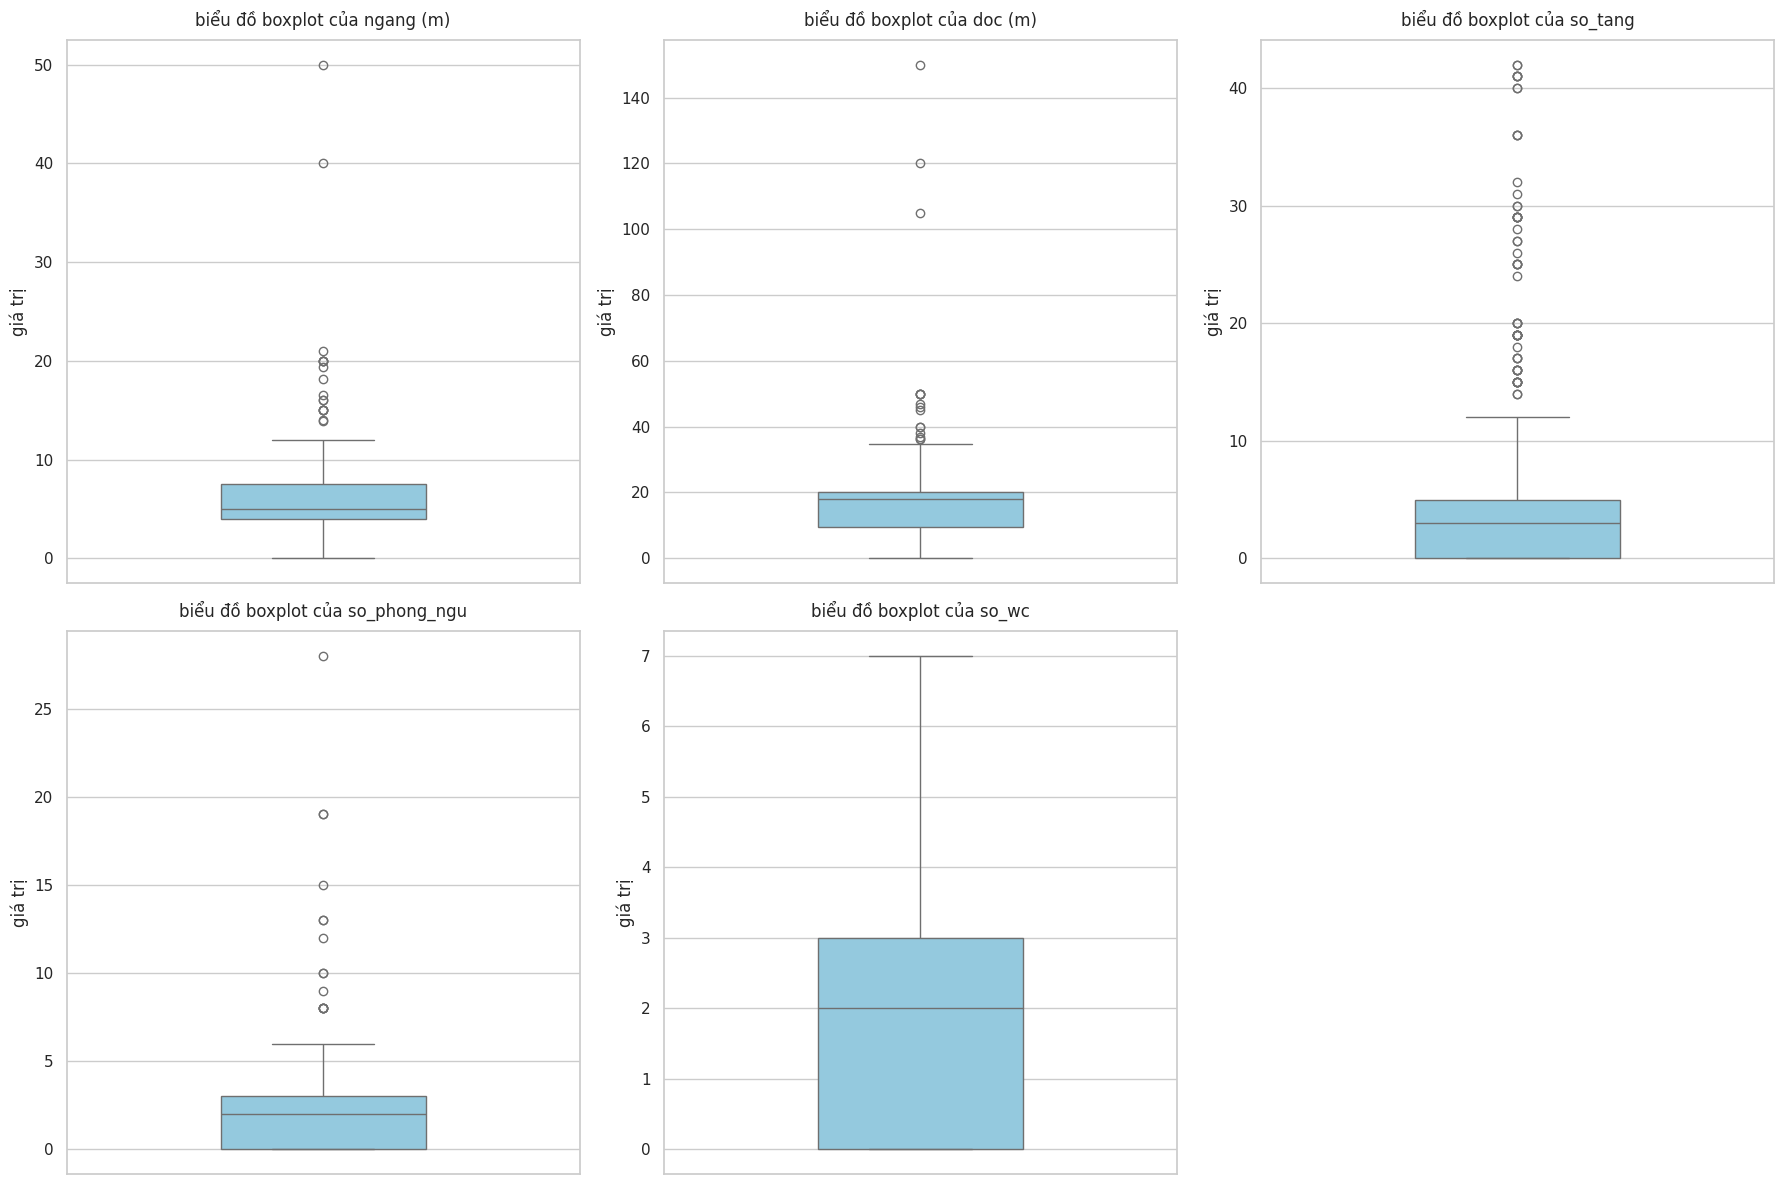

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# cấu hình hiển thị tiếng việt cho biểu đồ không bị lỗi font
plt.rcParams["figure.figsize"] = (15, 10)
sns.set_theme(style="whitegrid")

# danh sách các cột cần tính ngoại lai và vẽ boxplot
cot_kiem_tra = ["ngang (m)", "doc (m)", "so_tang", "so_phong_ngu", "so_wc"]

print("--- báo cáo thống kê số lượng dòng ngoại lai (iqr) ---")

# =========================================================================
# BƯỚC 1: TÍNH TOÁN VÀ IN CỤ THỂ SỐ LƯỢNG NGOẠI LAI CỦA TỪNG CỘT
# =========================================================================
for col in cot_kiem_tra:
    if col in df3.columns:
        # tính toán q1 (phân vị 25%) và q3 (phân vị 75%)
        q1 = df3[col].quantile(0.25)
        q3 = df3[col].quantile(0.75)
        iqr = q3 - q1

        # xác định biên dưới và biên trên để lọc ngoại lai
        bien_duoi = q1 - 1.5 * iqr
        bien_top = q3 + 1.5 * iqr

        # đếm số lượng dòng nằm ngoài khoảng biên
        so_ngoai_lai = df3[(df3[col] < bien_duoi) | (df3[col] > bien_top)].shape[
            0
        ]

        print(
            f"cột '{col}': phát hiện {so_ngoai_lai} dòng ngoại lai (khoảng chuẩn: {bien_duoi:.2f} -> {bien_top:.2f})"
        )


# =========================================================================
# BƯỚC 2: VẼ BIỂU ĐỒ BOXPLOT GOM CHUNG ĐỂ SO SÁNH TRỰC QUAN
# =========================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # chuyển mảng 2 chiều thành 1 chiều để tiện lặp

for i, col in enumerate(cot_kiem_tra):
    if col in df3.columns:
        # vẽ boxplot cho từng cột dữ liệu vào các ô tương ứng
        sns.boxplot(y=df3[col], ax=axes[i], color="skyblue", width=0.4)
        axes[i].set_title(f"biểu đồ boxplot của {col}", fontsize=12, pad=10)
        axes[i].set_ylabel("giá trị")

# ẩn ô biểu đồ thừa thứ 6 (vì mình chỉ có 5 cột cần vẽ trên lưới 2x3)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [ ]:
# lọc bỏ dòng chiều dọc quá vô lý (nghi ngờ lỗi nhập liệu gõ nhầm số)
df3 = df3[df3["doc (m)"] < 100]

# in nghiệm thu lại kích thước dataframe sau khi lọc sạch lỗi gõ nhầm
print(f"số lượng dòng dữ liệu còn lại sau khi lọc sạch lỗi nặng: {len(df3)} dòng")

số lượng dòng dữ liệu còn lại sau khi lọc sạch lỗi nặng: 909 dòng


--- THỐNG KÊ NGOẠI LAI CỘT: gia(ty) ---
  * Q1 (25%): 1.55 | Q3 (75%): 5.50 | IQR: 3.95
  * Ngưỡng dưới: -4.38 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 11.43 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 79 dòng

--- THỐNG KÊ NGOẠI LAI CỘT: dien_tich(m2) ---
  * Q1 (25%): 62.00 | Q3 (75%): 125.00 | IQR: 63.00
  * Ngưỡng dưới: -32.50 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 219.50 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 66 dòng

--- THỐNG KÊ NGOẠI LAI CỘT: trieu/m2 ---
  * Q1 (25%): 19.86 | Q3 (75%): 63.33 | IQR: 43.47
  * Ngưỡng dưới: -45.34 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 128.54 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 45 dòng



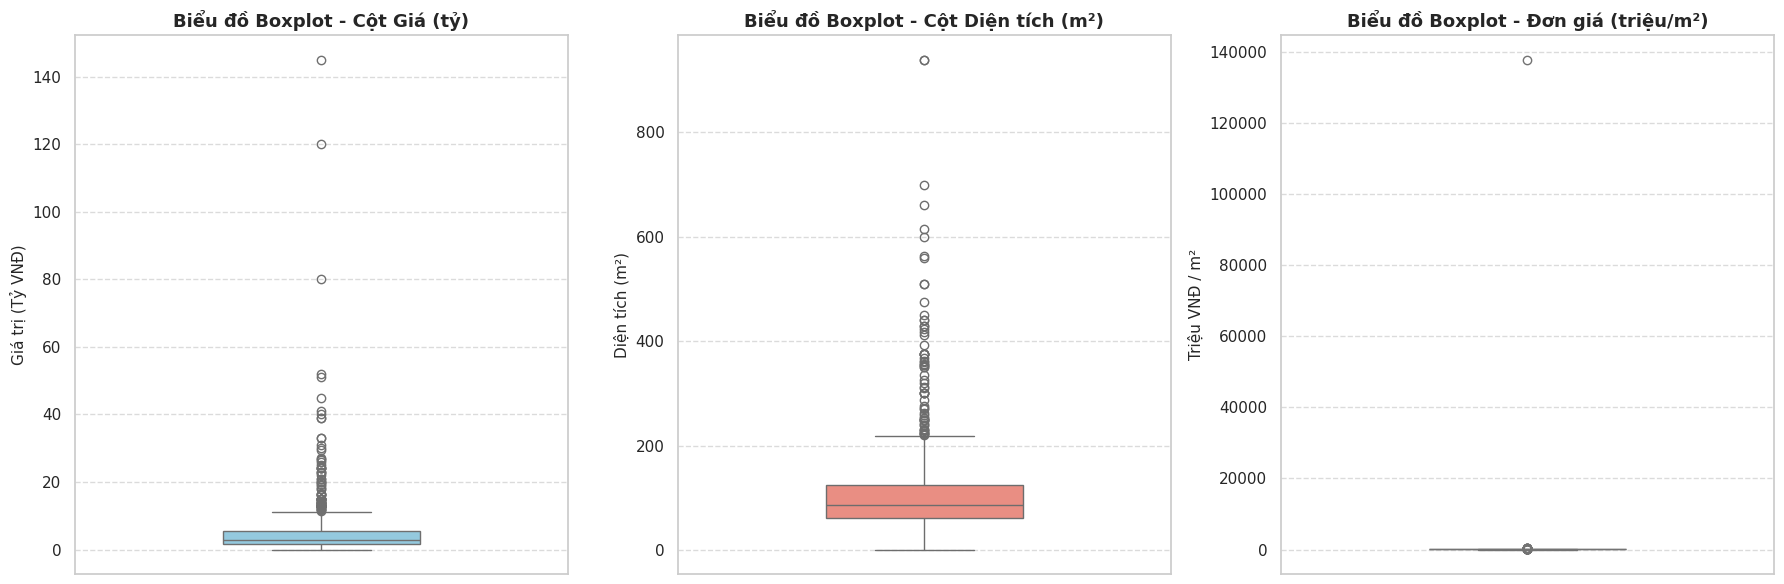

In [ ]:
# =====================================================================
# 1. HÀM TÍNH NGOẠI LAI THEO PHƯƠNG PHÁP IQR
# =====================================================================
def filter_outliers_iqr(df, column_name):
    data = df[column_name].dropna()

    Q1 = data.quantile(0.25)  # Tứ phân vị thứ nhất (25%)
    Q3 = data.quantile(0.75)  # Tứ phân vị thứ ba (75%)
    IQR = Q3 - Q1  # Khoảng biến phân tứ phân vị

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]

    print(f"--- THỐNG KÊ NGOẠI LAI CỘT: {column_name} ---")
    print(f"  * Q1 (25%): {Q1:.2f} | Q3 (75%): {Q3:.2f} | IQR: {IQR:.2f}")
    print(
        f"  * Ngưỡng dưới: {lower_bound:.2f} (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)"
    )
    print(
        f"  * Ngưỡng trên: {upper_bound:.2f} (Các giá trị lớn hơn ngưỡng này là ngoại lai)"
    )
    print(f"  * Số lượng dòng ngoại lai phát hiện: {len(outliers)} dòng\n")

    return outliers


# Chạy hàm tính ngoại lai cho cả 3 cột (Đã thêm cột trieu/m2)
outliers_gia = filter_outliers_iqr(df3, "gia(ty)")
outliers_dt = filter_outliers_iqr(df3, "dien_tich(m2)")
outliers_trieu_m2 = filter_outliers_iqr(df3, "trieu/m2")  # <-- THÊM DÒNG NÀY


# =====================================================================
# 2. VẼ BIỂU ĐỒ BOXPLOT (Cập nhật lên 3 cột biểu đồ)
# =====================================================================
# Khởi tạo khung vẽ gồm 1 hàng và 3 cột biểu đồ (Tăng chiều rộng figsize lên 18)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Vẽ Boxplot cho cột Giá (tỷ)
sns.boxplot(y=df3["gia(ty)"], ax=axes[0], color="skyblue", width=0.4)
axes[0].set_title("Biểu đồ Boxplot - Cột Giá (tỷ)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Giá trị (Tỷ VNĐ)", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Vẽ Boxplot cho cột Diện tích (m²)
sns.boxplot(y=df3["dien_tich(m2)"], ax=axes[1], color="salmon", width=0.4)
axes[1].set_title(
    "Biểu đồ Boxplot - Cột Diện tích (m²)", fontsize=13, fontweight="bold"
)
axes[1].set_ylabel("Diện tích (m²)", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# CẬP NHẬT: Vẽ Boxplot cho cột Đơn giá (triệu/m²)
sns.boxplot(y=df3["trieu/m2"], ax=axes[2], color="lightgreen", width=0.4)
axes[2].set_title(
    "Biểu đồ Boxplot - Đơn giá (triệu/m²)", fontsize=13, fontweight="bold"
)
axes[2].set_ylabel("Triệu VNĐ / m²", fontsize=11)
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

# Tối ưu không gian hiển thị và vẽ
plt.tight_layout()
plt.show()

In [ ]:
# --- THỰC HIỆN LỌC TRÊN DATAFRAME ---
# Giả sử tên cột giá của bạn là 'gia' (Hãy đổi 'gia' thành tên cột thực tế của bạn)
ten_cot_gia = "gia(ty)"

if ten_cot_gia in df3.columns:


    # Lọc những dòng có giá trị > 60 tỷ
    df_luxury = df3[df3["gia(ty)"] > 60]

    # In kết quả nghiệm thu
    print(f"--- TÌM THẤY {len(df_luxury)} BẤT ĐỘNG SẢN CÓ GIÁ TRÊN 60 TỶ ---")

    # Chọn các cột chủ chốt để in ra màn hình cho dễ nhìn
    cac_cot_in = [
        c
        for c in ["dia_chi", "ten_duong", ten_cot_gia, "dien_tich(m2)"]
        if c in df_luxury.columns
    ]
    print(df_luxury[cac_cot_in].to_string())

else:
    print(
        f"Không tìm thấy cột nào tên là '{ten_cot_gia}' trong DataFrame. Bạn hãy kiểm tra lại tên cột giá của mình nhé!"
    )

--- TÌM THẤY 3 BẤT ĐỘNG SẢN CÓ GIÁ TRÊN 60 TỶ ---
                                                                 dia_chi       ten_duong  gia(ty)  dien_tich(m2)
520  Đường An Dương Vương view biển quy nhơn diện tích:430 m²- ngang14 m  An Dương Vương    120.0        430.000
834                           Thành phố. quy nhơn (phường. quy nhơn mới)        Không rõ     80.0        335.000
851                       Thành phố. quy nhơn (phường. quy nhơn nam mới)        Không rõ    145.0          1.052


Nhìn vào biểu đồ Boxplot  vừa vẽ BẮT BUỘC PHẢI XỬ LÝ NGOẠI LAI nếu muốn làm Model dự đoán và Agentic AI.Nếu để nguyên đống dữ liệu này đi train model, các thuật toán (đặc biệt là Linear Regression, các mô hình Neural Network, thậm chí cả Tree-based như XGBoost/LightGBM ở một mức độ nào đó) sẽ bị kéo lệch bởi các bong bóng giá trị nằm chót vót phía trên (ví dụ: nhà giá >140 tỷ, diện tích >1000m², đơn vị đơn giá >400 triệu/m²).

Dưới đây là phân tích chi tiết **định hướng xử lý** :

1. Phân tích thực tế từ kết quả IQR

Nhìn vào các ngưỡng IQR bạn vừa tính được, chúng ta thấy rất rõ bức tranh thị trường trong dataset:

Cột Giá: 75% dữ liệu nằm dưới 5.5 tỷ (Q3). Nhưng ngưỡng trên IQR là 11.43 tỷ. Những căn nhà >11.43 tỷ (đặc biệt là căn vọt lên 140 tỷ) bị coi là ngoại lai.

Cột Diện tích: Ngưỡng trên là 219.50 $m^2$. Những lô đất mẫu, biệt thự lớn >1000 $m^2$ đang kéo phân phối bị lệch phải nghiêm trọng.

Cột Đơn giá (trieu/m2): Ngưỡng trên là 128.41 triệu/$m^2$. Các điểm dữ liệu vọt lên 300 - 400 triệu/$m^2$ là ngoại lai.

2. Chiến lược xử lý ngoại lai cho từng mục tiêuĐối với bất động sản, không phải cứ là ngoại lai theo toán học (IQR) là ta xóa thẳng tay.  Cần xử lý tinh tế theo 2 hướng sau:

Hướng A: Dành cho Model dự đoán giá (Machine Learning)Mô hình toán học rất sợ các giá trị quá cực đoan. Để model có độ chính xác ($R^2$, RMSE) tốt nhất,  nên áp dụng:Log Transformation (Biến đổi Logarit): Thay vì xóa,  dùng np.log1p(df3['gia(ty)']) và tương tự với diện tích. Việc này sẽ "kéo" các giá trị cực đại lùi lại gần ma trận trung tâm, biến phân phối lệch thành phân phối chuẩn (Normal Distribution). Model học sẽ rất "mượt".**Cắt tỉa theo thực tế thị trường **(Trimming):Ngưỡng dưới toán học bị âm (ví dụ: giá trị diện tích ngưỡng dưới là -32.5): Điều này vô lý trong thực tế.  cần chặn dưới bằng tay: ví dụ dien_tich > 10 và gia > 0.1 (100 triệu).Chặn trên: Nên loại bỏ các dòng có giá trị mang tính "ảo" hoặc quá biệt lập (ví dụ nhà 140 tỷ nhưng chỉ có 1-2 căn trong data) vì không đủ dữ liệu cho model học quy luật của phân khúc siêu sang đó.

Hướng B: Dành cho Agentic AI (AI Agent tư vấn/tìm kiếm)Agent cần sự thông minh logic giống con người để lọc, phân loại và truy vấn dữ liệu (Text-to-SQL, Vector Search).Gắn Tag Phân khúc (Binning) thay vì xóa: Đừng xóa những căn nhà 140 tỷ hay đất 1000 $m^2$ nếu Agent phải phục vụ khách hàng đại gia. Thay vào đó, hãy tạo cột phân_khúc:trieu/m2 <= 128: Khách hàng phổ thông.trieu/m2 > 128: Khách hàng cao cấp / Nhà mặt phố VIP.Phát hiện lỗi nhập liệu: Nếu một căn nhà diện tích $30m^2$, giá 100 tỷ $\rightarrow$ đơn giá vọt lên vài tỷ/$m^2$. Agent sẽ dùng các dòng ngoại lai cực đoan này để gắn cờ báo lỗi: "Dữ liệu dòng này có dấu hiệu sai lệch, cần kiểm tra lại".3.

**chặn dựa trên phân vị cao 0.99 hoặc 0.95 thay vì dùng cứng IQR 1.5, vì IQR 1.5 đôi khi xóa mất quá nhiều dữ liệu bất động sản phân khúc cao.**

In [ ]:
# Giữ lại dữ liệu hợp lý bằng cách bỏ đi 1% hoặc 2% giá trị quá cực đoan ở đỉnh
nguong_tren_gia = df3["gia(ty)"].quantile(0.98)
nguong_tren_dt = df3["dien_tich(m2)"].quantile(0.98)

# Chặn dữ liệu (Vừa sạch cho Model, vừa giữ được phân khúc cao cho Agent)
df3 = df3[
    (df3["gia(ty)"] > 0.1)
    & (df3["gia(ty)"] <= nguong_tren_gia)  # Bỏ giá siêu tưởng
    & (df3["dien_tich(m2)"] > 10)
    & (df3["dien_tich(m2)"] <= nguong_tren_dt)  # Bỏ đất quá khổng lồ
]

print(f"Số lượng data sau khi làm sạch: {df3.shape[0]} dòng")

Số lượng data sau khi làm sạch: 851 dòng


In [ ]:
# Giả sử bạn chỉ làm model dự đoán đất thổ cư/nhà ở, giá tối thiểu phải từ 10 triệu/m2 trở lên
muc_gia_san = 10.0  # 10 triệu/m2

# Lọc bỏ các dòng có đơn giá quá rẻ (dưới mức sàn)
df3 = df3[df3["trieu/m2"] >= muc_gia_san]

# Kiểm tra lại giá trị nhỏ nhất mới
print(f"Giá trị nhỏ nhất sau khi lọc sàn: {df3['trieu/m2'].min()} triệu/m2")

Giá trị nhỏ nhất sau khi lọc sàn: 10.0 triệu/m2


--- THỐNG KÊ NGOẠI LAI CỘT: gia(ty) ---
  * Q1 (25%): 1.88 | Q3 (75%): 5.50 | IQR: 3.62
  * Ngưỡng dưới: -3.54 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 10.92 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 62 dòng

--- THỐNG KÊ NGOẠI LAI CỘT: dien_tich(m2) ---
  * Q1 (25%): 60.00 | Q3 (75%): 104.65 | IQR: 44.65
  * Ngưỡng dưới: -6.98 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 171.62 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 74 dòng

--- THỐNG KÊ NGOẠI LAI CỘT: trieu/m2 ---
  * Q1 (25%): 24.53 | Q3 (75%): 65.30 | IQR: 40.77
  * Ngưỡng dưới: -36.63 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 126.45 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 35 dòng



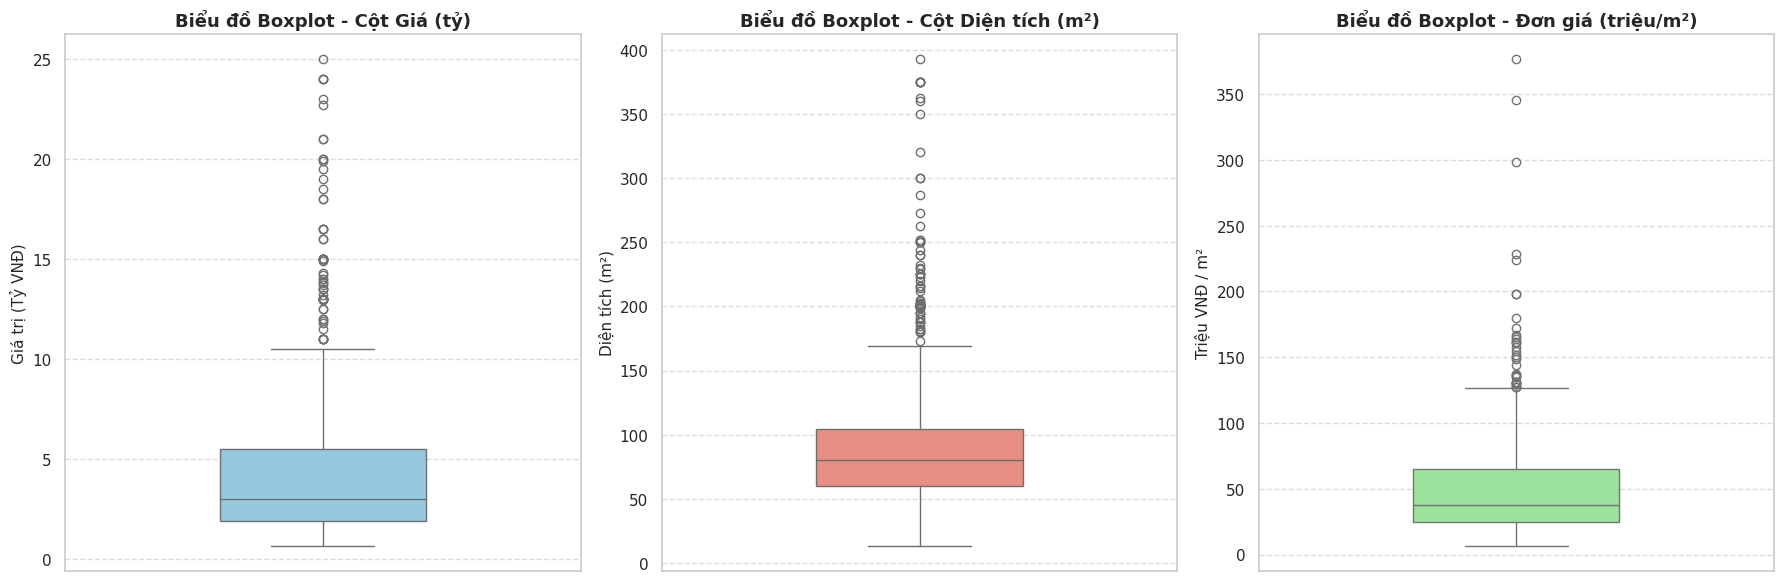

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Đảm bảo các cột đã ở dạng số (float) trước khi tính toán và vẽ
df3["gia(ty)"] = pd.to_numeric(df3["gia(ty)"], errors="coerce")
df3["dien_tich(m2)"] = pd.to_numeric(df3["dien_tich(m2)"], errors="coerce")

# =====================================================================
# CẬP NHẬT: TÍNH TOÁN CỘT TRIEU/M2 CHUẨN XÁC
# =====================================================================
df3["trieu/m2"] = (df3["gia(ty)"] * 1000) / df3["dien_tich(m2)"]


# =====================================================================
# 1. HÀM TÍNH NGOẠI LAI THEO PHƯƠNG PHÁP IQR (Giữ nguyên logic của bạn)
# =====================================================================
def filter_outliers_iqr(df, column_name):
    data = df[column_name].dropna()

    Q1 = data.quantile(0.25)  # Tứ phân vị thứ nhất (25%)
    Q3 = data.quantile(0.75)  # Tứ phân vị thứ ba (75%)
    IQR = Q3 - Q1  # Khoảng biến phân tứ phân vị

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]

    print(f"--- THỐNG KÊ NGOẠI LAI CỘT: {column_name} ---")
    print(f"  * Q1 (25%): {Q1:.2f} | Q3 (75%): {Q3:.2f} | IQR: {IQR:.2f}")
    print(
        f"  * Ngưỡng dưới: {lower_bound:.2f} (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)"
    )
    print(
        f"  * Ngưỡng trên: {upper_bound:.2f} (Các giá trị lớn hơn ngưỡng này là ngoại lai)"
    )
    print(f"  * Số lượng dòng ngoại lai phát hiện: {len(outliers)} dòng\n")

    return outliers


# Chạy hàm tính ngoại lai cho cả 3 cột (Đã thêm cột trieu/m2)
outliers_gia = filter_outliers_iqr(df3, "gia(ty)")
outliers_dt = filter_outliers_iqr(df3, "dien_tich(m2)")
outliers_trieu_m2 = filter_outliers_iqr(df3, "trieu/m2")  # <-- THÊM DÒNG NÀY


# =====================================================================
# 2. VẼ BIỂU ĐỒ BOXPLOT (Cập nhật lên 3 cột biểu đồ)
# =====================================================================
# Khởi tạo khung vẽ gồm 1 hàng và 3 cột biểu đồ (Tăng chiều rộng figsize lên 18)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Vẽ Boxplot cho cột Giá (tỷ)
sns.boxplot(y=df3["gia(ty)"], ax=axes[0], color="skyblue", width=0.4)
axes[0].set_title("Biểu đồ Boxplot - Cột Giá (tỷ)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Giá trị (Tỷ VNĐ)", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Vẽ Boxplot cho cột Diện tích (m²)
sns.boxplot(y=df3["dien_tich(m2)"], ax=axes[1], color="salmon", width=0.4)
axes[1].set_title(
    "Biểu đồ Boxplot - Cột Diện tích (m²)", fontsize=13, fontweight="bold"
)
axes[1].set_ylabel("Diện tích (m²)", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# CẬP NHẬT: Vẽ Boxplot cho cột Đơn giá (triệu/m²)
sns.boxplot(y=df3["trieu/m2"], ax=axes[2], color="lightgreen", width=0.4)
axes[2].set_title(
    "Biểu đồ Boxplot - Đơn giá (triệu/m²)", fontsize=13, fontweight="bold"
)
axes[2].set_ylabel("Triệu VNĐ / m²", fontsize=11)
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

# Tối ưu không gian hiển thị và vẽ
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# 3. IN CHI TIẾT CÁC DÒNG NGOẠI LAI THEO TỪNG LOẠI
# =====================================================================

# Cấu hình Pandas hiển thị rộng hơn để không bị xuống dòng lỗi font
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

# Các cột quan trọng cần in ra để đối chiếu
cols_to_print = [
    "dia_chi",
    "ten_duong",
    "gia(ty)",
    "dien_tich(m2)",
    "trieu/m2",
]
available_cols = [c for c in cols_to_print if c in df3.columns]

print(
    "========================================================================="
)
print("             DANH SÁCH CHI TIẾT CÁC GIÁ TRỊ NGOẠI LAI                    ")
print(
    "=========================================================================\n"
)

# ---------------------------------------------------------------------
# LOẠI 1: Ngoại lai về GIÁ (ty)
# ---------------------------------------------------------------------
print(f" [LOẠI 1] CÁC BẤT ĐỘNG SẢN CÓ GIÁ NGOẠI LAI ({len(outliers_gia)} dòng):")
if not outliers_gia.empty:
    # Sắp xếp từ giá cao nhất xuống thấp nhất để dễ nhìn
    outliers_gia_sorted = outliers_gia.sort_values(
        by="gia(ty)", ascending=False
    )
    print(outliers_gia_sorted[available_cols].to_string(index=True))
else:
    print(" -> Không có dòng ngoại lai nào về giá.")
print("-" * 80 + "\n")

# ---------------------------------------------------------------------
# LOẠI 2: Ngoại lai về DIỆN TÍCH (m2)
# ---------------------------------------------------------------------
print(
    f"[LOẠI 2] CÁC BẤT ĐỘNG SẢN CÓ DIỆN TÍCH NGOẠI LAI ({len(outliers_dt)} dòng):"
)
if not outliers_dt.empty:
    # Sắp xếp từ diện tích rộng nhất xuống thấp nhất
    outliers_dt_sorted = outliers_dt.sort_values(
        by="dien_tich(m2)", ascending=False
    )
    print(outliers_dt_sorted[available_cols].to_string(index=True))
else:
    print(" -> Không có dòng ngoại lai nào về diện tích.")
print("-" * 80 + "\n")

# ---------------------------------------------------------------------
# LOẠI 3: Ngoại lai về ĐƠN GIÁ (trieu/m2)
# ---------------------------------------------------------------------
print(
    f"[LOẠI 3] CÁC BẤT ĐỘNG SẢN CÓ ĐƠN GIÁ (triệu/m2) NGOẠI LAI ({len(outliers_trieu_m2)} dòng):"
)
if not outliers_trieu_m2.empty:
    # Sắp xếp từ đơn giá đắt đỏ nhất xuống thấp nhất
    outliers_tm2_sorted = outliers_trieu_m2.sort_values(
        by="trieu/m2", ascending=False
    )
    print(outliers_tm2_sorted[available_cols].to_string(index=True))
else:
    print(" -> Không có dòng ngoại lai nào về đơn giá triệu/m2.")
print(
    "========================================================================="
)

             DANH SÁCH CHI TIẾT CÁC GIÁ TRỊ NGOẠI LAI                    

 [LOẠI 1] CÁC BẤT ĐỘNG SẢN CÓ GIÁ NGOẠI LAI (62 dòng):
                                                                                                                                                                                                                                                                                                                                                                       dia_chi         ten_duong  gia(ty)  dien_tich(m2)    trieu/m2
506                                                                                                                                                                                                                                                                                                                                                              Đường Ngô Mây           Ngô Mây   25.000          139.0  179.856115
140                         

In [ ]:
# Lọc bỏ các dòng có đơn giá đột biến > 290 triệu/m2
df3 = df3[df3["trieu/m2"] < 290]

# Chạy lại lệnh vẽ Boxplot của bạn để xem kết quả mới phẳng lì!

--- THỐNG KÊ NGOẠI LAI CỘT: gia(ty) ---
  * Q1 (25%): 1.87 | Q3 (75%): 5.50 | IQR: 3.63
  * Ngưỡng dưới: -3.57 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 10.94 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 60 dòng

--- THỐNG KÊ NGOẠI LAI CỘT: dien_tich(m2) ---
  * Q1 (25%): 60.00 | Q3 (75%): 105.00 | IQR: 45.00
  * Ngưỡng dưới: -7.50 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 172.50 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 74 dòng

--- THỐNG KÊ NGOẠI LAI CỘT: trieu/m2 ---
  * Q1 (25%): 24.44 | Q3 (75%): 65.03 | IQR: 40.58
  * Ngưỡng dưới: -36.43 (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)
  * Ngưỡng trên: 125.90 (Các giá trị lớn hơn ngưỡng này là ngoại lai)
  * Số lượng dòng ngoại lai phát hiện: 34 dòng



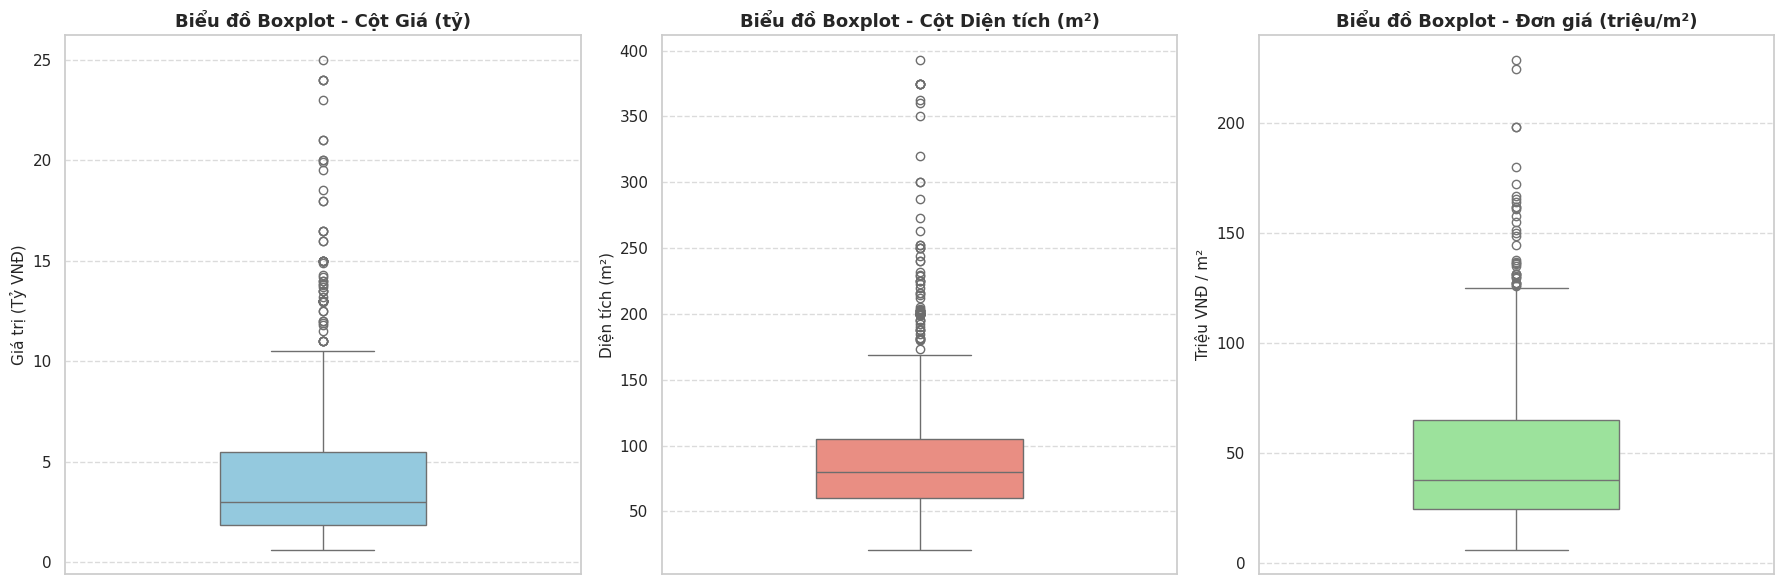

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Đảm bảo các cột đã ở dạng số (float) trước khi tính toán và vẽ
df3["gia(ty)"] = pd.to_numeric(df3["gia(ty)"], errors="coerce")
df3["dien_tich(m2)"] = pd.to_numeric(df3["dien_tich(m2)"], errors="coerce")

# =====================================================================
# CẬP NHẬT: TÍNH TOÁN CỘT TRIEU/M2 CHUẨN XÁC
# =====================================================================
df3["trieu/m2"] = (df3["gia(ty)"] * 1000) / df3["dien_tich(m2)"]


# =====================================================================
# 1. HÀM TÍNH NGOẠI LAI THEO PHƯƠNG PHÁP IQR (Giữ nguyên logic của bạn)
# =====================================================================
def filter_outliers_iqr(df, column_name):
    data = df[column_name].dropna()

    Q1 = data.quantile(0.25)  # Tứ phân vị thứ nhất (25%)
    Q3 = data.quantile(0.75)  # Tứ phân vị thứ ba (75%)
    IQR = Q3 - Q1  # Khoảng biến phân tứ phân vị

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]

    print(f"--- THỐNG KÊ NGOẠI LAI CỘT: {column_name} ---")
    print(f"  * Q1 (25%): {Q1:.2f} | Q3 (75%): {Q3:.2f} | IQR: {IQR:.2f}")
    print(
        f"  * Ngưỡng dưới: {lower_bound:.2f} (Các giá trị nhỏ hơn ngưỡng này là ngoại lai)"
    )
    print(
        f"  * Ngưỡng trên: {upper_bound:.2f} (Các giá trị lớn hơn ngưỡng này là ngoại lai)"
    )
    print(f"  * Số lượng dòng ngoại lai phát hiện: {len(outliers)} dòng\n")

    return outliers


# Chạy hàm tính ngoại lai cho cả 3 cột (Đã thêm cột trieu/m2)
outliers_gia = filter_outliers_iqr(df3, "gia(ty)")
outliers_dt = filter_outliers_iqr(df3, "dien_tich(m2)")
outliers_trieu_m2 = filter_outliers_iqr(df3, "trieu/m2")  # <-- THÊM DÒNG NÀY


# =====================================================================
# 2. VẼ BIỂU ĐỒ BOXPLOT (Cập nhật lên 3 cột biểu đồ)
# =====================================================================
# Khởi tạo khung vẽ gồm 1 hàng và 3 cột biểu đồ (Tăng chiều rộng figsize lên 18)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Vẽ Boxplot cho cột Giá (tỷ)
sns.boxplot(y=df3["gia(ty)"], ax=axes[0], color="skyblue", width=0.4)
axes[0].set_title("Biểu đồ Boxplot - Cột Giá (tỷ)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Giá trị (Tỷ VNĐ)", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Vẽ Boxplot cho cột Diện tích (m²)
sns.boxplot(y=df3["dien_tich(m2)"], ax=axes[1], color="salmon", width=0.4)
axes[1].set_title(
    "Biểu đồ Boxplot - Cột Diện tích (m²)", fontsize=13, fontweight="bold"
)
axes[1].set_ylabel("Diện tích (m²)", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# CẬP NHẬT: Vẽ Boxplot cho cột Đơn giá (triệu/m²)
sns.boxplot(y=df3["trieu/m2"], ax=axes[2], color="lightgreen", width=0.4)
axes[2].set_title(
    "Biểu đồ Boxplot - Đơn giá (triệu/m²)", fontsize=13, fontweight="bold"
)
axes[2].set_ylabel("Triệu VNĐ / m²", fontsize=11)
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

# Tối ưu không gian hiển thị và vẽ
plt.tight_layout()
plt.show()

In [ ]:
# --- THỰC HIỆN LỌC TRÊN DATAFRAME ---
# Giả sử tên cột giá của bạn là 'gia' (Hãy đổi 'gia' thành tên cột thực tế của bạn)
ten_cot_gia = "gia(ty)"

if ten_cot_gia in df3.columns:


    # Lọc những dòng có giá trị > 60 tỷ
    df_luxury = df3[df3["gia(ty)"] > 60]

    # In kết quả nghiệm thu
    print(f"--- TÌM THẤY {len(df_luxury)} BẤT ĐỘNG SẢN CÓ GIÁ TRÊN 60 TỶ ---")

    # Chọn các cột chủ chốt để in ra màn hình cho dễ nhìn
    cac_cot_in = [
        c
        for c in ["dia_chi", "ten_duong", ten_cot_gia, "ngang (m)", "doc (m)"]
        if c in df_luxury.columns
    ]
    print(df_luxury[cac_cot_in].to_string())

else:
    print(
        f"Không tìm thấy cột nào tên là '{ten_cot_gia}' trong DataFrame. Bạn hãy kiểm tra lại tên cột giá của mình nhé!"
    )

--- TÌM THẤY 0 BẤT ĐỘNG SẢN CÓ GIÁ TRÊN 60 TỶ ---
Empty DataFrame
Columns: [dia_chi, ten_duong, gia(ty), ngang (m), doc (m)]
Index: []


In [ ]:

# =========================================================================
#  SẮP XẾP VÀ CHUẨN HÓA DANH SÁCH CỘT THEO YÊU CẦU ĐẦU RA
# =========================================================================
# Khung thứ tự cột chuẩn (giữ lại loai_bds gốc và tích hợp thêm cột nhom_bds hỗ trợ Agent)
dsth_cot_chuan = [
    "nhom_bds_lon",
    "nhom_bds",
    "loai_bds",
    "quan_huyen",
    "ten_duong",
    "dia_chi",
    "gia(ty)",
    "trieu/m2",
    "dien_tich(m2)",
    "ngang (m)",
    "doc (m)",
    "huong",
    "phap_ly",
    "so_tang",
    "so_phong_ngu",
    "so_wc",
    "tieu_de",
    "nguon",
    "ngang_is_predicted",
    "doc_is_predicted",
    "so_tang_is_predicted",
    "so_phong_ngu_is_predicted",
    "so_wc_is_predicted",
    "gia(ty)_is_predicted",
    "trieu/m2_is_predicted",
    "is_price_outlier",
]

# Chỉ lấy những cột thực tế đang tồn tại để tránh phát sinh lỗi Key ngoài ý muốn
existing_cols = [col for col in dsth_cot_chuan if col in df3.columns]
df3 = df3[existing_cols]
df3.head()

,nhom_bds_lon,nhom_bds,loai_bds,quan_huyen,ten_duong,dia_chi,gia(ty),trieu/m2,dien_tich(m2),ngang (m),doc (m),huong,phap_ly,so_tang,so_phong_ngu,so_wc,tieu_de,nguon,ngang_is_predicted,doc_is_predicted,so_tang_is_predicted,so_phong_ngu_is_predicted,so_wc_is_predicted,gia(ty)_is_predicted,trieu/m2_is_predicted,is_price_outlier
0,Nhà,Biệt thự/Nhà liền kề,"Biệt thự, nhà liền kề",Thành phố Quy Nhơn,Cao Văn Lầu,Đường cao văn lầu,8.0,60.150376,133.0,7.0,19.0,Đông,Đang cập nhật,3,6,4,Biệt thự mặt tiền Cao Văn Lầu – quy nhơn nam g...,https://alonhadat.com.vn/-biet-thu-mat-tien-ca...,0,0,0,0,0,0,0,0
2,Nhà,Biệt thự/Nhà liền kề,"Biệt thự, nhà liền kề",Thành phố Quy Nhơn,Không rõ,Đường rộng thoáng....... << xem chi tiết >> 28...,14.2,65.740741,216.0,10.0,21.6,Tây,Đang cập nhật,4,4,4,Bán 2 căn biệt thự 4 tầng khu đại phú gia – đẳ...,https://alonhadat.com.vn/-ban-2-can-biet-thu-4...,0,0,0,0,0,0,0,0
4,Nhà,Căn hộ chung cư,Căn hộ chung cư,Thành phố Quy Nhơn,Lê Đức Thọ,Đường Lê Đức Thọ - để lại full nội thất - 3 ph...,2.9,33.720930,86.0,8.0,11.0,Tây,Đang cập nhật,18,3,2,Bán nhanh căn hộ 3pn phú tài residences giá tốt,https://alonhadat.com.vn/ban-nhanh-can-ho-3pn-...,0,0,0,0,0,0,0,0
5,Đất,Đất nền/Đất ở,Đất thổ cư/đất ở,Huyện Phù Cát,Tỉnh lộ 639,Đường Tỉnh Lộ 639,2.3,11.979167,192.0,8.0,25.0,Chưa xác định,Đang cập nhật,0,0,0,Bán lô góc tân thanh - cát hải,https://alonhadat.com.vn/ban-lo-goc-tan-thanh-...,0,0,0,0,0,0,0,0
6,Nhà,Căn hộ chung cư,Căn hộ chung cư,Thành phố Quy Nhơn,Nguyễn Tất Thành,Đường Nguyễn Tất Thành,2.3,35.384615,65.0,0.0,0.0,Chưa xác định,Đang cập nhật,12,2,2,Kẹt vốn bán cắt lỗ căn hộ grand center quy nhơ...,https://alonhadat.com.vn/ket-von-ban-cat-lo-ca...,0,0,0,0,0,0,0,0


In [ ]:
df3.describe()

,gia(ty),trieu/m2,dien_tich(m2),ngang (m),doc (m),so_tang,so_phong_ngu,so_wc,ngang_is_predicted,doc_is_predicted,so_tang_is_predicted,so_phong_ngu_is_predicted,so_wc_is_predicted,gia(ty)_is_predicted,trieu/m2_is_predicted,is_price_outlier
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.0,768.0,768.0,768.000000,768.000000,768.0,768.0,768.0,768.000000,768.000000,768.0
mean,4.387021,49.623519,93.394167,4.478385,13.656250,5.268229,2.143229,1.960938,0.304688,0.304688,0.0,0.0,0.0,0.041667,0.041667,0.0
std,3.961715,34.780059,56.762816,3.105226,9.364017,6.985433,2.24922,1.372494,0.460575,0.460575,0.0,0.0,0.0,0.199957,0.199957,0.0
min,0.635000,6.227106,21.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
25%,1.872500,24.444853,60.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
50%,2.990000,37.638508,80.000000,5.000000,16.100000,3.0,2.0,2.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
75%,5.500000,65.027641,105.000000,7.000000,20.000000,9.0,3.0,3.0,1.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
max,25.000000,228.571429,393.000000,19.400000,50.000000,42.0,28.0,6.0,1.000000,1.000000,0.0,0.0,0.0,1.000000,1.000000,0.0


In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 911
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   nhom_bds_lon               768 non-null    object 
 1   nhom_bds                   768 non-null    object 
 2   loai_bds                   768 non-null    object 
 3   quan_huyen                 768 non-null    object 
 4   ten_duong                  768 non-null    object 
 5   dia_chi                    768 non-null    object 
 6   gia(ty)                    768 non-null    float64
 7   trieu/m2                   768 non-null    float64
 8   dien_tich(m2)              768 non-null    float64
 9   ngang (m)                  768 non-null    float64
 10  doc (m)                    768 non-null    float64
 11  huong                      768 non-null    object 
 12  phap_ly                    768 non-null    object 
 13  so_tang                    768 non-null    Int64  
 14 

In [ ]:
# 1. định nghĩa danh sách các cột tag kĩ thuật cần kiểm tra giá trị unique
cac_cot_tag = [
    "ngang_is_predicted",
    "doc_is_predicted",
    "so_tang_is_predicted",
    "so_phong_ngu_is_predicted",
    "so_wc_is_predicted",
    "gia(ty)_is_predicted",
    "trieu/m2_is_predicted",
    "is_price_outlier",
]

print("--- kiểm tra giá trị độc nhất (unique) của các cột tag ---")

# 2. lặp qua từng cột để in ra các giá trị unique thực tế trong dataframe
for col in cac_cot_tag:
    if col in df3.columns:
        giatri_unique = df3[col].unique()
        print(f"cột '{col}': {giatri_unique}")

--- kiểm tra giá trị độc nhất (unique) của các cột tag ---
cột 'ngang_is_predicted': [0 1]
cột 'doc_is_predicted': [0 1]
cột 'so_tang_is_predicted': [0]
cột 'so_phong_ngu_is_predicted': [0]
cột 'so_wc_is_predicted': [0]
cột 'gia(ty)_is_predicted': [0 1]
cột 'trieu/m2_is_predicted': [0 1]
cột 'is_price_outlier': [0]


In [ ]:
# 1. lọc và lưu các dòng có đơn giá được điền bằng số median vào một dataframe riêng
df_gia_du_doan = df3[df3["trieu/m2_is_predicted"] == 1]

# 2. in ra tổng số dòng tìm được
print(
    f"tổng số dòng dữ liệu có đơn giá trieu/m2 được điền khuyết: {len(df_gia_du_doan)} dòng"
)

# 3. in ra cụ thể danh sách các dòng này (chỉ hiển thị một số cột chính để dễ nhìn trên màn hình)
print("\n--- danh sách cụ thể các dòng được điền khuyết đơn giá ---")
print(
    df_gia_du_doan[
        [
            "nhom_bds",
            "ten_duong",
            "gia(ty)",
            "dien_tich(m2)",
            "trieu/m2",
            "trieu/m2_is_predicted",
        ]
    ]
)

tổng số dòng dữ liệu có đơn giá trieu/m2 được điền khuyết: 32 dòng

--- danh sách cụ thể các dòng được điền khuyết đơn giá ---
                   nhom_bds ten_duong  gia(ty)  dien_tich(m2)    trieu/m2  trieu/m2_is_predicted
540           Đất nền/Đất ở  Không rõ    1.700         100.00   17.000000                      1
559  Nhà mặt phố/Kinh doanh  Không rõ    7.000          70.00  100.000000                      1
563    Biệt thự/Nhà liền kề  Không rõ    6.575          85.00   77.352941                      1
570           Đất nền/Đất ở  Không rõ    1.700          80.00   21.250000                      1
583         Căn hộ chung cư  Không rõ    1.900          45.00   42.222222                      1
586           Đất nền/Đất ở   Ngô Mây    1.700         273.00    6.227106                      1
614         Căn hộ chung cư  Không rõ    1.900          68.00   27.941176                      1
615         Căn hộ chung cư  Không rõ    1.900          65.00   29.230769                      1


In [ ]:
# 1. định nghĩa danh sách các cột tag kĩ thuật muốn loại bỏ
cac_cot_tag_xoa = [
    "ngang_is_predicted",
    "doc_is_predicted",
    "so_tang_is_predicted",
    "so_phong_ngu_is_predicted",
    "so_wc_is_predicted",
    "gia(ty)_is_predicted",
    "trieu/m2_is_predicted",
    "is_price_outlier",
]

# 2. dùng hàm drop để xóa bỏ các cột này khỏi dataframe mới (axis=1 nghĩa là xóa cột)
# dùng errors='ignore' để tránh bị báo lỗi nếu lỡ trước đó có cột nào chưa tạo
df3 = df3.drop(columns=cac_cot_tag_xoa, axis=1, errors="ignore")

# 3. in thử cấu trúc 5 dòng đầu của dataframe sạch
print("--- cấu trúc 5 dòng đầu của df3 ---")
print(df3.head(5))

--- cấu trúc 5 dòng đầu của df3 ---
  nhom_bds_lon              nhom_bds               loai_bds          quan_huyen         ten_duong                                            dia_chi  gia(ty)   trieu/m2  dien_tich(m2)  ngang (m)  doc (m)          huong        phap_ly  so_tang  so_phong_ngu  so_wc                                            tieu_de                                              nguon
0          Nhà  Biệt thự/Nhà liền kề  Biệt thự, nhà liền kề  Thành phố Quy Nhơn       Cao Văn Lầu                                 Đường cao văn lầu      8.0  60.150376          133.0        7.0     19.0           Đông  Đang cập nhật        3             6      4  Biệt thự mặt tiền Cao Văn Lầu – quy nhơn nam g...  https://alonhadat.com.vn/-biet-thu-mat-tien-ca...
2          Nhà  Biệt thự/Nhà liền kề  Biệt thự, nhà liền kề  Thành phố Quy Nhơn          Không rõ  Đường rộng thoáng....... << xem chi tiết >> 28...     14.2  65.740741          216.0       10.0     21.6            Tây  Đang cập nhậ

In [ ]:
df3.shape

(768, 18)

In [ ]:


# 📥 XUẤT FILE SỐ 1 BÀN GIAO CHO NHÓM 2 (AGENTIC AI)
df3.to_csv('clean_data.csv', index=False, encoding='utf-8-sig')
print("-> Đã xuất xong file 'clean_data.csv' để bàn giao cho Nhóm 2!")


-> Đã xuất xong file 'clean_data.csv' để bàn giao cho Nhóm 2!
